In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
import random
import time
from datetime import datetime
import matplotlib.pyplot as plt

import networkx as nx
import collections
import csv

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

from torch_geometric.data import Data, HeteroData
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv, HeteroConv, GATv2Conv, TransformerConv
from torch_geometric.loader import DataLoader

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing

import torch
from itertools import combinations
# from torch_scatter import scatter_mean

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
# EdgeEncoder
class EdgeEncoder(nn.Module):
    def __init__(self, in_channels, hidden_dim):
        super().__init__()
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)

    def forward(self, edge_attr, nodes_edges_index):
        edge_feat = self.gcn1(edge_attr, nodes_edges_index)
        edge_feat = F.relu(edge_feat)
        edge_feat = self.gcn2(edge_feat, nodes_edges_index)
        edge_rep = torch.cat([edge_attr, edge_feat], dim=-1)
        return edge_rep

In [4]:
class HeteroGCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        
        self.dropout = nn.Dropout(0.05)
        
        self.conv1 = HeteroConv({
            ('company', 'supply', 'company'): TransformerConv(
                in_channels, hidden_channels, edge_dim=10, heads=10, concat = False),
            ('company', 'boardex', 'company'): TransformerConv(
                in_channels, hidden_channels, edge_dim=10, heads=10, concat = False),
            ('company', 'competition', 'company'): TransformerConv(
                in_channels, hidden_channels, edge_dim=10, heads=10, concat = False),
        }, aggr='cat')

        self.conv2 = HeteroConv({
            ('company', 'supply', 'company'): TransformerConv(
                hidden_channels * 3, out_channels, edge_dim=10, heads=1),
            ('company', 'boardex', 'company'): TransformerConv(
                hidden_channels * 3, out_channels, edge_dim=10, heads=1),
            ('company', 'competition', 'company'): TransformerConv(
                hidden_channels * 3, out_channels, edge_dim=10, heads=1),
        }, aggr='cat')

    def forward(self, x_dict, edge_index_dict, edge_attr_dict):
        for key in edge_attr_dict:
          edge_attr_dict[key] = edge_attr_dict[key].float()
            
        x_dict = self.conv1(x_dict, edge_index_dict, edge_attr_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}
        x_dict = {k: self.dropout(v) for k, v in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict, edge_attr_dict)
        return x_dict
        

class NodeClassifier(nn.Module):
    def __init__(self, out_channels, num_classes):
        super().__init__()
        self.dropout = nn.Dropout(0.01)
        self.fc = nn.Linear(out_channels * 3 + 12, out_channels)
        self.fc1 = nn.Linear(out_channels, num_classes)

    def forward(self, x):
        x = self.fc(x)
        x = self.dropout(x)
        return self.fc1(x)

In [5]:
def train_model(edge_model, encoder, classifier, data, optimizer, criterion, device):
    edge_model.train()
    encoder.train()
    classifier.train()
    optimizer.zero_grad()
    data = data.to(device)

    edge_attr_dict = {}
    edge_x_all = data['edges'].edge_x.to(device)

    for rel in ['supply', 'boardex', 'competition']:
        start, end = data['edges'].edge_ranges[rel]
        edge_x = edge_x_all[start:end]

        edge_edge_index = data[(rel, 'company', rel)].edge_edge_index.to(device)

        if edge_edge_index.size(1) > 0:
            edge_embed = edge_model(edge_x, edge_edge_index)
        else:
            edge_embed = edge_x

        edge_attr_dict[('company', rel, 'company')] = edge_embed

    x_dict, edge_index_dict, edge_attr_dict = data.x_dict, data.edge_index_dict, edge_attr_dict
    y = data['company'].y
    train_mask = data['company'].train_mask

    x_dict = {k: v.to(device) for k, v in x_dict.items()}
    edge_index_dict = {k: v.to(device) for k, v in edge_index_dict.items()}
    y = y.to(device)

    node_repr = encoder(x_dict, edge_index_dict, edge_attr_dict)

    logits = node_repr['company']
    
    loss = criterion(logits[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.softmax(logits[train_mask], dim=1)
        preds = logits[train_mask].argmax(dim=1)

        y_true = y[train_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[train_mask])) > 1 else 0.0

    return loss.item(), acc, f1


def validate_model(edge_model, encoder, classifier, data, criterion, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict, edge_attr_dict = data.x_dict, data.edge_index_dict, data.edge_attr_dict
        y = data['company'].y
        val_mask = data['company'].val_mask

        x_dict = {k: v.to(device) for k, v in x_dict.items()}
        edge_index_dict = {k: v.to(device) for k, v in edge_index_dict.items()}
        y = y.to(device)

        edge_attr_dict = {}
        edge_x_all = data['edges'].edge_x.to(device)

        for rel in ['supply', 'boardex', 'competition']:
            start, end = data['edges'].edge_ranges[rel]
            edge_x = edge_x_all[start:end]
    
            edge_edge_index = data[(rel, 'company', rel)].edge_edge_index.to(device)
    
            if edge_edge_index.size(1) > 0:
                edge_embed = edge_model(edge_x, edge_edge_index)
            else:
                edge_embed = edge_x
    
            edge_attr_dict[('company', rel, 'company')] = edge_embed

        node_repr = encoder(x_dict, edge_index_dict, edge_attr_dict)

        logits = node_repr['company']

        loss = criterion(logits[val_mask], y[val_mask])
        probs = torch.softmax(logits[val_mask], dim=1)
        preds = logits[val_mask].argmax(dim=1)

        y_true = y[val_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[val_mask])) > 1 else 0.0

    return loss.item(), acc, f1


def test_model(edge_model, encoder, classifier, data, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict, edge_attr_dict = data.x_dict, data.edge_index_dict, data.edge_attr_dict
        y = data['company'].y
        test_mask = data['company'].test_mask  # use test_mask if available

        x_dict = {k: v.to(device) for k, v in x_dict.items()}
        edge_index_dict = {k: v.to(device) for k, v in edge_index_dict.items()}
        y = y.to(device)

        edge_attr_dict = {}
        edge_x_all = data['edges'].edge_x.to(device)

        for rel in ['supply', 'boardex', 'competition']:
            start, end = data['edges'].edge_ranges[rel]
            edge_x = edge_x_all[start:end]
    
            edge_edge_index = data[(rel, 'company', rel)].edge_edge_index.to(device)
    
            if edge_edge_index.size(1) > 0:
                edge_embed = edge_model(edge_x, edge_edge_index)
            else:
                edge_embed = edge_x
    
            edge_attr_dict[('company', rel, 'company')] = edge_embed

        node_repr = encoder(x_dict, edge_index_dict, edge_attr_dict)

        logits = node_repr['company']

        probs = torch.softmax(logits[test_mask], dim=1)
        preds = logits[test_mask].argmax(dim=1)

        y_true = y[test_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[test_mask])) > 1 else 0.0

    return acc, f1

In [6]:
def train_test(edge_model, encoder, classifier, data, optimizer, criterion, device, epochs=1000, patience=100):
    best_val_loss = float('inf')
    counter = 0
    best_encoder = None
    best_classifier = None
    best_train_acc = None
    best_f1 = None

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s = [], []

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_model(edge_model, encoder, classifier, data, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = validate_model(edge_model, encoder, classifier, data, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch: {epoch+1:03d}, '
                  f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_f1 = val_f1
            counter = 0
            best_egde_model = edge_model.state_dict()
            best_encoder = encoder.state_dict()
            best_classifier = classifier.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")

    if best_encoder is not None and best_classifier is not None:
        edge_model.load_state_dict(best_egde_model)
        encoder.load_state_dict(best_encoder)
        classifier.load_state_dict(best_classifier)

    return edge_model, encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, best_val_loss, best_train_acc, best_f1

In [7]:
def run_experiment(year, metric, hidden_channels=64, out_channels=32, num_heads=4,
                   lr=0.01, weight_decay=5e-4, epochs=1000, patience=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    data = torch.load(f'Dataset/heterographdata{year}2.pt', weights_only=False)
    in_channels = data['company'].x.size(1)
    num_classes = int(data['company'].y.max().item()) + 1

    if torch.min(data['company'].y) < 0:
        valid_labels = data['company'].y >= 0
        num_classes = int(data['company'].y[valid_labels].max().item()) + 1

    print(f"Input channels: {in_channels}, Number of classes: {num_classes}")

    edge_hidden_dim = 7
    edge_model = EdgeEncoder(in_channels=3, hidden_dim = edge_hidden_dim).to(device)

    encoder = HeteroGCNEncoder(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels
    ).to(device)

    classifier = NodeClassifier(
        out_channels=out_channels,
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(classifier.parameters()) + list(edge_model.parameters()), 
        lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()

    edge_model, encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, _, best_train_acc, best_f1 = train_test(
        edge_model, encoder, classifier, data, optimizer, criterion, device, epochs=epochs, patience=patience
    )

    test_acc, test_f1 = test_model(edge_model, encoder, classifier, data, device)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1 Score: {test_f1:.4f}')

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'Graph_EncoderClassifier_training_{year}_{metric}.png')
    plt.show()

    return {
        'encoder': encoder,
        'classifier': classifier,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'training_time': training_time,
        'epochs_run': len(train_losses),
        'best_train_acc': best_train_acc
    }


========== Run 1 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3564, Val Loss: 3.1661, Train Acc: 0.4553, Val Acc: 0.4624
Epoch: 020, Train Loss: 2.0670, Val Loss: 1.9365, Train Acc: 0.5141, Val Acc: 0.4962
Epoch: 030, Train Loss: 1.3106, Val Loss: 1.2409, Train Acc: 0.5254, Val Acc: 0.5226
Epoch: 040, Train Loss: 0.9629, Val Loss: 0.9820, Train Acc: 0.5681, Val Acc: 0.5150
Epoch: 050, Train Loss: 0.8020, Val Loss: 0.8489, Train Acc: 0.5915, Val Acc: 0.5376
Epoch: 060, Train Loss: 0.7267, Val Loss: 0.7900, Train Acc: 0.6172, Val Acc: 0.5451
Epoch: 070, Train Loss: 0.6857, Val Loss: 0.7711, Train Acc: 0.6180, Val Acc: 0.5489
Epoch: 080, Train Loss: 0.6653, Val Loss: 0.7464, Train Acc: 0.6350, Val Acc: 0.5489
Epoch: 090, Train Loss: 0.6458, Val Loss: 0.7520, Train Acc: 0.6285, Val Acc: 0.5188
Epoch: 100, Train Loss: 0.6326, Val Loss: 0.7494, Train Acc: 0.6591, Val Acc: 0.5150
Epoch: 110, Train Loss

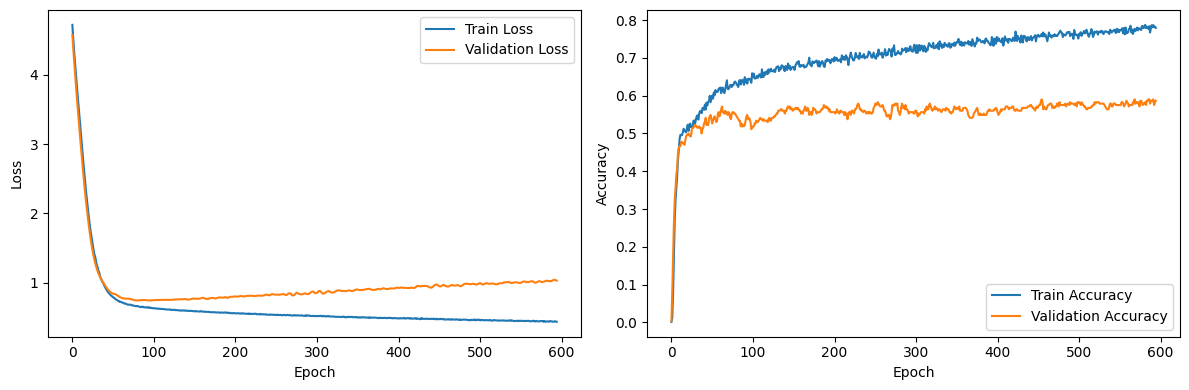


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9101, Val Loss: 2.8392, Train Acc: 0.4631, Val Acc: 0.4510
Epoch: 020, Train Loss: 1.8718, Val Loss: 1.8407, Train Acc: 0.5185, Val Acc: 0.4667
Epoch: 030, Train Loss: 1.2388, Val Loss: 1.2460, Train Acc: 0.5428, Val Acc: 0.4902
Epoch: 040, Train Loss: 0.9333, Val Loss: 0.9812, Train Acc: 0.5864, Val Acc: 0.5255
Epoch: 050, Train Loss: 0.7832, Val Loss: 0.8336, Train Acc: 0.5982, Val Acc: 0.5569
Epoch: 060, Train Loss: 0.7114, Val Loss: 0.7724, Train Acc: 0.6091, Val Acc: 0.5490
Epoch: 070, Train Loss: 0.6732, Val Loss: 0.7625, Train Acc: 0.6258, Val Acc: 0.5216
Epoch: 080, Train Loss: 0.6486, Val Loss: 0.7452, Train Acc: 0.6351, Val Acc: 0.5490
Epoch: 090, Train Loss: 0.6465, Val Loss: 0.7296, Train Acc: 0.6477, Val Acc: 0.5608
Epoch: 100, Train Loss: 0.6164, Val Loss: 0.7299, Train Acc: 0.6669, Val Acc: 0.5804
Epoch: 110, Train Loss: 0.6099, Val Loss: 0.7331, Tr

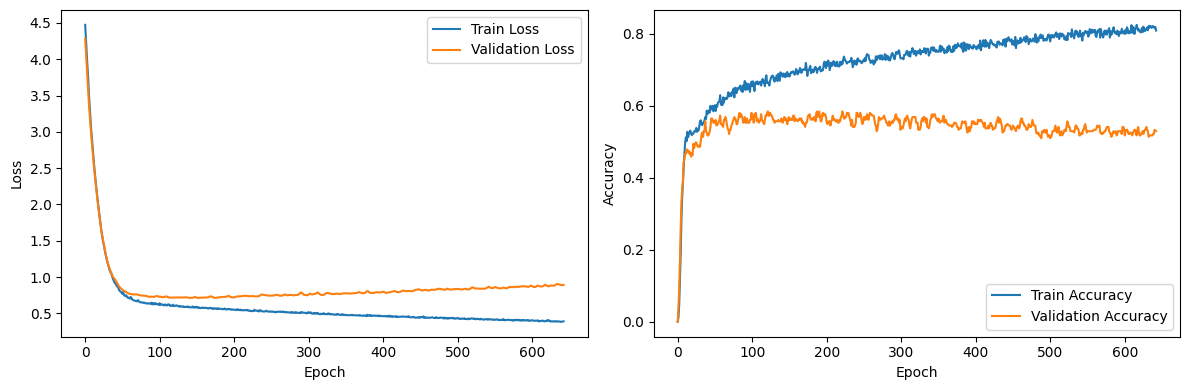


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0695, Val Loss: 3.0398, Train Acc: 0.4356, Val Acc: 0.3814
Epoch: 020, Train Loss: 2.1183, Val Loss: 2.1438, Train Acc: 0.5263, Val Acc: 0.4322
Epoch: 030, Train Loss: 1.4273, Val Loss: 1.4710, Train Acc: 0.5499, Val Acc: 0.4661
Epoch: 040, Train Loss: 1.0705, Val Loss: 1.1375, Train Acc: 0.5808, Val Acc: 0.5169
Epoch: 050, Train Loss: 0.8807, Val Loss: 0.9623, Train Acc: 0.6034, Val Acc: 0.5212
Epoch: 060, Train Loss: 0.7693, Val Loss: 0.8502, Train Acc: 0.6162, Val Acc: 0.5424
Epoch: 070, Train Loss: 0.7137, Val Loss: 0.7837, Train Acc: 0.6307, Val Acc: 0.5593
Epoch: 080, Train Loss: 0.6778, Val Loss: 0.7673, Train Acc: 0.6461, Val Acc: 0.5720
Epoch: 090, Train Loss: 0.6678, Val Loss: 0.7457, Train Acc: 0.6434, Val Acc: 0.5890
Epoch: 100, Train Loss: 0.6717, Val Loss: 0.7346, Train Acc: 0.6497, Val Acc: 0.5890
Epoch: 110, Train Loss: 0.6412, Val Loss: 0.7174, Tr

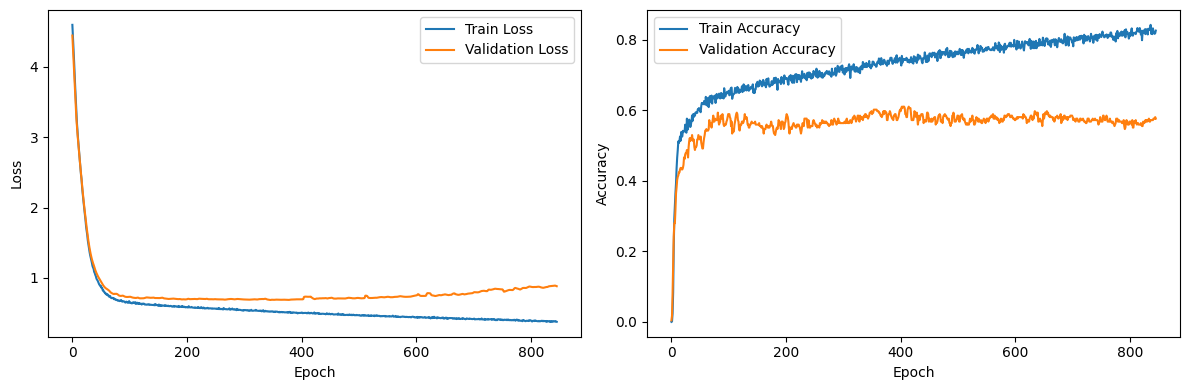


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9048, Val Loss: 2.7049, Train Acc: 0.4902, Val Acc: 0.4450
Epoch: 020, Train Loss: 1.9401, Val Loss: 1.8139, Train Acc: 0.5207, Val Acc: 0.4587
Epoch: 030, Train Loss: 1.3553, Val Loss: 1.2729, Train Acc: 0.5384, Val Acc: 0.4679
Epoch: 040, Train Loss: 1.0333, Val Loss: 1.0051, Train Acc: 0.5669, Val Acc: 0.4954
Epoch: 050, Train Loss: 0.8423, Val Loss: 0.8513, Train Acc: 0.5915, Val Acc: 0.5505
Epoch: 060, Train Loss: 0.7511, Val Loss: 0.7858, Train Acc: 0.6171, Val Acc: 0.5459
Epoch: 070, Train Loss: 0.7123, Val Loss: 0.7438, Train Acc: 0.6240, Val Acc: 0.5275
Epoch: 080, Train Loss: 0.6723, Val Loss: 0.7283, Train Acc: 0.6368, Val Acc: 0.5183
Epoch: 090, Train Loss: 0.6546, Val Loss: 0.7194, Train Acc: 0.6388, Val Acc: 0.5780
Epoch: 100, Train Loss: 0.6348, Val Loss: 0.7183, Train Acc: 0.6486, Val Acc: 0.5688
Epoch: 110, Train Loss: 0.6237, Val Loss: 0.7140, Tr

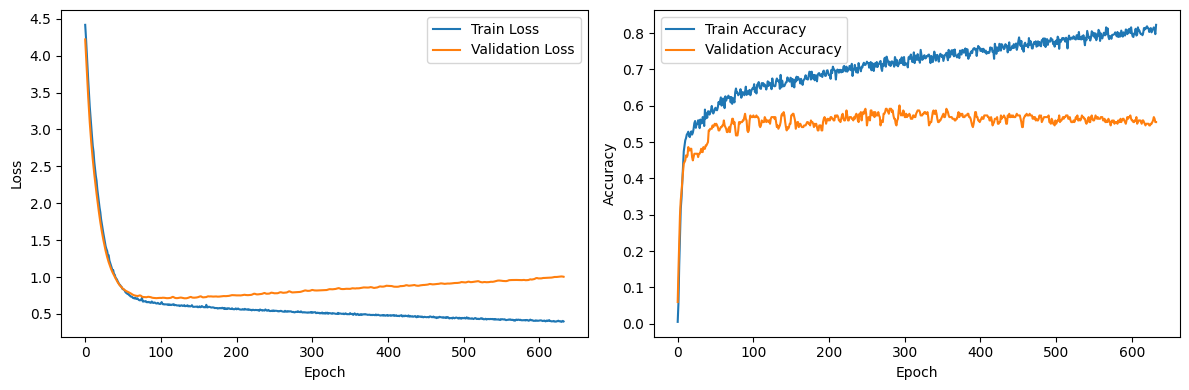


========== Run 2 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2158, Val Loss: 2.9359, Train Acc: 0.4069, Val Acc: 0.4398
Epoch: 020, Train Loss: 2.0821, Val Loss: 1.9127, Train Acc: 0.5052, Val Acc: 0.4699
Epoch: 030, Train Loss: 1.3909, Val Loss: 1.3232, Train Acc: 0.5181, Val Acc: 0.4887
Epoch: 040, Train Loss: 1.0269, Val Loss: 1.0332, Train Acc: 0.5415, Val Acc: 0.5113
Epoch: 050, Train Loss: 0.8475, Val Loss: 0.8887, Train Acc: 0.5705, Val Acc: 0.5338
Epoch: 060, Train Loss: 0.7563, Val Loss: 0.8146, Train Acc: 0.5987, Val Acc: 0.5677
Epoch: 070, Train Loss: 0.6984, Val Loss: 0.7656, Train Acc: 0.6221, Val Acc: 0.5902
Epoch: 080, Train Loss: 0.6717, Val Loss: 0.7381, Train Acc: 0.6180, Val Acc: 0.5865
Epoch: 090, Train Loss: 0.6526, Val Loss: 0.7329, Train Acc: 0.6374, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.6385, Val Loss: 0.7364, Train Acc: 0.6559, Val Acc: 0.5865
Epoch: 110, Train Loss

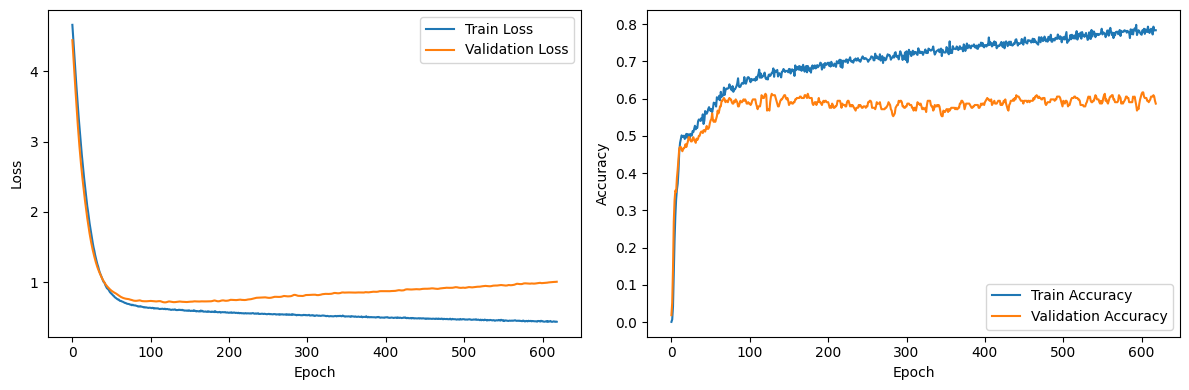


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2707, Val Loss: 3.1225, Train Acc: 0.4782, Val Acc: 0.5294
Epoch: 020, Train Loss: 2.0707, Val Loss: 1.9800, Train Acc: 0.5067, Val Acc: 0.5255
Epoch: 030, Train Loss: 1.3445, Val Loss: 1.3296, Train Acc: 0.5285, Val Acc: 0.5294
Epoch: 040, Train Loss: 0.9862, Val Loss: 0.9890, Train Acc: 0.5730, Val Acc: 0.5333
Epoch: 050, Train Loss: 0.8137, Val Loss: 0.8448, Train Acc: 0.5973, Val Acc: 0.5373
Epoch: 060, Train Loss: 0.7249, Val Loss: 0.7714, Train Acc: 0.6208, Val Acc: 0.5294
Epoch: 070, Train Loss: 0.6761, Val Loss: 0.7373, Train Acc: 0.6233, Val Acc: 0.5373
Epoch: 080, Train Loss: 0.6446, Val Loss: 0.7259, Train Acc: 0.6367, Val Acc: 0.5412
Epoch: 090, Train Loss: 0.6242, Val Loss: 0.7183, Train Acc: 0.6535, Val Acc: 0.5333
Epoch: 100, Train Loss: 0.6079, Val Loss: 0.7152, Train Acc: 0.6628, Val Acc: 0.5373
Epoch: 110, Train Loss: 0.5961, Val Loss: 0.7150, Tr

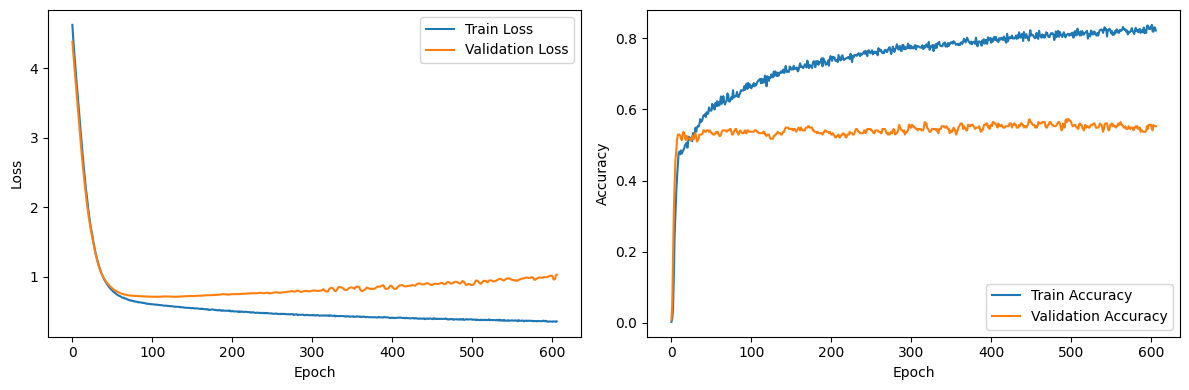


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3378, Val Loss: 3.2551, Train Acc: 0.5064, Val Acc: 0.5000
Epoch: 020, Train Loss: 2.2256, Val Loss: 2.1965, Train Acc: 0.5481, Val Acc: 0.5339
Epoch: 030, Train Loss: 1.4713, Val Loss: 1.4751, Train Acc: 0.5590, Val Acc: 0.5297
Epoch: 040, Train Loss: 1.0324, Val Loss: 1.0595, Train Acc: 0.5708, Val Acc: 0.5551
Epoch: 050, Train Loss: 0.8359, Val Loss: 0.8730, Train Acc: 0.6243, Val Acc: 0.5508
Epoch: 060, Train Loss: 0.7431, Val Loss: 0.7839, Train Acc: 0.6270, Val Acc: 0.5508
Epoch: 070, Train Loss: 0.6931, Val Loss: 0.7378, Train Acc: 0.6198, Val Acc: 0.5805
Epoch: 080, Train Loss: 0.6669, Val Loss: 0.7178, Train Acc: 0.6352, Val Acc: 0.5763
Epoch: 090, Train Loss: 0.6540, Val Loss: 0.7113, Train Acc: 0.6388, Val Acc: 0.5847
Epoch: 100, Train Loss: 0.6591, Val Loss: 0.7070, Train Acc: 0.6443, Val Acc: 0.5763
Epoch: 110, Train Loss: 0.6448, Val Loss: 0.6975, Tr

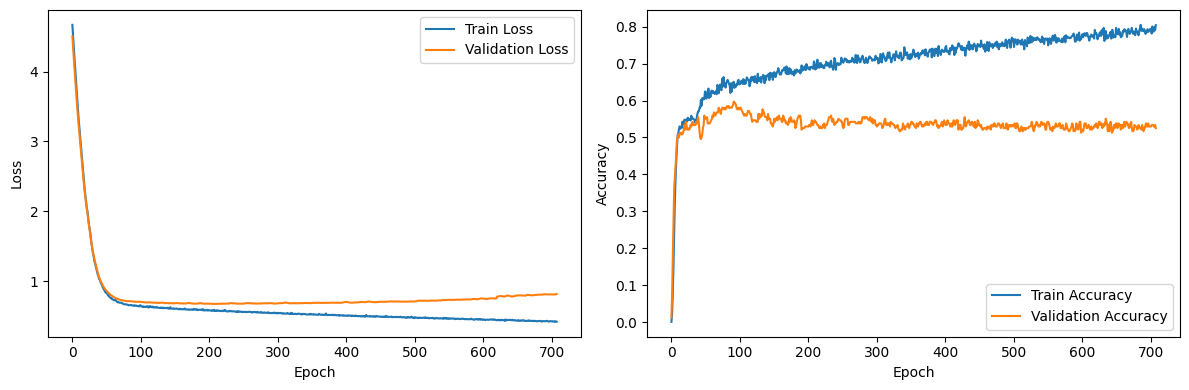


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1115, Val Loss: 2.8781, Train Acc: 0.5207, Val Acc: 0.5183
Epoch: 020, Train Loss: 2.0863, Val Loss: 1.9338, Train Acc: 0.5315, Val Acc: 0.5596
Epoch: 030, Train Loss: 1.3969, Val Loss: 1.3094, Train Acc: 0.5394, Val Acc: 0.5459
Epoch: 040, Train Loss: 1.0223, Val Loss: 1.0034, Train Acc: 0.5925, Val Acc: 0.5183
Epoch: 050, Train Loss: 0.8404, Val Loss: 0.8507, Train Acc: 0.5984, Val Acc: 0.5183
Epoch: 060, Train Loss: 0.7398, Val Loss: 0.7889, Train Acc: 0.6132, Val Acc: 0.5321
Epoch: 070, Train Loss: 0.7231, Val Loss: 0.7569, Train Acc: 0.6043, Val Acc: 0.5413
Epoch: 080, Train Loss: 0.6636, Val Loss: 0.7363, Train Acc: 0.6496, Val Acc: 0.5321
Epoch: 090, Train Loss: 0.6549, Val Loss: 0.7264, Train Acc: 0.6378, Val Acc: 0.5367
Epoch: 100, Train Loss: 0.6341, Val Loss: 0.7319, Train Acc: 0.6516, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.6238, Val Loss: 0.7204, Tr

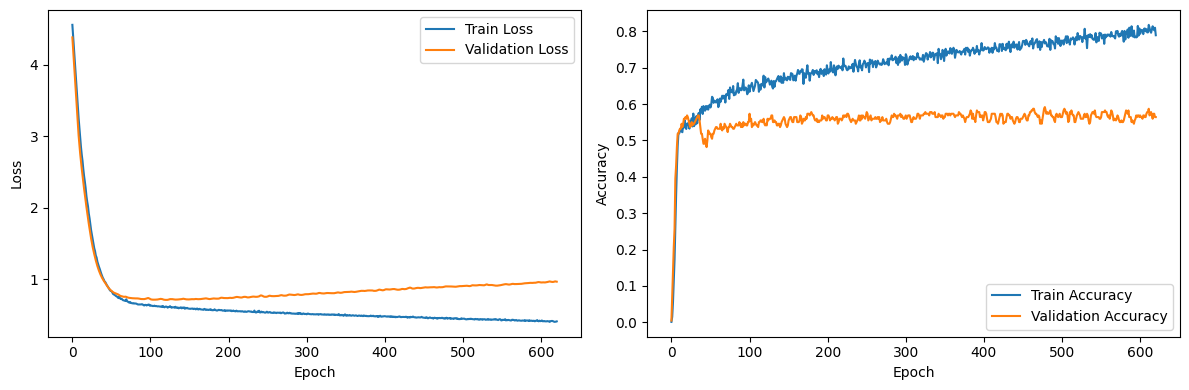


========== Run 3 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3369, Val Loss: 3.0830, Train Acc: 0.3844, Val Acc: 0.4173
Epoch: 020, Train Loss: 2.1743, Val Loss: 1.9477, Train Acc: 0.5254, Val Acc: 0.5564
Epoch: 030, Train Loss: 1.4462, Val Loss: 1.3330, Train Acc: 0.5649, Val Acc: 0.5865
Epoch: 040, Train Loss: 1.0573, Val Loss: 1.0187, Train Acc: 0.6019, Val Acc: 0.5865
Epoch: 050, Train Loss: 0.8720, Val Loss: 0.8525, Train Acc: 0.5915, Val Acc: 0.6278
Epoch: 060, Train Loss: 0.7522, Val Loss: 0.7744, Train Acc: 0.6197, Val Acc: 0.6391
Epoch: 070, Train Loss: 0.6958, Val Loss: 0.7438, Train Acc: 0.6237, Val Acc: 0.6278
Epoch: 080, Train Loss: 0.6625, Val Loss: 0.7270, Train Acc: 0.6398, Val Acc: 0.6353
Epoch: 090, Train Loss: 0.6490, Val Loss: 0.7193, Train Acc: 0.6479, Val Acc: 0.6466
Epoch: 100, Train Loss: 0.6341, Val Loss: 0.7171, Train Acc: 0.6334, Val Acc: 0.6241
Epoch: 110, Train Loss

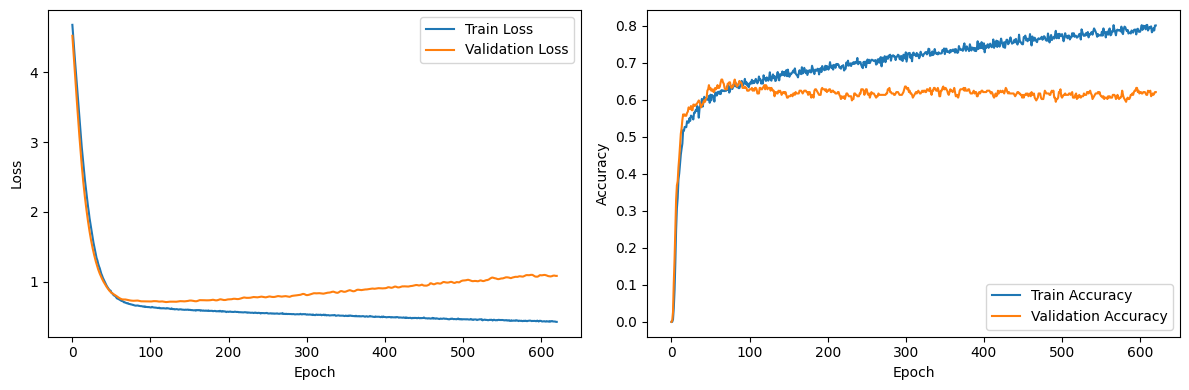


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2884, Val Loss: 3.1785, Train Acc: 0.4119, Val Acc: 0.4784
Epoch: 020, Train Loss: 2.0272, Val Loss: 1.9815, Train Acc: 0.5419, Val Acc: 0.5216
Epoch: 030, Train Loss: 1.3758, Val Loss: 1.3628, Train Acc: 0.5503, Val Acc: 0.4941
Epoch: 040, Train Loss: 1.0413, Val Loss: 1.0711, Train Acc: 0.5973, Val Acc: 0.4784
Epoch: 050, Train Loss: 0.8709, Val Loss: 0.9033, Train Acc: 0.6099, Val Acc: 0.4941
Epoch: 060, Train Loss: 0.7599, Val Loss: 0.8158, Train Acc: 0.6183, Val Acc: 0.4863
Epoch: 070, Train Loss: 0.7069, Val Loss: 0.7750, Train Acc: 0.6359, Val Acc: 0.5137
Epoch: 080, Train Loss: 0.6682, Val Loss: 0.7449, Train Acc: 0.6384, Val Acc: 0.5176
Epoch: 090, Train Loss: 0.6564, Val Loss: 0.7314, Train Acc: 0.6535, Val Acc: 0.5373
Epoch: 100, Train Loss: 0.6352, Val Loss: 0.7200, Train Acc: 0.6569, Val Acc: 0.5412
Epoch: 110, Train Loss: 0.6230, Val Loss: 0.7195, Tr

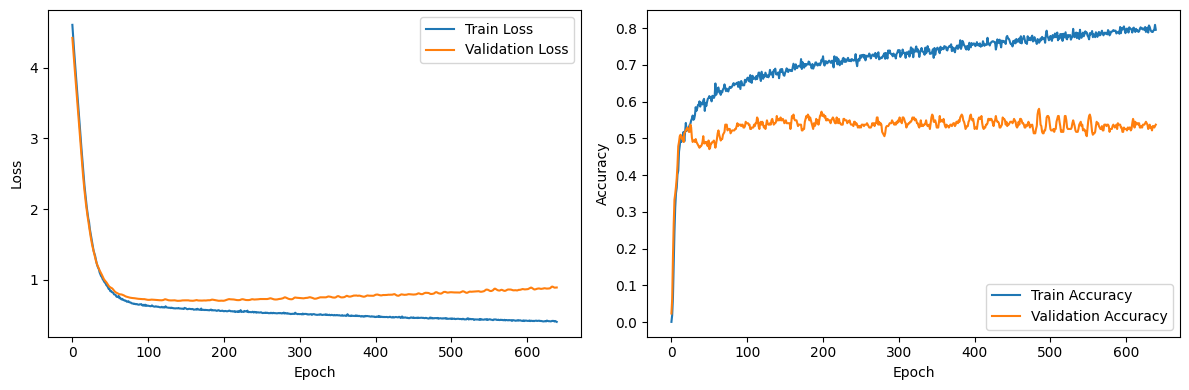


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0523, Val Loss: 2.9070, Train Acc: 0.4601, Val Acc: 0.4915
Epoch: 020, Train Loss: 2.0400, Val Loss: 2.0233, Train Acc: 0.5172, Val Acc: 0.4703
Epoch: 030, Train Loss: 1.3428, Val Loss: 1.3669, Train Acc: 0.5408, Val Acc: 0.4831
Epoch: 040, Train Loss: 1.0057, Val Loss: 1.0278, Train Acc: 0.5563, Val Acc: 0.5127
Epoch: 050, Train Loss: 0.8306, Val Loss: 0.8611, Train Acc: 0.5871, Val Acc: 0.5424
Epoch: 060, Train Loss: 0.7548, Val Loss: 0.7645, Train Acc: 0.5962, Val Acc: 0.5508
Epoch: 070, Train Loss: 0.6935, Val Loss: 0.7235, Train Acc: 0.6216, Val Acc: 0.5763
Epoch: 080, Train Loss: 0.6795, Val Loss: 0.7118, Train Acc: 0.6225, Val Acc: 0.5636
Epoch: 090, Train Loss: 0.6562, Val Loss: 0.7017, Train Acc: 0.6407, Val Acc: 0.5593
Epoch: 100, Train Loss: 0.6444, Val Loss: 0.6964, Train Acc: 0.6443, Val Acc: 0.5720
Epoch: 110, Train Loss: 0.6364, Val Loss: 0.6881, Tr

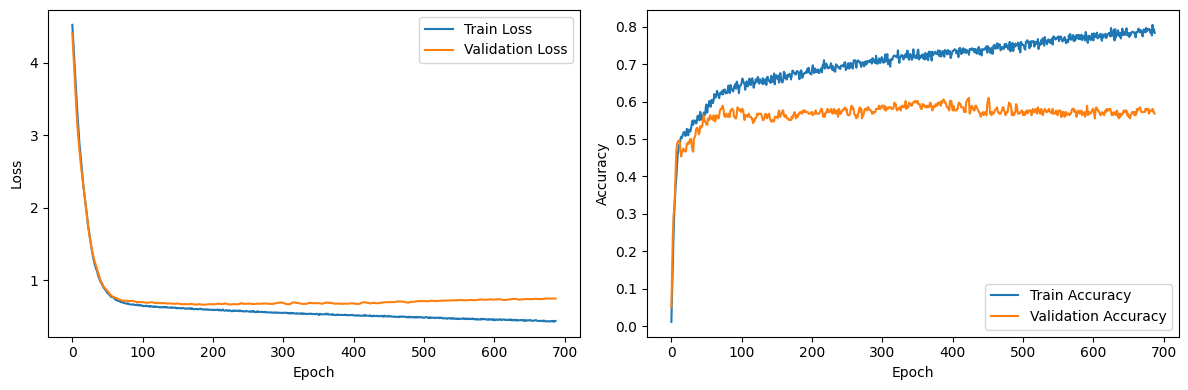


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2798, Val Loss: 3.1876, Train Acc: 0.3474, Val Acc: 0.3945
Epoch: 020, Train Loss: 2.1103, Val Loss: 2.0259, Train Acc: 0.5325, Val Acc: 0.4954
Epoch: 030, Train Loss: 1.3774, Val Loss: 1.3381, Train Acc: 0.5335, Val Acc: 0.4725
Epoch: 040, Train Loss: 1.0170, Val Loss: 1.0098, Train Acc: 0.5453, Val Acc: 0.4908
Epoch: 050, Train Loss: 0.8309, Val Loss: 0.8701, Train Acc: 0.5925, Val Acc: 0.5138
Epoch: 060, Train Loss: 0.7397, Val Loss: 0.8119, Train Acc: 0.6033, Val Acc: 0.5413
Epoch: 070, Train Loss: 0.6897, Val Loss: 0.7543, Train Acc: 0.6211, Val Acc: 0.5642
Epoch: 080, Train Loss: 0.6607, Val Loss: 0.7504, Train Acc: 0.6339, Val Acc: 0.5596
Epoch: 090, Train Loss: 0.6297, Val Loss: 0.7533, Train Acc: 0.6496, Val Acc: 0.5505
Epoch: 100, Train Loss: 0.6171, Val Loss: 0.7558, Train Acc: 0.6437, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.5966, Val Loss: 0.7492, Tr

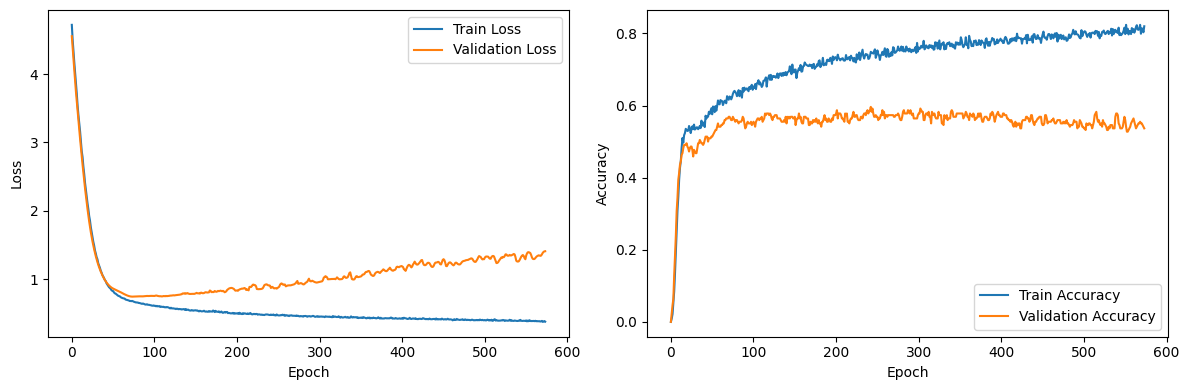


========== Run 4 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3763, Val Loss: 3.1403, Train Acc: 0.4948, Val Acc: 0.5376
Epoch: 020, Train Loss: 2.0625, Val Loss: 1.8712, Train Acc: 0.5576, Val Acc: 0.5602
Epoch: 030, Train Loss: 1.3072, Val Loss: 1.2333, Train Acc: 0.5818, Val Acc: 0.5677
Epoch: 040, Train Loss: 0.9647, Val Loss: 0.9509, Train Acc: 0.5955, Val Acc: 0.6015
Epoch: 050, Train Loss: 0.7943, Val Loss: 0.8206, Train Acc: 0.6213, Val Acc: 0.6015
Epoch: 060, Train Loss: 0.7135, Val Loss: 0.7608, Train Acc: 0.6317, Val Acc: 0.5977
Epoch: 070, Train Loss: 0.6784, Val Loss: 0.7424, Train Acc: 0.6197, Val Acc: 0.5526
Epoch: 080, Train Loss: 0.6518, Val Loss: 0.7332, Train Acc: 0.6495, Val Acc: 0.5526
Epoch: 090, Train Loss: 0.6389, Val Loss: 0.7258, Train Acc: 0.6438, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.6337, Val Loss: 0.7251, Train Acc: 0.6600, Val Acc: 0.5865
Epoch: 110, Train Loss

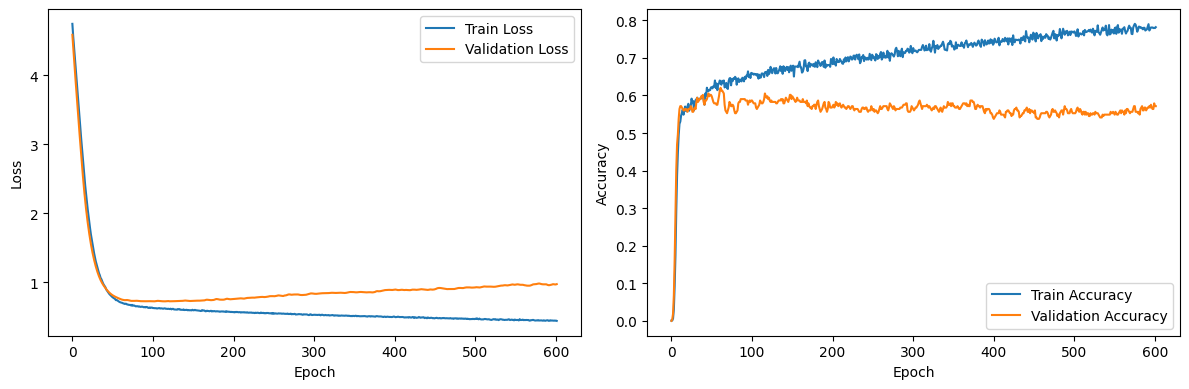


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.8058, Val Loss: 3.7386, Train Acc: 0.2685, Val Acc: 0.3176
Epoch: 020, Train Loss: 2.4025, Val Loss: 2.3630, Train Acc: 0.4841, Val Acc: 0.5020
Epoch: 030, Train Loss: 1.5016, Val Loss: 1.4815, Train Acc: 0.4992, Val Acc: 0.4980
Epoch: 040, Train Loss: 1.0581, Val Loss: 1.0878, Train Acc: 0.5596, Val Acc: 0.5137
Epoch: 050, Train Loss: 0.8525, Val Loss: 0.8738, Train Acc: 0.5839, Val Acc: 0.5176
Epoch: 060, Train Loss: 0.7448, Val Loss: 0.7791, Train Acc: 0.6116, Val Acc: 0.5608
Epoch: 070, Train Loss: 0.6995, Val Loss: 0.7399, Train Acc: 0.6326, Val Acc: 0.5765
Epoch: 080, Train Loss: 0.6615, Val Loss: 0.7164, Train Acc: 0.6477, Val Acc: 0.5647
Epoch: 090, Train Loss: 0.6410, Val Loss: 0.7085, Train Acc: 0.6586, Val Acc: 0.5647
Epoch: 100, Train Loss: 0.6309, Val Loss: 0.7085, Train Acc: 0.6661, Val Acc: 0.5529
Epoch: 110, Train Loss: 0.6179, Val Loss: 0.7030, Tr

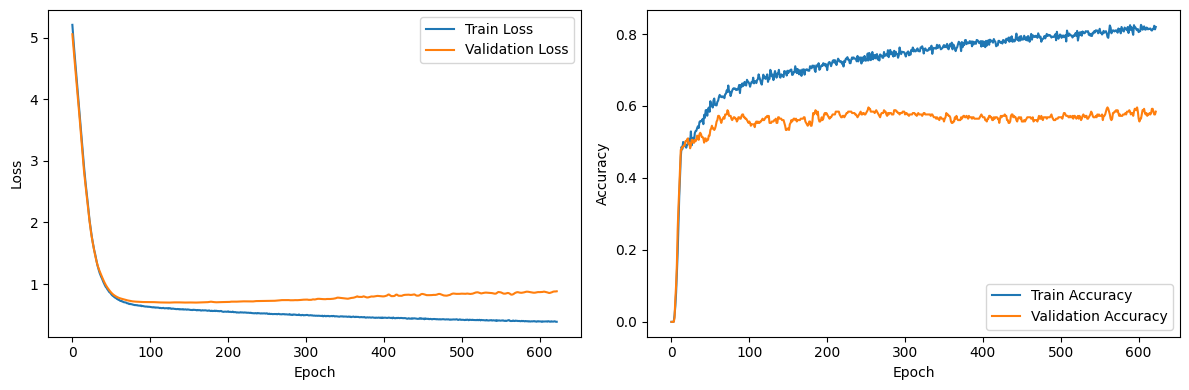


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6402, Val Loss: 3.5514, Train Acc: 0.4183, Val Acc: 0.4534
Epoch: 020, Train Loss: 2.2843, Val Loss: 2.2356, Train Acc: 0.5354, Val Acc: 0.5127
Epoch: 030, Train Loss: 1.4612, Val Loss: 1.4782, Train Acc: 0.5345, Val Acc: 0.5212
Epoch: 040, Train Loss: 1.0417, Val Loss: 1.0894, Train Acc: 0.5481, Val Acc: 0.5042
Epoch: 050, Train Loss: 0.8503, Val Loss: 0.9133, Train Acc: 0.5917, Val Acc: 0.5000
Epoch: 060, Train Loss: 0.7668, Val Loss: 0.8001, Train Acc: 0.6025, Val Acc: 0.5169
Epoch: 070, Train Loss: 0.7019, Val Loss: 0.7485, Train Acc: 0.6207, Val Acc: 0.5254
Epoch: 080, Train Loss: 0.6779, Val Loss: 0.7352, Train Acc: 0.6343, Val Acc: 0.5339
Epoch: 090, Train Loss: 0.6620, Val Loss: 0.7291, Train Acc: 0.6225, Val Acc: 0.5466
Epoch: 100, Train Loss: 0.6455, Val Loss: 0.7169, Train Acc: 0.6543, Val Acc: 0.5254
Epoch: 110, Train Loss: 0.6405, Val Loss: 0.7074, Tr

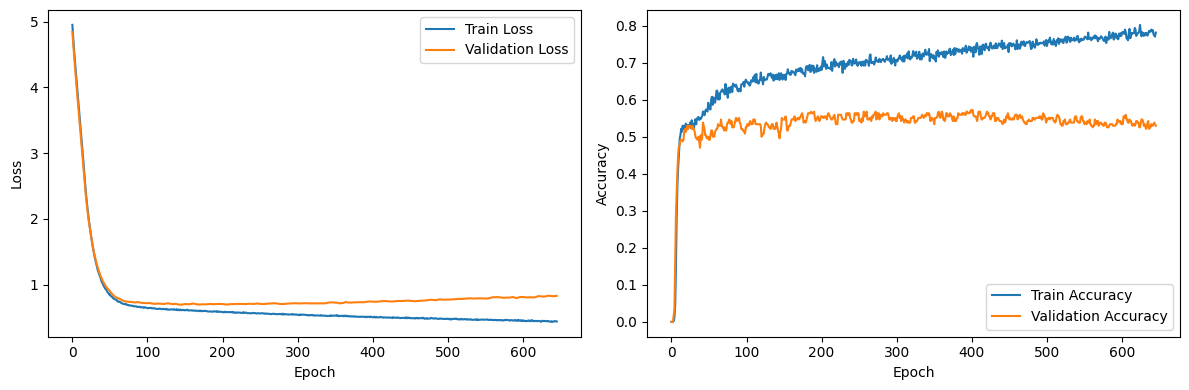


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0185, Val Loss: 2.8390, Train Acc: 0.5236, Val Acc: 0.4908
Epoch: 020, Train Loss: 2.0441, Val Loss: 1.9081, Train Acc: 0.5266, Val Acc: 0.4771
Epoch: 030, Train Loss: 1.3732, Val Loss: 1.3048, Train Acc: 0.5669, Val Acc: 0.5092
Epoch: 040, Train Loss: 1.0275, Val Loss: 1.0039, Train Acc: 0.5728, Val Acc: 0.5321
Epoch: 050, Train Loss: 0.8563, Val Loss: 0.8580, Train Acc: 0.5984, Val Acc: 0.5642
Epoch: 060, Train Loss: 0.7570, Val Loss: 0.7980, Train Acc: 0.6083, Val Acc: 0.5734
Epoch: 070, Train Loss: 0.7106, Val Loss: 0.7523, Train Acc: 0.6083, Val Acc: 0.5963
Epoch: 080, Train Loss: 0.6760, Val Loss: 0.7409, Train Acc: 0.6280, Val Acc: 0.5963
Epoch: 090, Train Loss: 0.6546, Val Loss: 0.7385, Train Acc: 0.6565, Val Acc: 0.5963
Epoch: 100, Train Loss: 0.6513, Val Loss: 0.7327, Train Acc: 0.6447, Val Acc: 0.5780
Epoch: 110, Train Loss: 0.6365, Val Loss: 0.7383, Tr

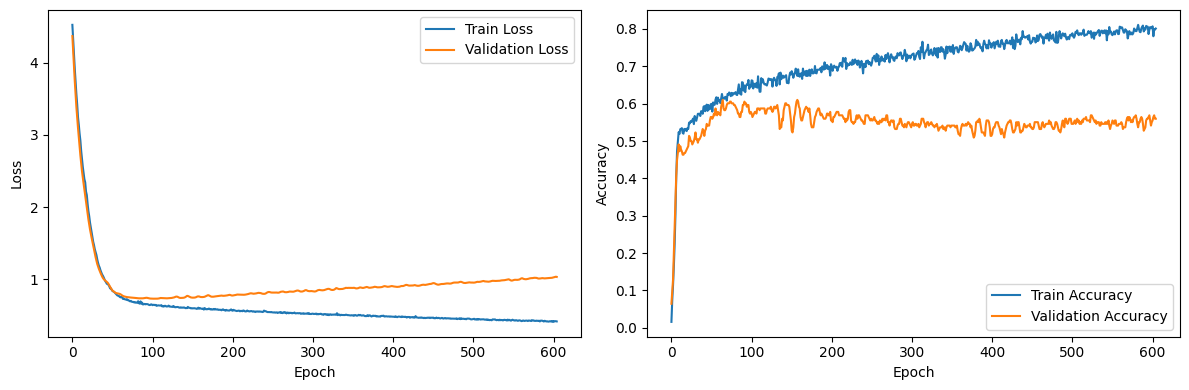


========== Run 5 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3377, Val Loss: 3.0816, Train Acc: 0.4279, Val Acc: 0.4173
Epoch: 020, Train Loss: 2.2310, Val Loss: 2.0595, Train Acc: 0.5262, Val Acc: 0.4812
Epoch: 030, Train Loss: 1.4962, Val Loss: 1.4172, Train Acc: 0.5391, Val Acc: 0.5301
Epoch: 040, Train Loss: 1.0805, Val Loss: 1.0818, Train Acc: 0.6011, Val Acc: 0.5188
Epoch: 050, Train Loss: 0.8728, Val Loss: 0.9156, Train Acc: 0.6044, Val Acc: 0.5677
Epoch: 060, Train Loss: 0.7648, Val Loss: 0.8196, Train Acc: 0.6044, Val Acc: 0.5865
Epoch: 070, Train Loss: 0.7044, Val Loss: 0.7707, Train Acc: 0.6205, Val Acc: 0.6128
Epoch: 080, Train Loss: 0.6776, Val Loss: 0.7486, Train Acc: 0.6124, Val Acc: 0.6128
Epoch: 090, Train Loss: 0.6528, Val Loss: 0.7394, Train Acc: 0.6438, Val Acc: 0.6090
Epoch: 100, Train Loss: 0.6414, Val Loss: 0.7378, Train Acc: 0.6382, Val Acc: 0.5940
Epoch: 110, Train Loss

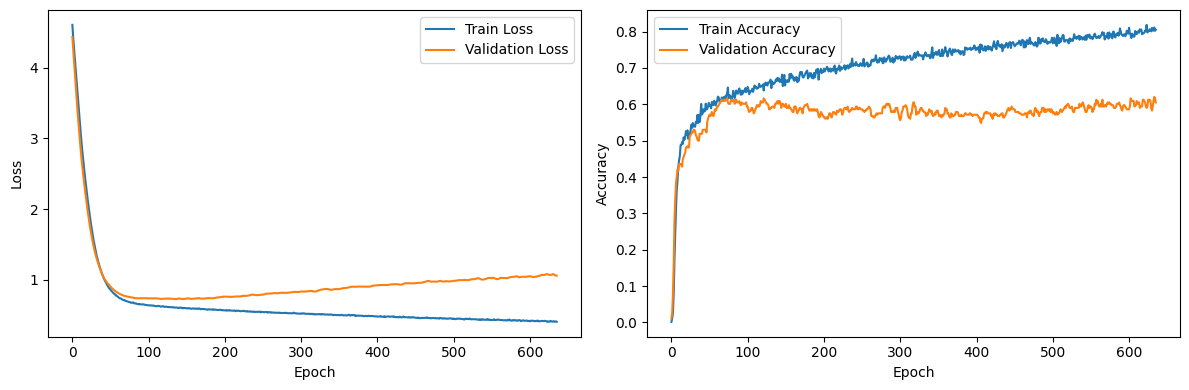


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8358, Val Loss: 2.7978, Train Acc: 0.4304, Val Acc: 0.4275
Epoch: 020, Train Loss: 1.9026, Val Loss: 1.8414, Train Acc: 0.5101, Val Acc: 0.5020
Epoch: 030, Train Loss: 1.3122, Val Loss: 1.2854, Train Acc: 0.5411, Val Acc: 0.5490
Epoch: 040, Train Loss: 0.9773, Val Loss: 0.9897, Train Acc: 0.5839, Val Acc: 0.5373
Epoch: 050, Train Loss: 0.8263, Val Loss: 0.8544, Train Acc: 0.6141, Val Acc: 0.5255
Epoch: 060, Train Loss: 0.7359, Val Loss: 0.7938, Train Acc: 0.6233, Val Acc: 0.5176
Epoch: 070, Train Loss: 0.7141, Val Loss: 0.7483, Train Acc: 0.6267, Val Acc: 0.5216
Epoch: 080, Train Loss: 0.6559, Val Loss: 0.7238, Train Acc: 0.6435, Val Acc: 0.5098
Epoch: 090, Train Loss: 0.6420, Val Loss: 0.7172, Train Acc: 0.6409, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.6202, Val Loss: 0.7121, Train Acc: 0.6594, Val Acc: 0.5176
Epoch: 110, Train Loss: 0.6232, Val Loss: 0.7015, Tr

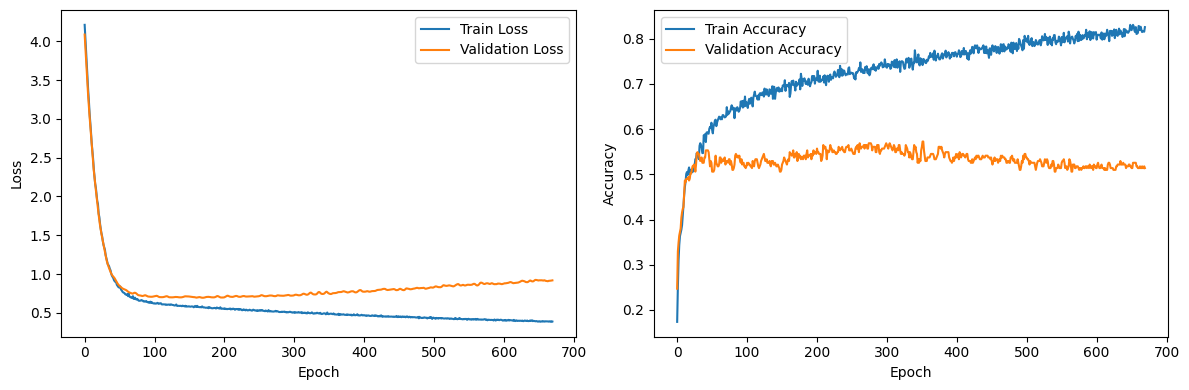


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2325, Val Loss: 3.1381, Train Acc: 0.5018, Val Acc: 0.4873
Epoch: 020, Train Loss: 2.1380, Val Loss: 2.1251, Train Acc: 0.5299, Val Acc: 0.4915
Epoch: 030, Train Loss: 1.4050, Val Loss: 1.4497, Train Acc: 0.5490, Val Acc: 0.4661
Epoch: 040, Train Loss: 1.0321, Val Loss: 1.0842, Train Acc: 0.5590, Val Acc: 0.4661
Epoch: 050, Train Loss: 0.8409, Val Loss: 0.8929, Train Acc: 0.5744, Val Acc: 0.4873
Epoch: 060, Train Loss: 0.7481, Val Loss: 0.8011, Train Acc: 0.6025, Val Acc: 0.4831
Epoch: 070, Train Loss: 0.6972, Val Loss: 0.7593, Train Acc: 0.6143, Val Acc: 0.5212
Epoch: 080, Train Loss: 0.6786, Val Loss: 0.7408, Train Acc: 0.6298, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.6583, Val Loss: 0.7267, Train Acc: 0.6334, Val Acc: 0.5339
Epoch: 100, Train Loss: 0.6523, Val Loss: 0.7204, Train Acc: 0.6289, Val Acc: 0.5212
Epoch: 110, Train Loss: 0.6445, Val Loss: 0.7193, Tr

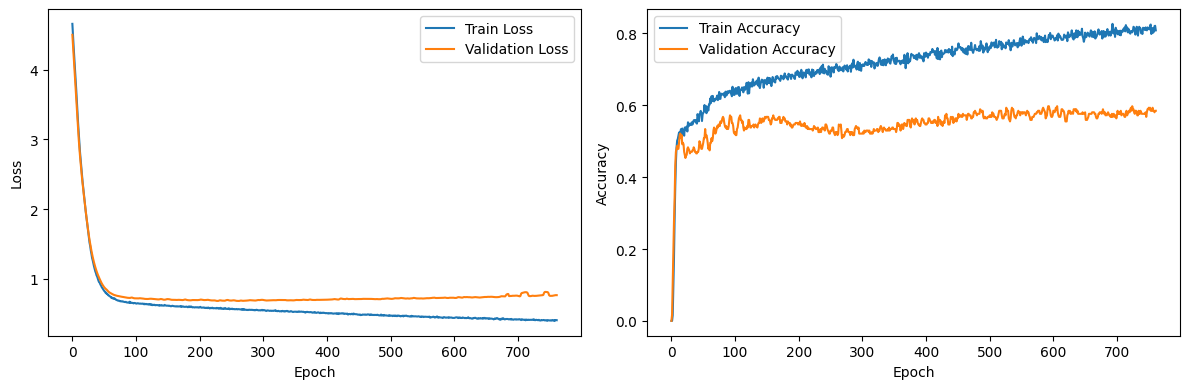


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2041, Val Loss: 3.0119, Train Acc: 0.4213, Val Acc: 0.4404
Epoch: 020, Train Loss: 2.1898, Val Loss: 2.1184, Train Acc: 0.5157, Val Acc: 0.4541
Epoch: 030, Train Loss: 1.4268, Val Loss: 1.4094, Train Acc: 0.5148, Val Acc: 0.4771
Epoch: 040, Train Loss: 1.0161, Val Loss: 1.0238, Train Acc: 0.5512, Val Acc: 0.4679
Epoch: 050, Train Loss: 0.8265, Val Loss: 0.8502, Train Acc: 0.5748, Val Acc: 0.5046
Epoch: 060, Train Loss: 0.7363, Val Loss: 0.7970, Train Acc: 0.5925, Val Acc: 0.5183
Epoch: 070, Train Loss: 0.6888, Val Loss: 0.7606, Train Acc: 0.6152, Val Acc: 0.5275
Epoch: 080, Train Loss: 0.6703, Val Loss: 0.7635, Train Acc: 0.6319, Val Acc: 0.5596
Epoch: 090, Train Loss: 0.6553, Val Loss: 0.7479, Train Acc: 0.6417, Val Acc: 0.5229
Epoch: 100, Train Loss: 0.6408, Val Loss: 0.7492, Train Acc: 0.6417, Val Acc: 0.5550
Epoch: 110, Train Loss: 0.6332, Val Loss: 0.7500, Tr

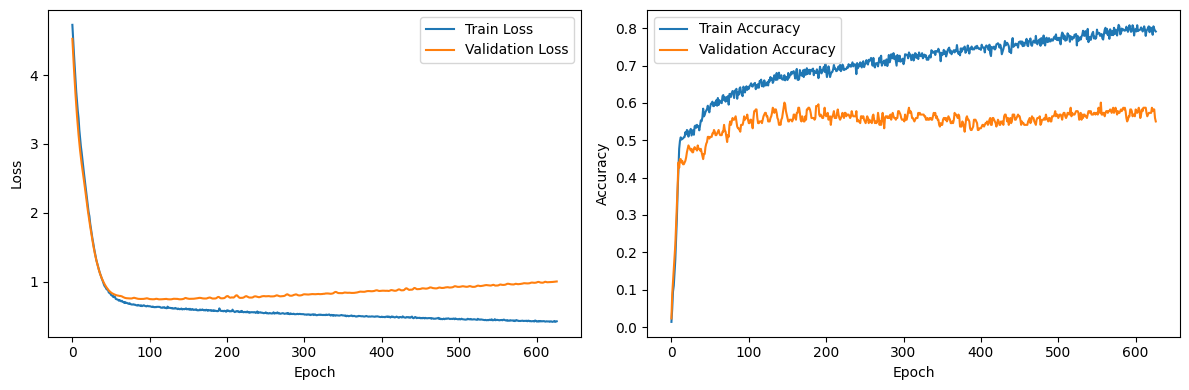


========== Run 6 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5862, Val Loss: 3.3448, Train Acc: 0.3932, Val Acc: 0.4361
Epoch: 020, Train Loss: 2.3541, Val Loss: 2.1274, Train Acc: 0.5616, Val Acc: 0.5376
Epoch: 030, Train Loss: 1.5229, Val Loss: 1.4110, Train Acc: 0.5689, Val Acc: 0.5414
Epoch: 040, Train Loss: 1.0622, Val Loss: 1.0484, Train Acc: 0.5882, Val Acc: 0.5602
Epoch: 050, Train Loss: 0.8432, Val Loss: 0.8736, Train Acc: 0.6164, Val Acc: 0.5902
Epoch: 060, Train Loss: 0.7420, Val Loss: 0.8183, Train Acc: 0.6140, Val Acc: 0.5602
Epoch: 070, Train Loss: 0.6938, Val Loss: 0.7795, Train Acc: 0.6197, Val Acc: 0.5714
Epoch: 080, Train Loss: 0.6623, Val Loss: 0.7657, Train Acc: 0.6390, Val Acc: 0.5752
Epoch: 090, Train Loss: 0.6448, Val Loss: 0.7633, Train Acc: 0.6471, Val Acc: 0.5602
Epoch: 100, Train Loss: 0.6349, Val Loss: 0.7585, Train Acc: 0.6454, Val Acc: 0.5752
Epoch: 110, Train Loss

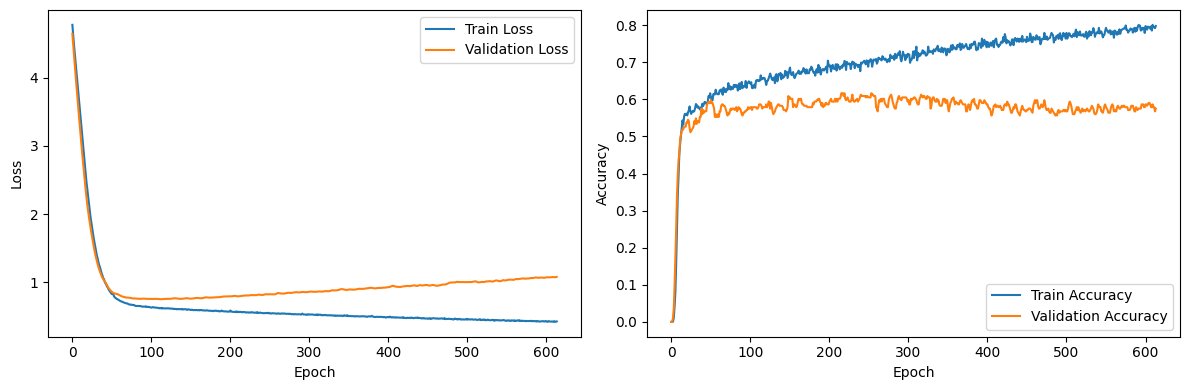


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3840, Val Loss: 3.2984, Train Acc: 0.4480, Val Acc: 0.4784
Epoch: 020, Train Loss: 2.1226, Val Loss: 2.0616, Train Acc: 0.5067, Val Acc: 0.4980
Epoch: 030, Train Loss: 1.4044, Val Loss: 1.3798, Train Acc: 0.5143, Val Acc: 0.5137
Epoch: 040, Train Loss: 1.0270, Val Loss: 1.0348, Train Acc: 0.5554, Val Acc: 0.5059
Epoch: 050, Train Loss: 0.8492, Val Loss: 0.8803, Train Acc: 0.5889, Val Acc: 0.5098
Epoch: 060, Train Loss: 0.7471, Val Loss: 0.8013, Train Acc: 0.6208, Val Acc: 0.5294
Epoch: 070, Train Loss: 0.6921, Val Loss: 0.7583, Train Acc: 0.6141, Val Acc: 0.5373
Epoch: 080, Train Loss: 0.6598, Val Loss: 0.7395, Train Acc: 0.6367, Val Acc: 0.5333
Epoch: 090, Train Loss: 0.6451, Val Loss: 0.7306, Train Acc: 0.6510, Val Acc: 0.5176
Epoch: 100, Train Loss: 0.6250, Val Loss: 0.7244, Train Acc: 0.6527, Val Acc: 0.5333
Epoch: 110, Train Loss: 0.6182, Val Loss: 0.7217, Tr

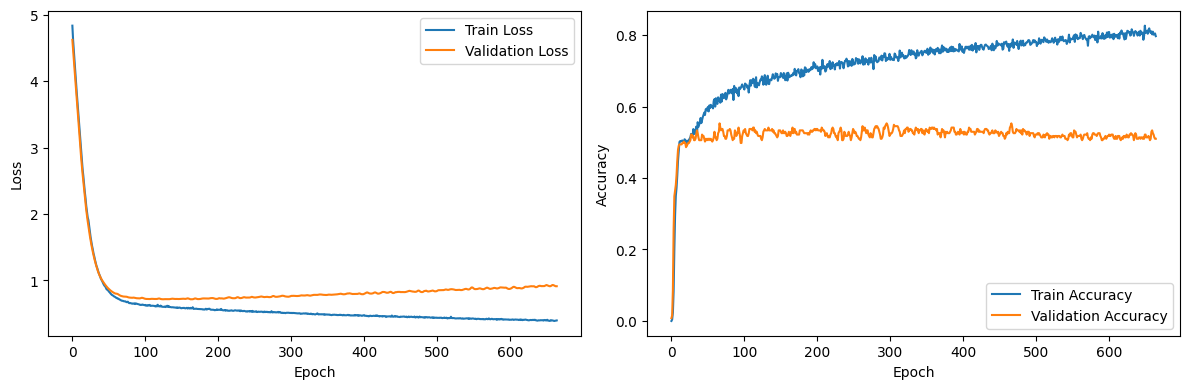


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2224, Val Loss: 3.0738, Train Acc: 0.4809, Val Acc: 0.4958
Epoch: 020, Train Loss: 2.1458, Val Loss: 2.1233, Train Acc: 0.5136, Val Acc: 0.5127
Epoch: 030, Train Loss: 1.4510, Val Loss: 1.4644, Train Acc: 0.5345, Val Acc: 0.5381
Epoch: 040, Train Loss: 1.0873, Val Loss: 1.1298, Train Acc: 0.5681, Val Acc: 0.5127
Epoch: 050, Train Loss: 0.9050, Val Loss: 0.9831, Train Acc: 0.5871, Val Acc: 0.5127
Epoch: 060, Train Loss: 0.7970, Val Loss: 0.8457, Train Acc: 0.6116, Val Acc: 0.5254
Epoch: 070, Train Loss: 0.7202, Val Loss: 0.7832, Train Acc: 0.6298, Val Acc: 0.5381
Epoch: 080, Train Loss: 0.6882, Val Loss: 0.7513, Train Acc: 0.6407, Val Acc: 0.5636
Epoch: 090, Train Loss: 0.6681, Val Loss: 0.7335, Train Acc: 0.6543, Val Acc: 0.5297
Epoch: 100, Train Loss: 0.6502, Val Loss: 0.7285, Train Acc: 0.6506, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6552, Val Loss: 0.7273, Tr

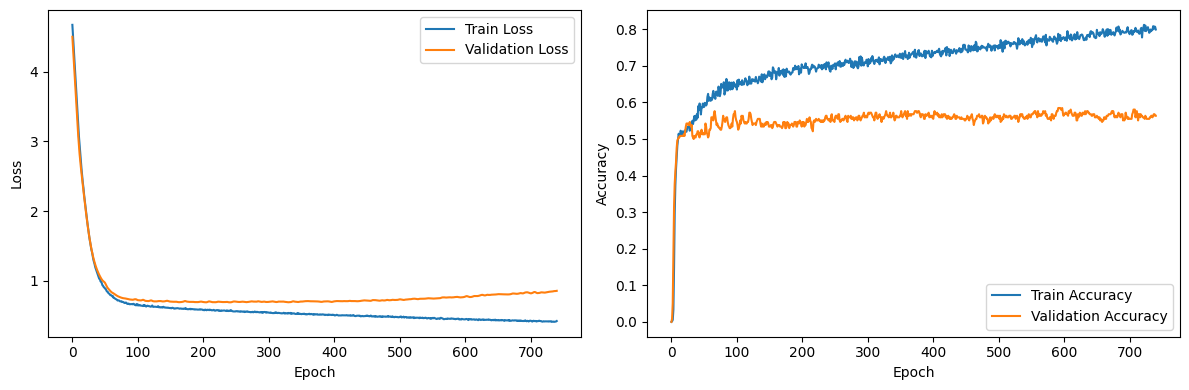


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3614, Val Loss: 3.1599, Train Acc: 0.4587, Val Acc: 0.4266
Epoch: 020, Train Loss: 2.2218, Val Loss: 2.1031, Train Acc: 0.5187, Val Acc: 0.4312
Epoch: 030, Train Loss: 1.5279, Val Loss: 1.4580, Train Acc: 0.5187, Val Acc: 0.4817
Epoch: 040, Train Loss: 1.1252, Val Loss: 1.0804, Train Acc: 0.5472, Val Acc: 0.5138
Epoch: 050, Train Loss: 0.9232, Val Loss: 0.8944, Train Acc: 0.5728, Val Acc: 0.5229
Epoch: 060, Train Loss: 0.7896, Val Loss: 0.8068, Train Acc: 0.5906, Val Acc: 0.5000
Epoch: 070, Train Loss: 0.7192, Val Loss: 0.7574, Train Acc: 0.6004, Val Acc: 0.5229
Epoch: 080, Train Loss: 0.6824, Val Loss: 0.7409, Train Acc: 0.6211, Val Acc: 0.5367
Epoch: 090, Train Loss: 0.6598, Val Loss: 0.7239, Train Acc: 0.6368, Val Acc: 0.5229
Epoch: 100, Train Loss: 0.6494, Val Loss: 0.7215, Train Acc: 0.6368, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.6329, Val Loss: 0.7178, Tr

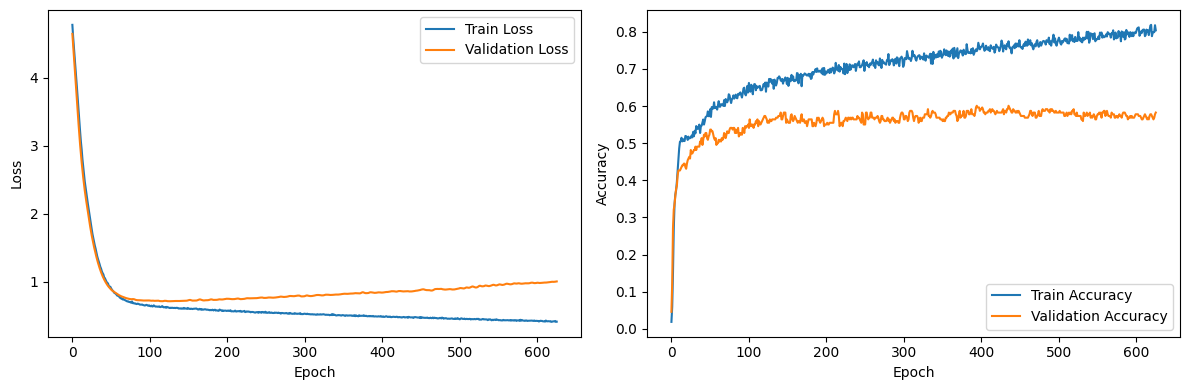


========== Run 7 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3278, Val Loss: 3.0629, Train Acc: 0.4343, Val Acc: 0.4925
Epoch: 020, Train Loss: 2.1541, Val Loss: 1.9933, Train Acc: 0.5471, Val Acc: 0.4662
Epoch: 030, Train Loss: 1.4240, Val Loss: 1.3535, Train Acc: 0.5697, Val Acc: 0.5113
Epoch: 040, Train Loss: 1.0360, Val Loss: 1.0495, Train Acc: 0.5729, Val Acc: 0.5038
Epoch: 050, Train Loss: 0.8498, Val Loss: 0.8973, Train Acc: 0.6011, Val Acc: 0.5338
Epoch: 060, Train Loss: 0.7501, Val Loss: 0.8212, Train Acc: 0.6172, Val Acc: 0.5414
Epoch: 070, Train Loss: 0.6992, Val Loss: 0.7931, Train Acc: 0.6221, Val Acc: 0.5301
Epoch: 080, Train Loss: 0.6711, Val Loss: 0.7641, Train Acc: 0.6189, Val Acc: 0.5639
Epoch: 090, Train Loss: 0.6535, Val Loss: 0.7557, Train Acc: 0.6471, Val Acc: 0.5752
Epoch: 100, Train Loss: 0.6447, Val Loss: 0.7452, Train Acc: 0.6471, Val Acc: 0.5752
Epoch: 110, Train Loss

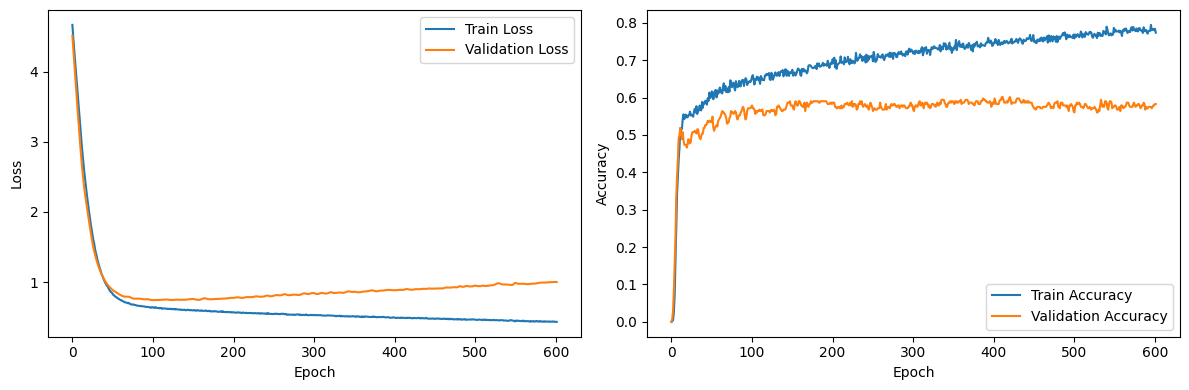


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3309, Val Loss: 3.2290, Train Acc: 0.4547, Val Acc: 0.4667
Epoch: 020, Train Loss: 2.0860, Val Loss: 2.0548, Train Acc: 0.5277, Val Acc: 0.4863
Epoch: 030, Train Loss: 1.3792, Val Loss: 1.3650, Train Acc: 0.5419, Val Acc: 0.4941
Epoch: 040, Train Loss: 1.0416, Val Loss: 1.0576, Train Acc: 0.5772, Val Acc: 0.5216
Epoch: 050, Train Loss: 0.8647, Val Loss: 0.9085, Train Acc: 0.5914, Val Acc: 0.5176
Epoch: 060, Train Loss: 0.7720, Val Loss: 0.8254, Train Acc: 0.5998, Val Acc: 0.4941
Epoch: 070, Train Loss: 0.6979, Val Loss: 0.7801, Train Acc: 0.6326, Val Acc: 0.5137
Epoch: 080, Train Loss: 0.6680, Val Loss: 0.7535, Train Acc: 0.6367, Val Acc: 0.4941
Epoch: 090, Train Loss: 0.6426, Val Loss: 0.7528, Train Acc: 0.6577, Val Acc: 0.4902
Epoch: 100, Train Loss: 0.6202, Val Loss: 0.7426, Train Acc: 0.6611, Val Acc: 0.5176
Epoch: 110, Train Loss: 0.6130, Val Loss: 0.7224, Tr

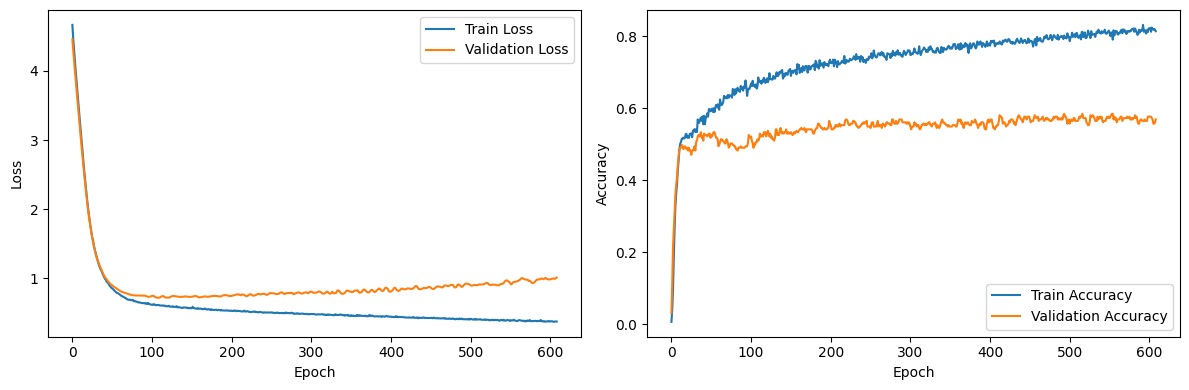


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1966, Val Loss: 3.1249, Train Acc: 0.4809, Val Acc: 0.4576
Epoch: 020, Train Loss: 2.1574, Val Loss: 2.1622, Train Acc: 0.5163, Val Acc: 0.4534
Epoch: 030, Train Loss: 1.4475, Val Loss: 1.5072, Train Acc: 0.5544, Val Acc: 0.5085
Epoch: 040, Train Loss: 1.0692, Val Loss: 1.1303, Train Acc: 0.5726, Val Acc: 0.5000
Epoch: 050, Train Loss: 0.8706, Val Loss: 0.9520, Train Acc: 0.6134, Val Acc: 0.5042
Epoch: 060, Train Loss: 0.7751, Val Loss: 0.8373, Train Acc: 0.6080, Val Acc: 0.5381
Epoch: 070, Train Loss: 0.7098, Val Loss: 0.7854, Train Acc: 0.6189, Val Acc: 0.5254
Epoch: 080, Train Loss: 0.6753, Val Loss: 0.7520, Train Acc: 0.6497, Val Acc: 0.5424
Epoch: 090, Train Loss: 0.6542, Val Loss: 0.7337, Train Acc: 0.6525, Val Acc: 0.5127
Epoch: 100, Train Loss: 0.6411, Val Loss: 0.7278, Train Acc: 0.6452, Val Acc: 0.5254
Epoch: 110, Train Loss: 0.6331, Val Loss: 0.7246, Tr

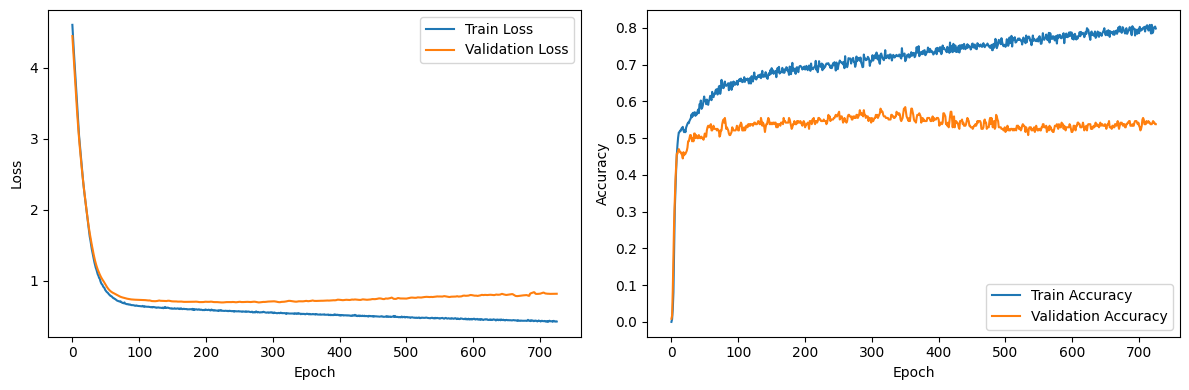


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3012, Val Loss: 3.1120, Train Acc: 0.4085, Val Acc: 0.4862
Epoch: 020, Train Loss: 2.3157, Val Loss: 2.1840, Train Acc: 0.5413, Val Acc: 0.5000
Epoch: 030, Train Loss: 1.5120, Val Loss: 1.4590, Train Acc: 0.5571, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.1254, Val Loss: 1.1030, Train Acc: 0.5492, Val Acc: 0.5000
Epoch: 050, Train Loss: 0.8984, Val Loss: 0.8996, Train Acc: 0.5906, Val Acc: 0.5138
Epoch: 060, Train Loss: 0.7836, Val Loss: 0.8079, Train Acc: 0.6063, Val Acc: 0.5275
Epoch: 070, Train Loss: 0.7155, Val Loss: 0.7695, Train Acc: 0.6132, Val Acc: 0.5321
Epoch: 080, Train Loss: 0.6788, Val Loss: 0.7364, Train Acc: 0.6230, Val Acc: 0.5321
Epoch: 090, Train Loss: 0.6570, Val Loss: 0.7308, Train Acc: 0.6339, Val Acc: 0.5780
Epoch: 100, Train Loss: 0.6418, Val Loss: 0.7270, Train Acc: 0.6378, Val Acc: 0.5642
Epoch: 110, Train Loss: 0.6448, Val Loss: 0.7210, Tr

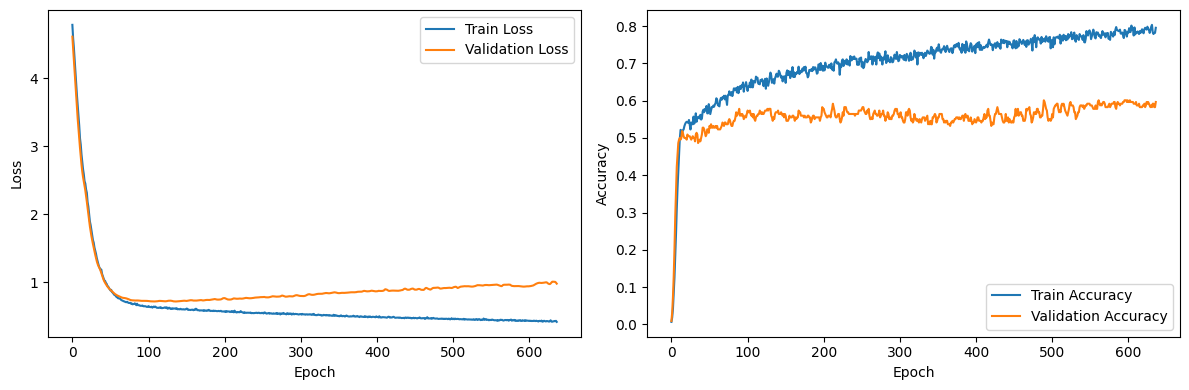


========== Run 8 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1620, Val Loss: 2.9618, Train Acc: 0.5093, Val Acc: 0.4624
Epoch: 020, Train Loss: 2.0681, Val Loss: 1.9256, Train Acc: 0.5359, Val Acc: 0.4925
Epoch: 030, Train Loss: 1.3676, Val Loss: 1.3269, Train Acc: 0.5512, Val Acc: 0.5113
Epoch: 040, Train Loss: 0.9958, Val Loss: 0.9963, Train Acc: 0.5786, Val Acc: 0.5376
Epoch: 050, Train Loss: 0.8193, Val Loss: 0.8392, Train Acc: 0.5955, Val Acc: 0.5677
Epoch: 060, Train Loss: 0.7330, Val Loss: 0.7666, Train Acc: 0.6180, Val Acc: 0.5865
Epoch: 070, Train Loss: 0.6933, Val Loss: 0.7398, Train Acc: 0.6100, Val Acc: 0.5940
Epoch: 080, Train Loss: 0.6613, Val Loss: 0.7172, Train Acc: 0.6277, Val Acc: 0.5902
Epoch: 090, Train Loss: 0.6519, Val Loss: 0.7070, Train Acc: 0.6479, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.6412, Val Loss: 0.7139, Train Acc: 0.6390, Val Acc: 0.5789
Epoch: 110, Train Loss

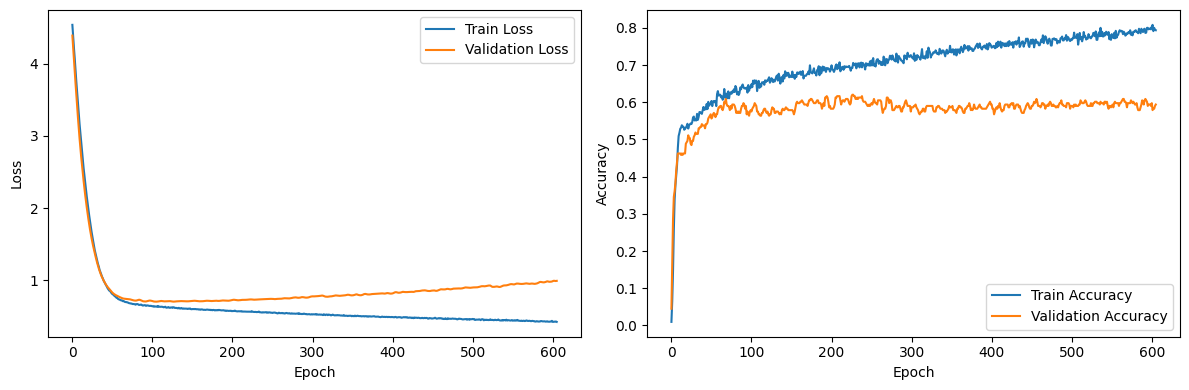


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1619, Val Loss: 3.0415, Train Acc: 0.4958, Val Acc: 0.4471
Epoch: 020, Train Loss: 2.0036, Val Loss: 1.9272, Train Acc: 0.5327, Val Acc: 0.4980
Epoch: 030, Train Loss: 1.3188, Val Loss: 1.3029, Train Acc: 0.5428, Val Acc: 0.4941
Epoch: 040, Train Loss: 1.0026, Val Loss: 1.0155, Train Acc: 0.5688, Val Acc: 0.5176
Epoch: 050, Train Loss: 0.8463, Val Loss: 0.8678, Train Acc: 0.5898, Val Acc: 0.5137
Epoch: 060, Train Loss: 0.7481, Val Loss: 0.7885, Train Acc: 0.6082, Val Acc: 0.5294
Epoch: 070, Train Loss: 0.6982, Val Loss: 0.7617, Train Acc: 0.6342, Val Acc: 0.5373
Epoch: 080, Train Loss: 0.6570, Val Loss: 0.7452, Train Acc: 0.6510, Val Acc: 0.5569
Epoch: 090, Train Loss: 0.6355, Val Loss: 0.7314, Train Acc: 0.6619, Val Acc: 0.5490
Epoch: 100, Train Loss: 0.6203, Val Loss: 0.7350, Train Acc: 0.6728, Val Acc: 0.5373
Epoch: 110, Train Loss: 0.6125, Val Loss: 0.7321, Tr

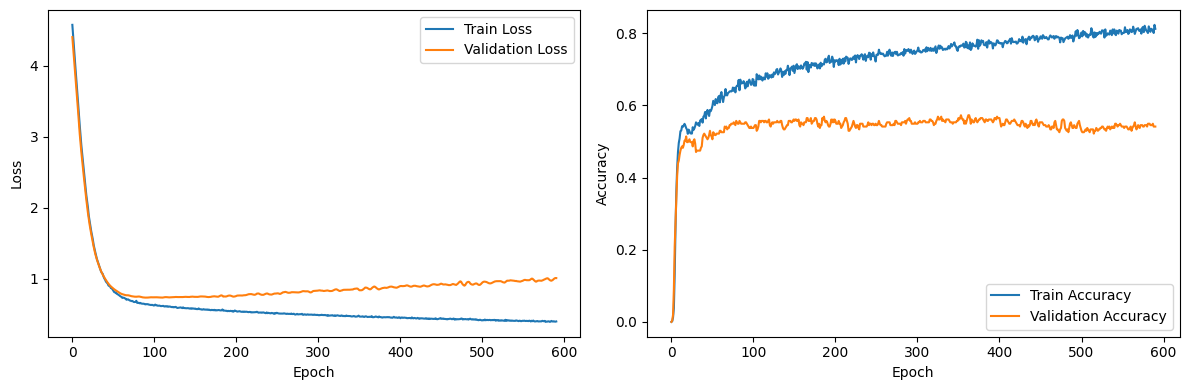


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0379, Val Loss: 2.9668, Train Acc: 0.4483, Val Acc: 0.5085
Epoch: 020, Train Loss: 2.0942, Val Loss: 2.0998, Train Acc: 0.5109, Val Acc: 0.5381
Epoch: 030, Train Loss: 1.4125, Val Loss: 1.4497, Train Acc: 0.5218, Val Acc: 0.5254
Epoch: 040, Train Loss: 1.0468, Val Loss: 1.0966, Train Acc: 0.5354, Val Acc: 0.5127
Epoch: 050, Train Loss: 0.8638, Val Loss: 0.9178, Train Acc: 0.5535, Val Acc: 0.5000
Epoch: 060, Train Loss: 0.7674, Val Loss: 0.8119, Train Acc: 0.5744, Val Acc: 0.5000
Epoch: 070, Train Loss: 0.7022, Val Loss: 0.7609, Train Acc: 0.6225, Val Acc: 0.5466
Epoch: 080, Train Loss: 0.6716, Val Loss: 0.7403, Train Acc: 0.6289, Val Acc: 0.5085
Epoch: 090, Train Loss: 0.6551, Val Loss: 0.7269, Train Acc: 0.6497, Val Acc: 0.5424
Epoch: 100, Train Loss: 0.6541, Val Loss: 0.7304, Train Acc: 0.6407, Val Acc: 0.5339
Epoch: 110, Train Loss: 0.6344, Val Loss: 0.7209, Tr

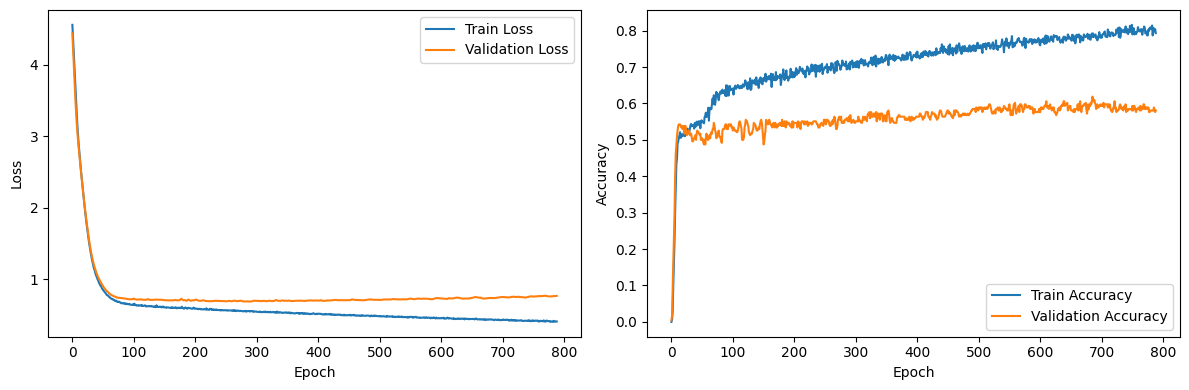


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3077, Val Loss: 3.1287, Train Acc: 0.5266, Val Acc: 0.5046
Epoch: 020, Train Loss: 2.0888, Val Loss: 1.9708, Train Acc: 0.5571, Val Acc: 0.5183
Epoch: 030, Train Loss: 1.3831, Val Loss: 1.3229, Train Acc: 0.5659, Val Acc: 0.5596
Epoch: 040, Train Loss: 1.0125, Val Loss: 1.0169, Train Acc: 0.5837, Val Acc: 0.5459
Epoch: 050, Train Loss: 0.8437, Val Loss: 0.8879, Train Acc: 0.5797, Val Acc: 0.5505
Epoch: 060, Train Loss: 0.7405, Val Loss: 0.8108, Train Acc: 0.6142, Val Acc: 0.5459
Epoch: 070, Train Loss: 0.6927, Val Loss: 0.7801, Train Acc: 0.6280, Val Acc: 0.5413
Epoch: 080, Train Loss: 0.6681, Val Loss: 0.7635, Train Acc: 0.6358, Val Acc: 0.5505
Epoch: 090, Train Loss: 0.6566, Val Loss: 0.7661, Train Acc: 0.6398, Val Acc: 0.5550
Epoch: 100, Train Loss: 0.6365, Val Loss: 0.7610, Train Acc: 0.6516, Val Acc: 0.5367
Epoch: 110, Train Loss: 0.6262, Val Loss: 0.7628, Tr

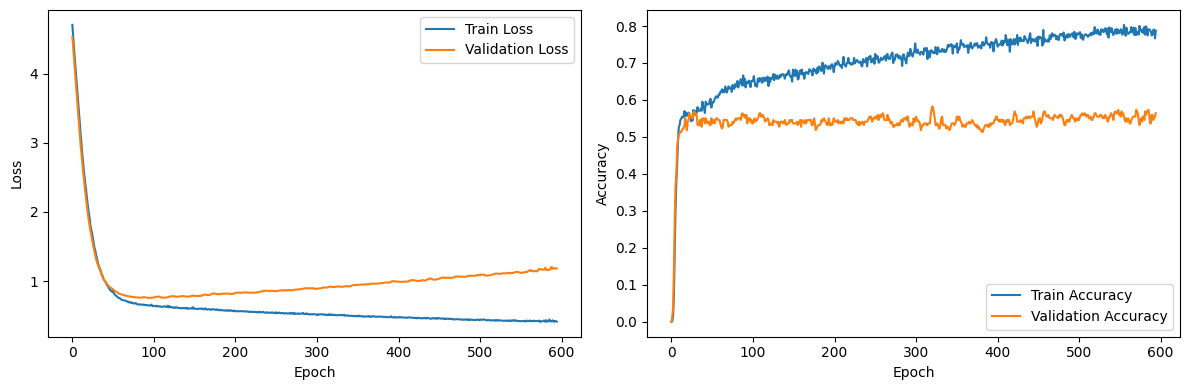


========== Run 9 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4933, Val Loss: 3.2194, Train Acc: 0.4077, Val Acc: 0.4662
Epoch: 020, Train Loss: 2.2352, Val Loss: 2.0404, Train Acc: 0.5479, Val Acc: 0.5150
Epoch: 030, Train Loss: 1.4583, Val Loss: 1.3809, Train Acc: 0.5568, Val Acc: 0.5075
Epoch: 040, Train Loss: 1.0346, Val Loss: 1.0393, Train Acc: 0.5770, Val Acc: 0.5150
Epoch: 050, Train Loss: 0.8416, Val Loss: 0.8620, Train Acc: 0.5890, Val Acc: 0.5489
Epoch: 060, Train Loss: 0.7220, Val Loss: 0.7842, Train Acc: 0.6245, Val Acc: 0.5526
Epoch: 070, Train Loss: 0.6810, Val Loss: 0.7557, Train Acc: 0.6350, Val Acc: 0.5677
Epoch: 080, Train Loss: 0.6530, Val Loss: 0.7483, Train Acc: 0.6511, Val Acc: 0.5639
Epoch: 090, Train Loss: 0.6436, Val Loss: 0.7419, Train Acc: 0.6414, Val Acc: 0.5677
Epoch: 100, Train Loss: 0.6314, Val Loss: 0.7398, Train Acc: 0.6446, Val Acc: 0.5789
Epoch: 110, Train Loss

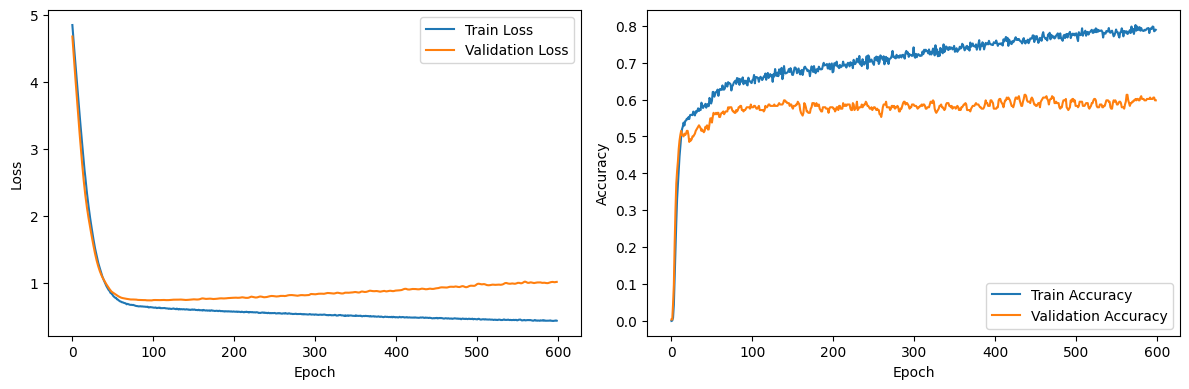


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1326, Val Loss: 3.0569, Train Acc: 0.3951, Val Acc: 0.4510
Epoch: 020, Train Loss: 2.0664, Val Loss: 2.0192, Train Acc: 0.5721, Val Acc: 0.5098
Epoch: 030, Train Loss: 1.3733, Val Loss: 1.3621, Train Acc: 0.5931, Val Acc: 0.5490
Epoch: 040, Train Loss: 1.0263, Val Loss: 1.0431, Train Acc: 0.6116, Val Acc: 0.5608
Epoch: 050, Train Loss: 0.8454, Val Loss: 0.8705, Train Acc: 0.6183, Val Acc: 0.5294
Epoch: 060, Train Loss: 0.7441, Val Loss: 0.7864, Train Acc: 0.6426, Val Acc: 0.5255
Epoch: 070, Train Loss: 0.6826, Val Loss: 0.7516, Train Acc: 0.6460, Val Acc: 0.5255
Epoch: 080, Train Loss: 0.6548, Val Loss: 0.7338, Train Acc: 0.6485, Val Acc: 0.5255
Epoch: 090, Train Loss: 0.6415, Val Loss: 0.7213, Train Acc: 0.6720, Val Acc: 0.5451
Epoch: 100, Train Loss: 0.6288, Val Loss: 0.7234, Train Acc: 0.6686, Val Acc: 0.5451
Epoch: 110, Train Loss: 0.6123, Val Loss: 0.7130, Tr

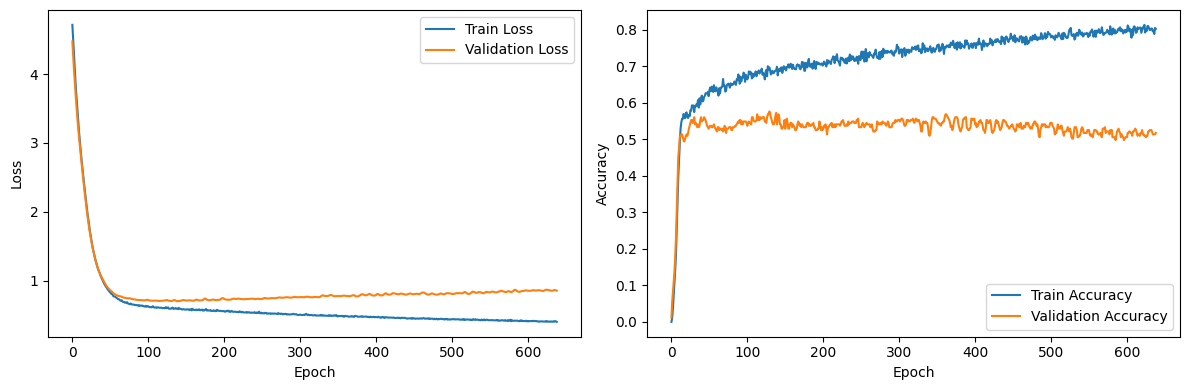


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2406, Val Loss: 3.1114, Train Acc: 0.4646, Val Acc: 0.4788
Epoch: 020, Train Loss: 2.0575, Val Loss: 2.0494, Train Acc: 0.5263, Val Acc: 0.5042
Epoch: 030, Train Loss: 1.3723, Val Loss: 1.3888, Train Acc: 0.5417, Val Acc: 0.4958
Epoch: 040, Train Loss: 0.9990, Val Loss: 1.0522, Train Acc: 0.5626, Val Acc: 0.4619
Epoch: 050, Train Loss: 0.8299, Val Loss: 0.8749, Train Acc: 0.6080, Val Acc: 0.5042
Epoch: 060, Train Loss: 0.7436, Val Loss: 0.7999, Train Acc: 0.6180, Val Acc: 0.5297
Epoch: 070, Train Loss: 0.7057, Val Loss: 0.7662, Train Acc: 0.6289, Val Acc: 0.5339
Epoch: 080, Train Loss: 0.6736, Val Loss: 0.7451, Train Acc: 0.6261, Val Acc: 0.5466
Epoch: 090, Train Loss: 0.6587, Val Loss: 0.7374, Train Acc: 0.6443, Val Acc: 0.5847
Epoch: 100, Train Loss: 0.6402, Val Loss: 0.7170, Train Acc: 0.6606, Val Acc: 0.5847
Epoch: 110, Train Loss: 0.6337, Val Loss: 0.7124, Tr

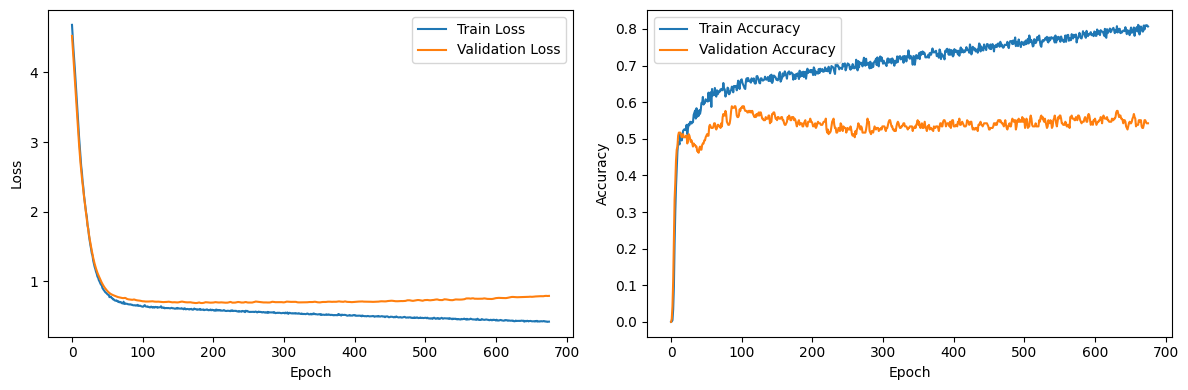


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4649, Val Loss: 3.2831, Train Acc: 0.3996, Val Acc: 0.4266
Epoch: 020, Train Loss: 2.1599, Val Loss: 2.0050, Train Acc: 0.5069, Val Acc: 0.4725
Epoch: 030, Train Loss: 1.3979, Val Loss: 1.3220, Train Acc: 0.5443, Val Acc: 0.4817
Epoch: 040, Train Loss: 1.0297, Val Loss: 1.0157, Train Acc: 0.5620, Val Acc: 0.4587
Epoch: 050, Train Loss: 0.8382, Val Loss: 0.8665, Train Acc: 0.5925, Val Acc: 0.4771
Epoch: 060, Train Loss: 0.7398, Val Loss: 0.7926, Train Acc: 0.6122, Val Acc: 0.5138
Epoch: 070, Train Loss: 0.6966, Val Loss: 0.7580, Train Acc: 0.6201, Val Acc: 0.5183
Epoch: 080, Train Loss: 0.6683, Val Loss: 0.7412, Train Acc: 0.6398, Val Acc: 0.5183
Epoch: 090, Train Loss: 0.6429, Val Loss: 0.7336, Train Acc: 0.6388, Val Acc: 0.5275
Epoch: 100, Train Loss: 0.6323, Val Loss: 0.7357, Train Acc: 0.6594, Val Acc: 0.5092
Epoch: 110, Train Loss: 0.6262, Val Loss: 0.7431, Tr

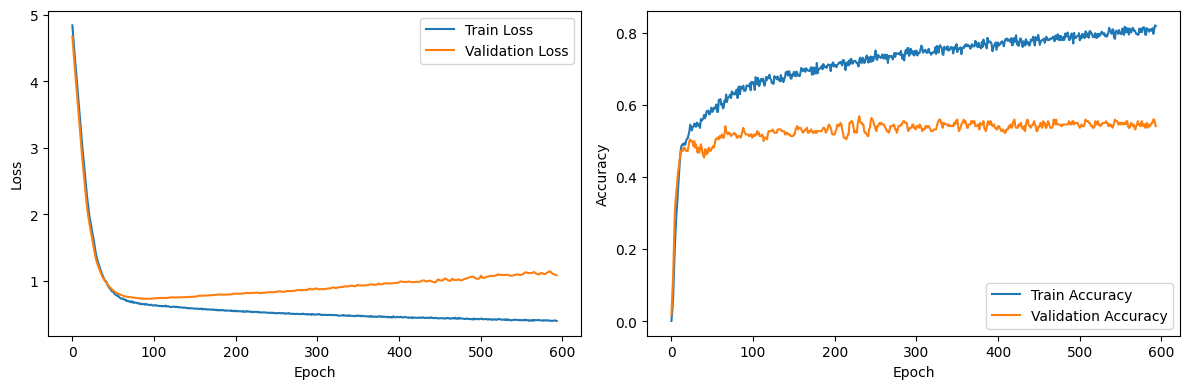


========== Run 10 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4572, Val Loss: 3.2244, Train Acc: 0.4875, Val Acc: 0.5451
Epoch: 020, Train Loss: 2.2557, Val Loss: 2.0771, Train Acc: 0.5544, Val Acc: 0.5827
Epoch: 030, Train Loss: 1.4790, Val Loss: 1.4018, Train Acc: 0.5697, Val Acc: 0.5639
Epoch: 040, Train Loss: 1.0539, Val Loss: 1.0589, Train Acc: 0.5850, Val Acc: 0.5414
Epoch: 050, Train Loss: 0.8521, Val Loss: 0.8918, Train Acc: 0.5923, Val Acc: 0.5902
Epoch: 060, Train Loss: 0.7536, Val Loss: 0.8088, Train Acc: 0.6092, Val Acc: 0.5940
Epoch: 070, Train Loss: 0.7028, Val Loss: 0.7716, Train Acc: 0.6092, Val Acc: 0.5789
Epoch: 080, Train Loss: 0.6683, Val Loss: 0.7570, Train Acc: 0.6261, Val Acc: 0.5639
Epoch: 090, Train Loss: 0.6540, Val Loss: 0.7541, Train Acc: 0.6317, Val Acc: 0.5489
Epoch: 100, Train Loss: 0.6426, Val Loss: 0.7437, Train Acc: 0.6414, Val Acc: 0.5602
Epoch: 110, Train Los

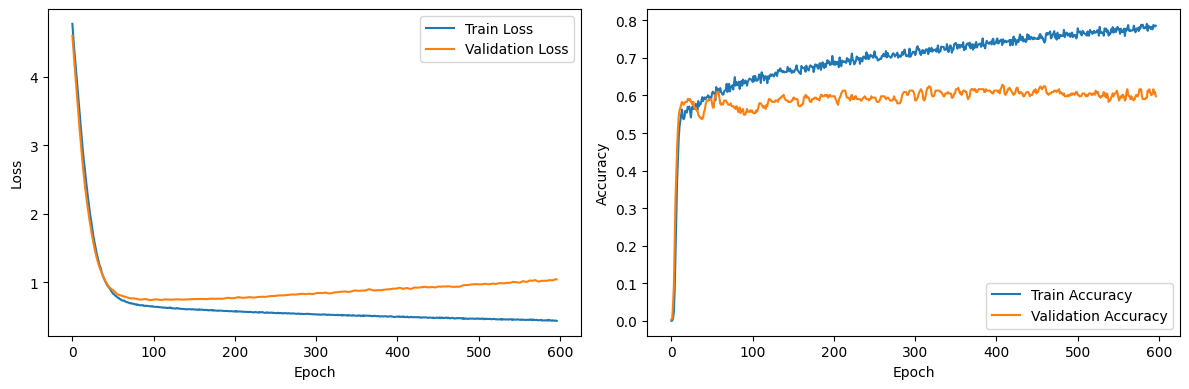


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3621, Val Loss: 3.2646, Train Acc: 0.4203, Val Acc: 0.4471
Epoch: 020, Train Loss: 2.1277, Val Loss: 2.0740, Train Acc: 0.5545, Val Acc: 0.5098
Epoch: 030, Train Loss: 1.4378, Val Loss: 1.4330, Train Acc: 0.5688, Val Acc: 0.5137
Epoch: 040, Train Loss: 1.0735, Val Loss: 1.0947, Train Acc: 0.5973, Val Acc: 0.5216
Epoch: 050, Train Loss: 0.9074, Val Loss: 0.9014, Train Acc: 0.5914, Val Acc: 0.5608
Epoch: 060, Train Loss: 0.7808, Val Loss: 0.8143, Train Acc: 0.6233, Val Acc: 0.5608
Epoch: 070, Train Loss: 0.7033, Val Loss: 0.7669, Train Acc: 0.6451, Val Acc: 0.5608
Epoch: 080, Train Loss: 0.6888, Val Loss: 0.7417, Train Acc: 0.6527, Val Acc: 0.5608
Epoch: 090, Train Loss: 0.6478, Val Loss: 0.7243, Train Acc: 0.6577, Val Acc: 0.5765
Epoch: 100, Train Loss: 0.6335, Val Loss: 0.7190, Train Acc: 0.6678, Val Acc: 0.5725
Epoch: 110, Train Loss: 0.6170, Val Loss: 0.7067, Tr

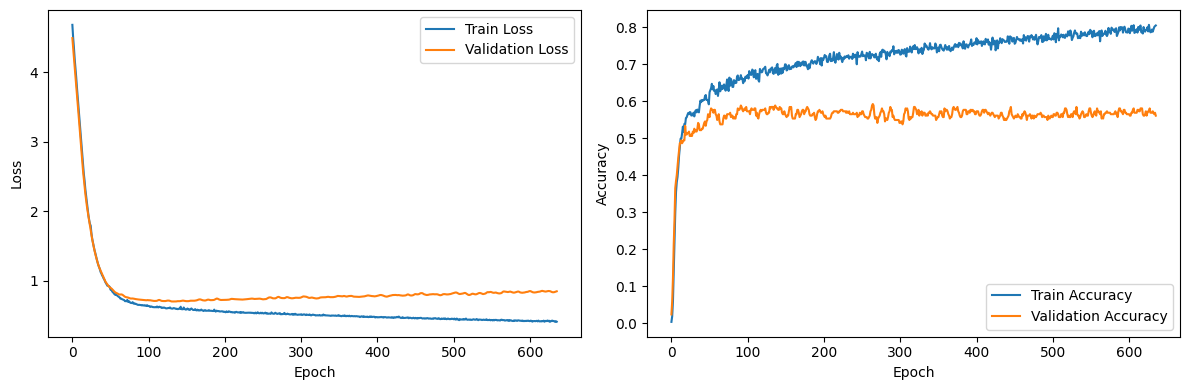


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2524, Val Loss: 3.1982, Train Acc: 0.4510, Val Acc: 0.4195
Epoch: 020, Train Loss: 2.1883, Val Loss: 2.1688, Train Acc: 0.5154, Val Acc: 0.4915
Epoch: 030, Train Loss: 1.4576, Val Loss: 1.5113, Train Acc: 0.5436, Val Acc: 0.4703
Epoch: 040, Train Loss: 1.0718, Val Loss: 1.1102, Train Acc: 0.5690, Val Acc: 0.4576
Epoch: 050, Train Loss: 0.8678, Val Loss: 0.9289, Train Acc: 0.5917, Val Acc: 0.4958
Epoch: 060, Train Loss: 0.7655, Val Loss: 0.8224, Train Acc: 0.6189, Val Acc: 0.5085
Epoch: 070, Train Loss: 0.7104, Val Loss: 0.7710, Train Acc: 0.6325, Val Acc: 0.5636
Epoch: 080, Train Loss: 0.6748, Val Loss: 0.7410, Train Acc: 0.6425, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.6623, Val Loss: 0.7285, Train Acc: 0.6488, Val Acc: 0.5508
Epoch: 100, Train Loss: 0.6444, Val Loss: 0.7212, Train Acc: 0.6407, Val Acc: 0.5678
Epoch: 110, Train Loss: 0.6341, Val Loss: 0.7132, Tr

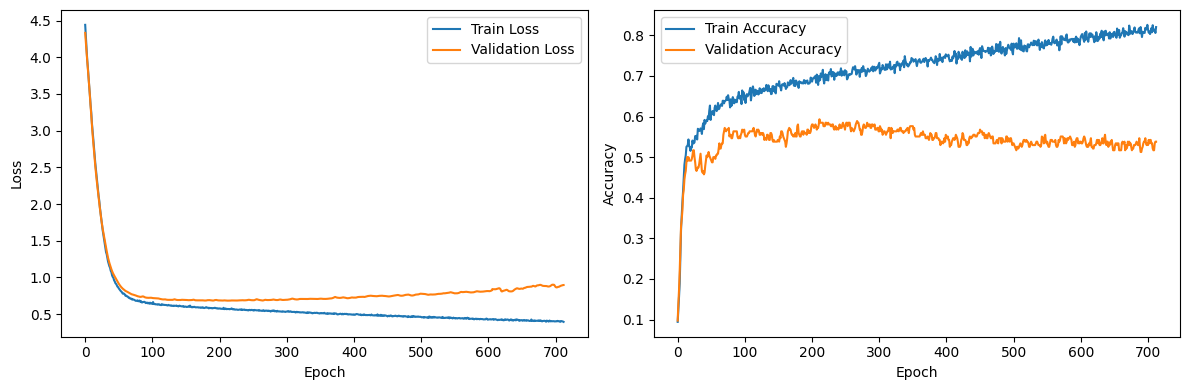


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1481, Val Loss: 2.9225, Train Acc: 0.4813, Val Acc: 0.5092
Epoch: 020, Train Loss: 2.0483, Val Loss: 1.8694, Train Acc: 0.5285, Val Acc: 0.5183
Epoch: 030, Train Loss: 1.3936, Val Loss: 1.2997, Train Acc: 0.5413, Val Acc: 0.5092
Epoch: 040, Train Loss: 1.0451, Val Loss: 1.0187, Train Acc: 0.5758, Val Acc: 0.4862
Epoch: 050, Train Loss: 0.8566, Val Loss: 0.8775, Train Acc: 0.5797, Val Acc: 0.5092
Epoch: 060, Train Loss: 0.7558, Val Loss: 0.7988, Train Acc: 0.5974, Val Acc: 0.5183
Epoch: 070, Train Loss: 0.6987, Val Loss: 0.7647, Train Acc: 0.6260, Val Acc: 0.5229
Epoch: 080, Train Loss: 0.6611, Val Loss: 0.7526, Train Acc: 0.6388, Val Acc: 0.5275
Epoch: 090, Train Loss: 0.6505, Val Loss: 0.7505, Train Acc: 0.6368, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.6326, Val Loss: 0.7469, Train Acc: 0.6555, Val Acc: 0.5596
Epoch: 110, Train Loss: 0.6323, Val Loss: 0.7481, Tr

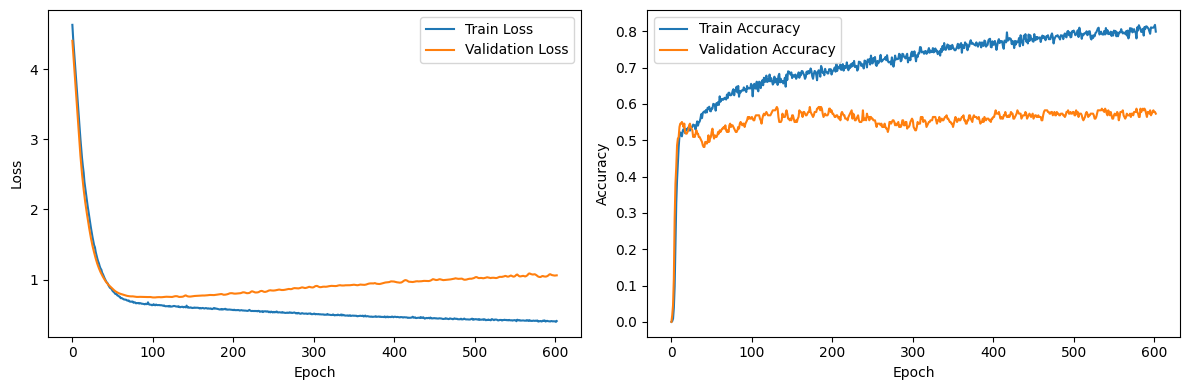


========== Run 11 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2346, Val Loss: 2.9572, Train Acc: 0.4923, Val Acc: 0.5338
Epoch: 020, Train Loss: 2.0489, Val Loss: 1.8686, Train Acc: 0.5576, Val Acc: 0.5376
Epoch: 030, Train Loss: 1.3128, Val Loss: 1.2340, Train Acc: 0.5633, Val Acc: 0.5338
Epoch: 040, Train Loss: 0.9551, Val Loss: 0.9559, Train Acc: 0.5947, Val Acc: 0.5414
Epoch: 050, Train Loss: 0.7842, Val Loss: 0.8106, Train Acc: 0.6035, Val Acc: 0.5902
Epoch: 060, Train Loss: 0.7063, Val Loss: 0.7613, Train Acc: 0.6342, Val Acc: 0.5827
Epoch: 070, Train Loss: 0.6687, Val Loss: 0.7353, Train Acc: 0.6454, Val Acc: 0.5902
Epoch: 080, Train Loss: 0.6447, Val Loss: 0.7243, Train Acc: 0.6495, Val Acc: 0.5977
Epoch: 090, Train Loss: 0.6351, Val Loss: 0.7273, Train Acc: 0.6358, Val Acc: 0.5827
Epoch: 100, Train Loss: 0.6227, Val Loss: 0.7169, Train Acc: 0.6543, Val Acc: 0.5940
Epoch: 110, Train Los

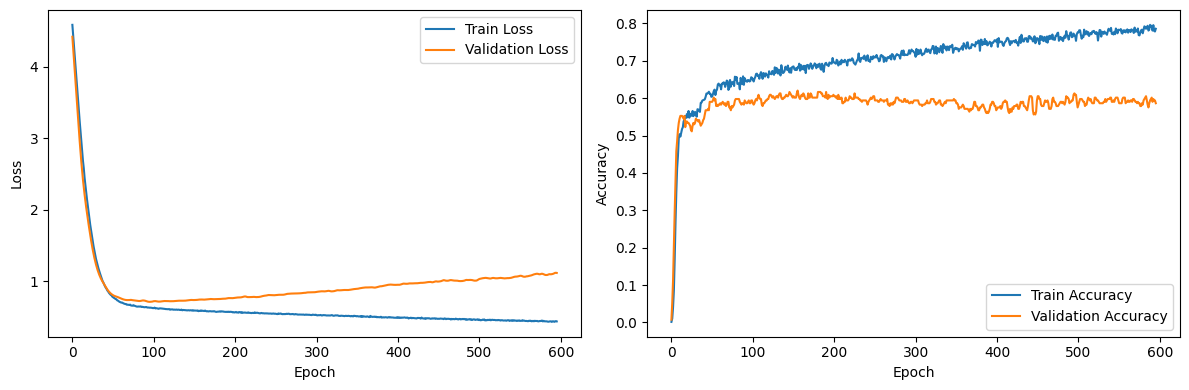


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4227, Val Loss: 3.3040, Train Acc: 0.4555, Val Acc: 0.4392
Epoch: 020, Train Loss: 2.1168, Val Loss: 2.0961, Train Acc: 0.5487, Val Acc: 0.4745
Epoch: 030, Train Loss: 1.3930, Val Loss: 1.4285, Train Acc: 0.5621, Val Acc: 0.4824
Epoch: 040, Train Loss: 1.0325, Val Loss: 1.0800, Train Acc: 0.5847, Val Acc: 0.4784
Epoch: 050, Train Loss: 0.8466, Val Loss: 0.8993, Train Acc: 0.5998, Val Acc: 0.5020
Epoch: 060, Train Loss: 0.7423, Val Loss: 0.8151, Train Acc: 0.6200, Val Acc: 0.5216
Epoch: 070, Train Loss: 0.6874, Val Loss: 0.7854, Train Acc: 0.6468, Val Acc: 0.5216
Epoch: 080, Train Loss: 0.6625, Val Loss: 0.7507, Train Acc: 0.6359, Val Acc: 0.5294
Epoch: 090, Train Loss: 0.6451, Val Loss: 0.7411, Train Acc: 0.6384, Val Acc: 0.5333
Epoch: 100, Train Loss: 0.6155, Val Loss: 0.7421, Train Acc: 0.6594, Val Acc: 0.5333
Epoch: 110, Train Loss: 0.6067, Val Loss: 0.7251, Tr

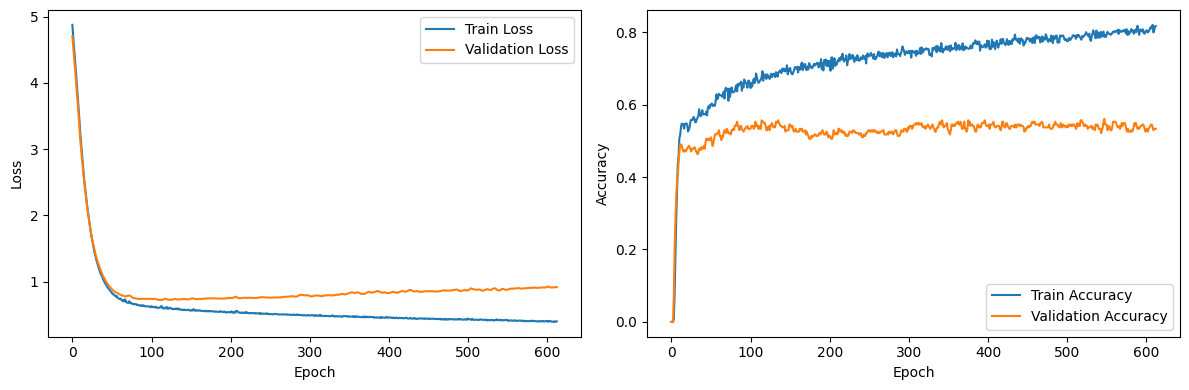


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1076, Val Loss: 2.9923, Train Acc: 0.4982, Val Acc: 0.5169
Epoch: 020, Train Loss: 2.0722, Val Loss: 2.0912, Train Acc: 0.5318, Val Acc: 0.4915
Epoch: 030, Train Loss: 1.3929, Val Loss: 1.4106, Train Acc: 0.5436, Val Acc: 0.5551
Epoch: 040, Train Loss: 1.0317, Val Loss: 1.0780, Train Acc: 0.5653, Val Acc: 0.5381
Epoch: 050, Train Loss: 0.8544, Val Loss: 0.9082, Train Acc: 0.5971, Val Acc: 0.5678
Epoch: 060, Train Loss: 0.7593, Val Loss: 0.8188, Train Acc: 0.6162, Val Acc: 0.5381
Epoch: 070, Train Loss: 0.7105, Val Loss: 0.7752, Train Acc: 0.6234, Val Acc: 0.5424
Epoch: 080, Train Loss: 0.6752, Val Loss: 0.7410, Train Acc: 0.6597, Val Acc: 0.5424
Epoch: 090, Train Loss: 0.6515, Val Loss: 0.7262, Train Acc: 0.6661, Val Acc: 0.5466
Epoch: 100, Train Loss: 0.6416, Val Loss: 0.7203, Train Acc: 0.6633, Val Acc: 0.5551
Epoch: 110, Train Loss: 0.6427, Val Loss: 0.7151, Tr

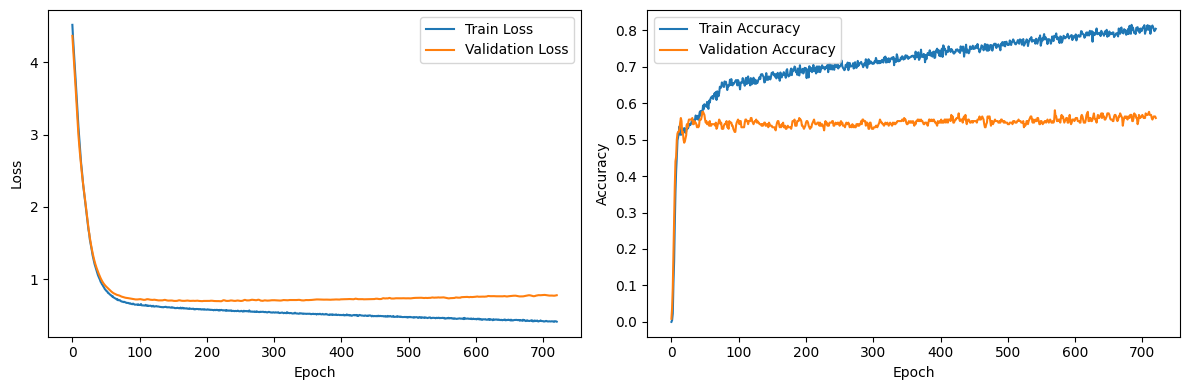


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2459, Val Loss: 3.0410, Train Acc: 0.4606, Val Acc: 0.5092
Epoch: 020, Train Loss: 2.1869, Val Loss: 2.0656, Train Acc: 0.5256, Val Acc: 0.5229
Epoch: 030, Train Loss: 1.5074, Val Loss: 1.4284, Train Acc: 0.5492, Val Acc: 0.5046
Epoch: 040, Train Loss: 1.1323, Val Loss: 1.0866, Train Acc: 0.5837, Val Acc: 0.5413
Epoch: 050, Train Loss: 0.9394, Val Loss: 0.9122, Train Acc: 0.5984, Val Acc: 0.5183
Epoch: 060, Train Loss: 0.8169, Val Loss: 0.8236, Train Acc: 0.5955, Val Acc: 0.5229
Epoch: 070, Train Loss: 0.7268, Val Loss: 0.7713, Train Acc: 0.6289, Val Acc: 0.5275
Epoch: 080, Train Loss: 0.6935, Val Loss: 0.7451, Train Acc: 0.6289, Val Acc: 0.5413
Epoch: 090, Train Loss: 0.6572, Val Loss: 0.7341, Train Acc: 0.6526, Val Acc: 0.5367
Epoch: 100, Train Loss: 0.6432, Val Loss: 0.7272, Train Acc: 0.6467, Val Acc: 0.5367
Epoch: 110, Train Loss: 0.6304, Val Loss: 0.7219, Tr

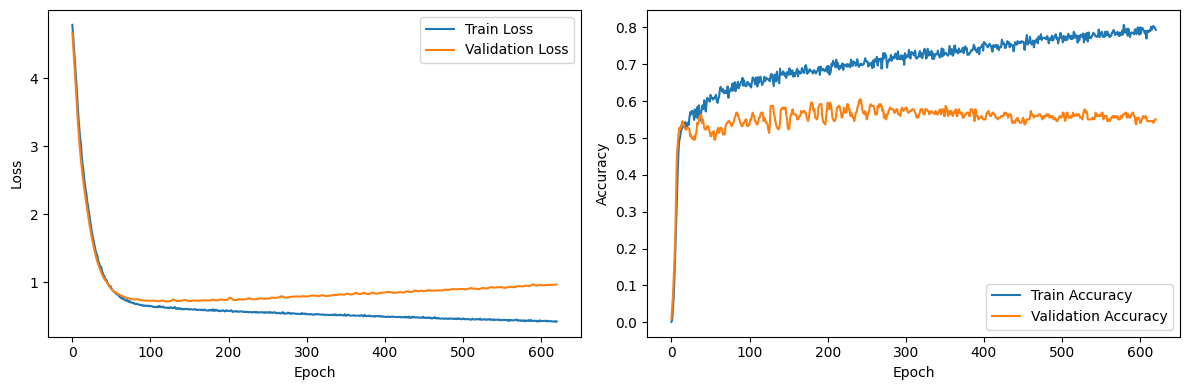


========== Run 12 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2369, Val Loss: 3.0465, Train Acc: 0.4698, Val Acc: 0.4850
Epoch: 020, Train Loss: 2.0864, Val Loss: 1.8991, Train Acc: 0.5375, Val Acc: 0.5338
Epoch: 030, Train Loss: 1.3889, Val Loss: 1.3088, Train Acc: 0.5600, Val Acc: 0.5376
Epoch: 040, Train Loss: 1.0245, Val Loss: 1.0041, Train Acc: 0.5858, Val Acc: 0.5677
Epoch: 050, Train Loss: 0.8510, Val Loss: 0.8788, Train Acc: 0.5979, Val Acc: 0.5677
Epoch: 060, Train Loss: 0.7481, Val Loss: 0.8114, Train Acc: 0.6213, Val Acc: 0.5526
Epoch: 070, Train Loss: 0.7025, Val Loss: 0.7738, Train Acc: 0.6205, Val Acc: 0.5489
Epoch: 080, Train Loss: 0.6736, Val Loss: 0.7590, Train Acc: 0.6132, Val Acc: 0.5714
Epoch: 090, Train Loss: 0.6557, Val Loss: 0.7483, Train Acc: 0.6253, Val Acc: 0.5714
Epoch: 100, Train Loss: 0.6420, Val Loss: 0.7449, Train Acc: 0.6430, Val Acc: 0.5827
Epoch: 110, Train Los

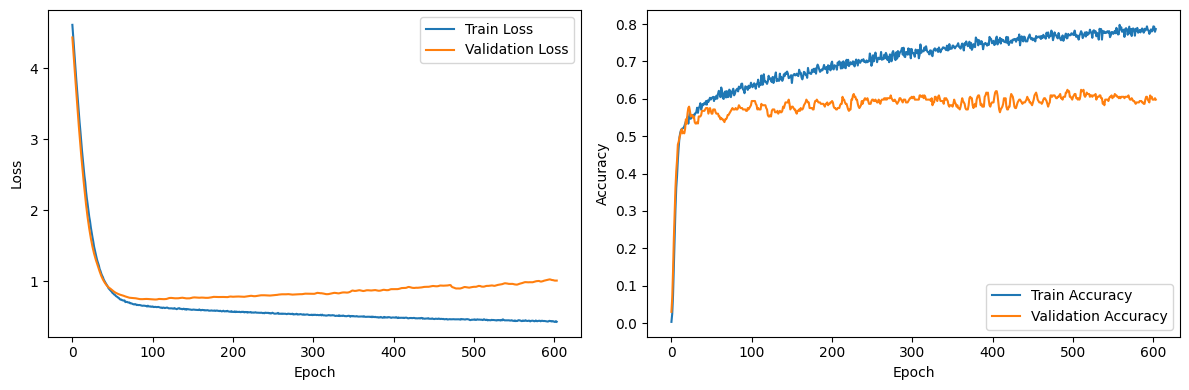


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0678, Val Loss: 2.9945, Train Acc: 0.5159, Val Acc: 0.4980
Epoch: 020, Train Loss: 1.9781, Val Loss: 1.9713, Train Acc: 0.5688, Val Acc: 0.4863
Epoch: 030, Train Loss: 1.3101, Val Loss: 1.3498, Train Acc: 0.5721, Val Acc: 0.4784
Epoch: 040, Train Loss: 0.9876, Val Loss: 1.0263, Train Acc: 0.5940, Val Acc: 0.5059
Epoch: 050, Train Loss: 0.8249, Val Loss: 0.8783, Train Acc: 0.6116, Val Acc: 0.5255
Epoch: 060, Train Loss: 0.7337, Val Loss: 0.8094, Train Acc: 0.6250, Val Acc: 0.5059
Epoch: 070, Train Loss: 0.6833, Val Loss: 0.7715, Train Acc: 0.6300, Val Acc: 0.5216
Epoch: 080, Train Loss: 0.6654, Val Loss: 0.7536, Train Acc: 0.6292, Val Acc: 0.5216
Epoch: 090, Train Loss: 0.6415, Val Loss: 0.7336, Train Acc: 0.6560, Val Acc: 0.5569
Epoch: 100, Train Loss: 0.6305, Val Loss: 0.7400, Train Acc: 0.6611, Val Acc: 0.5176
Epoch: 110, Train Loss: 0.6073, Val Loss: 0.7282, Tr

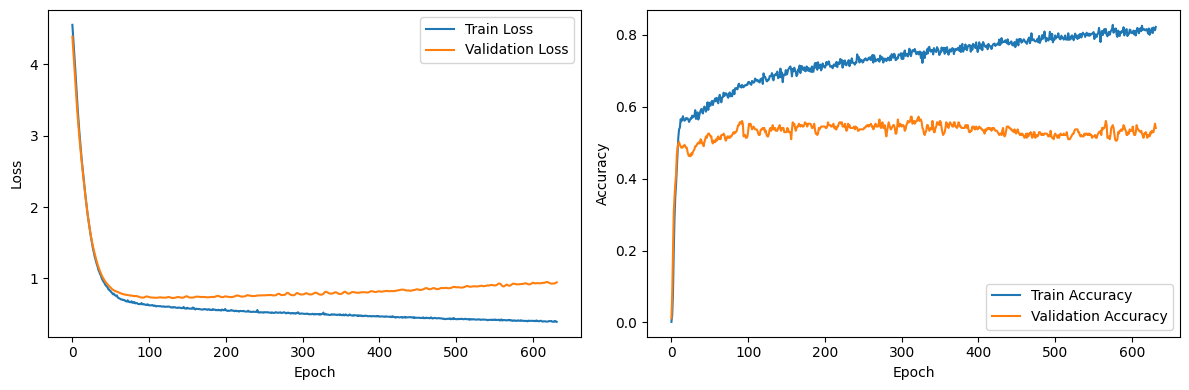


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3927, Val Loss: 3.3270, Train Acc: 0.4501, Val Acc: 0.4619
Epoch: 020, Train Loss: 2.1381, Val Loss: 2.1519, Train Acc: 0.5163, Val Acc: 0.5127
Epoch: 030, Train Loss: 1.4221, Val Loss: 1.4721, Train Acc: 0.5426, Val Acc: 0.5127
Epoch: 040, Train Loss: 1.0460, Val Loss: 1.1213, Train Acc: 0.5835, Val Acc: 0.5169
Epoch: 050, Train Loss: 0.8629, Val Loss: 0.9620, Train Acc: 0.5917, Val Acc: 0.5085
Epoch: 060, Train Loss: 0.7701, Val Loss: 0.8458, Train Acc: 0.6089, Val Acc: 0.5254
Epoch: 070, Train Loss: 0.7193, Val Loss: 0.7967, Train Acc: 0.6289, Val Acc: 0.5127
Epoch: 080, Train Loss: 0.6838, Val Loss: 0.7756, Train Acc: 0.6243, Val Acc: 0.5212
Epoch: 090, Train Loss: 0.6763, Val Loss: 0.7567, Train Acc: 0.6270, Val Acc: 0.5000
Epoch: 100, Train Loss: 0.6508, Val Loss: 0.7453, Train Acc: 0.6443, Val Acc: 0.5085
Epoch: 110, Train Loss: 0.6362, Val Loss: 0.7455, Tr

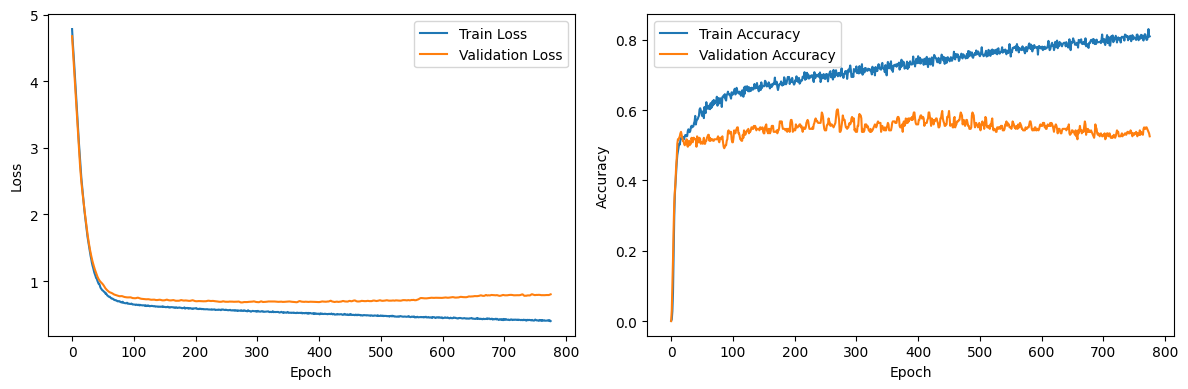


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2334, Val Loss: 3.0226, Train Acc: 0.4577, Val Acc: 0.5183
Epoch: 020, Train Loss: 2.1507, Val Loss: 1.9912, Train Acc: 0.5305, Val Acc: 0.5367
Epoch: 030, Train Loss: 1.4266, Val Loss: 1.3570, Train Acc: 0.5541, Val Acc: 0.5459
Epoch: 040, Train Loss: 1.0573, Val Loss: 1.0321, Train Acc: 0.5679, Val Acc: 0.5183
Epoch: 050, Train Loss: 0.8708, Val Loss: 0.8862, Train Acc: 0.5778, Val Acc: 0.5413
Epoch: 060, Train Loss: 0.7702, Val Loss: 0.8155, Train Acc: 0.5886, Val Acc: 0.5596
Epoch: 070, Train Loss: 0.7105, Val Loss: 0.7763, Train Acc: 0.6014, Val Acc: 0.5505
Epoch: 080, Train Loss: 0.6813, Val Loss: 0.7575, Train Acc: 0.6171, Val Acc: 0.5550
Epoch: 090, Train Loss: 0.6637, Val Loss: 0.7581, Train Acc: 0.6083, Val Acc: 0.5734
Epoch: 100, Train Loss: 0.6446, Val Loss: 0.7536, Train Acc: 0.6289, Val Acc: 0.5826
Epoch: 110, Train Loss: 0.6393, Val Loss: 0.7466, Tr

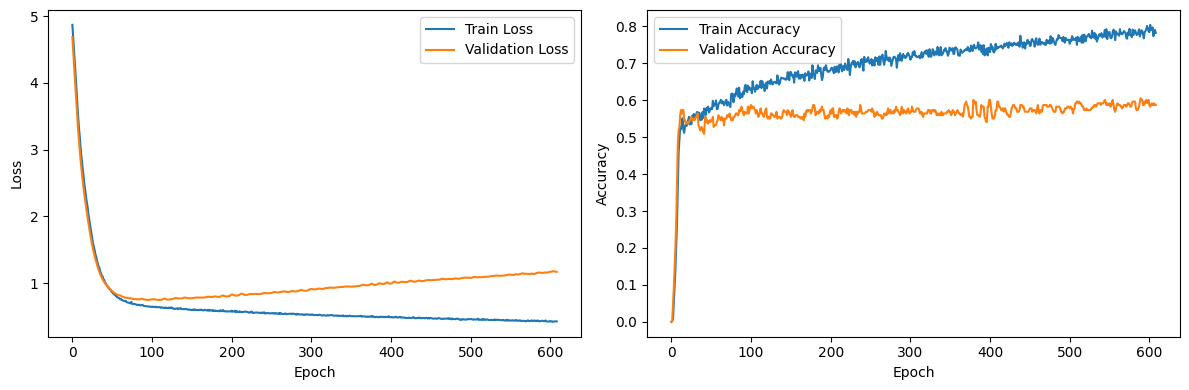


========== Run 13 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1450, Val Loss: 2.9045, Train Acc: 0.4512, Val Acc: 0.4323
Epoch: 020, Train Loss: 1.9794, Val Loss: 1.8186, Train Acc: 0.5294, Val Acc: 0.4699
Epoch: 030, Train Loss: 1.2829, Val Loss: 1.2092, Train Acc: 0.5649, Val Acc: 0.5376
Epoch: 040, Train Loss: 0.9449, Val Loss: 0.9309, Train Acc: 0.5907, Val Acc: 0.5602
Epoch: 050, Train Loss: 0.7875, Val Loss: 0.8012, Train Acc: 0.6156, Val Acc: 0.6015
Epoch: 060, Train Loss: 0.7155, Val Loss: 0.7625, Train Acc: 0.5995, Val Acc: 0.5865
Epoch: 070, Train Loss: 0.6726, Val Loss: 0.7415, Train Acc: 0.6374, Val Acc: 0.5789
Epoch: 080, Train Loss: 0.6542, Val Loss: 0.7292, Train Acc: 0.6390, Val Acc: 0.5865
Epoch: 090, Train Loss: 0.6449, Val Loss: 0.7230, Train Acc: 0.6471, Val Acc: 0.5940
Epoch: 100, Train Loss: 0.6332, Val Loss: 0.7240, Train Acc: 0.6567, Val Acc: 0.5902
Epoch: 110, Train Los

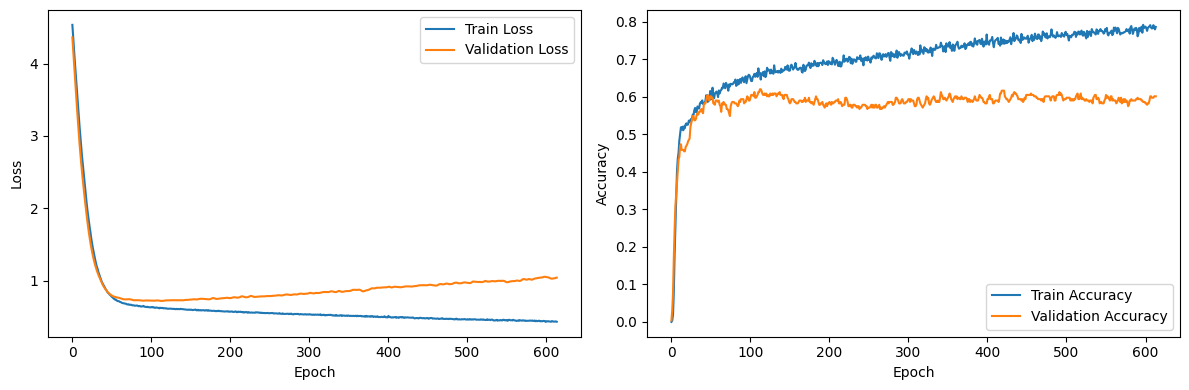


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2138, Val Loss: 3.0781, Train Acc: 0.4757, Val Acc: 0.4980
Epoch: 020, Train Loss: 1.9327, Val Loss: 1.9015, Train Acc: 0.5084, Val Acc: 0.5059
Epoch: 030, Train Loss: 1.3117, Val Loss: 1.2605, Train Acc: 0.5235, Val Acc: 0.5098
Epoch: 040, Train Loss: 0.9850, Val Loss: 0.9833, Train Acc: 0.5738, Val Acc: 0.5137
Epoch: 050, Train Loss: 0.8365, Val Loss: 0.8642, Train Acc: 0.5906, Val Acc: 0.5098
Epoch: 060, Train Loss: 0.7336, Val Loss: 0.7891, Train Acc: 0.6200, Val Acc: 0.5294
Epoch: 070, Train Loss: 0.6831, Val Loss: 0.7471, Train Acc: 0.6401, Val Acc: 0.5333
Epoch: 080, Train Loss: 0.6516, Val Loss: 0.7293, Train Acc: 0.6485, Val Acc: 0.5373
Epoch: 090, Train Loss: 0.6483, Val Loss: 0.7202, Train Acc: 0.6510, Val Acc: 0.5373
Epoch: 100, Train Loss: 0.6185, Val Loss: 0.7066, Train Acc: 0.6510, Val Acc: 0.5529
Epoch: 110, Train Loss: 0.6079, Val Loss: 0.7041, Tr

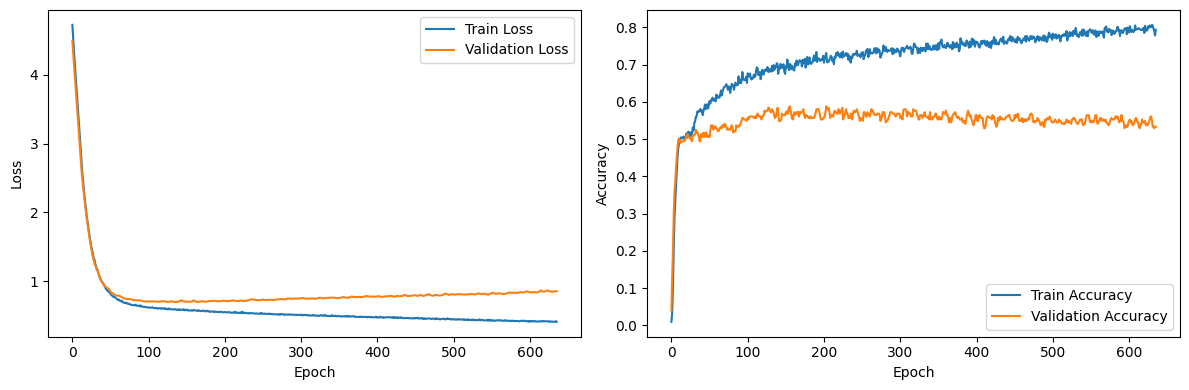


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0785, Val Loss: 2.9773, Train Acc: 0.4855, Val Acc: 0.4873
Epoch: 020, Train Loss: 2.1113, Val Loss: 2.1057, Train Acc: 0.5463, Val Acc: 0.4873
Epoch: 030, Train Loss: 1.4095, Val Loss: 1.4365, Train Acc: 0.5490, Val Acc: 0.4831
Epoch: 040, Train Loss: 1.0354, Val Loss: 1.0774, Train Acc: 0.5735, Val Acc: 0.5085
Epoch: 050, Train Loss: 0.8522, Val Loss: 0.9079, Train Acc: 0.5962, Val Acc: 0.5551
Epoch: 060, Train Loss: 0.7642, Val Loss: 0.8185, Train Acc: 0.6180, Val Acc: 0.5381
Epoch: 070, Train Loss: 0.7093, Val Loss: 0.7614, Train Acc: 0.6216, Val Acc: 0.5593
Epoch: 080, Train Loss: 0.6829, Val Loss: 0.7393, Train Acc: 0.6243, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.6592, Val Loss: 0.7303, Train Acc: 0.6407, Val Acc: 0.5636
Epoch: 100, Train Loss: 0.6566, Val Loss: 0.7207, Train Acc: 0.6216, Val Acc: 0.5678
Epoch: 110, Train Loss: 0.6433, Val Loss: 0.7155, Tr

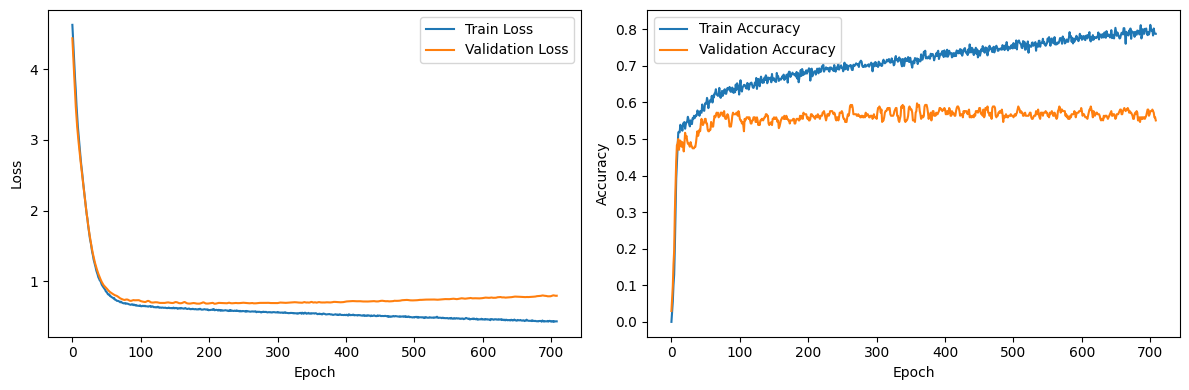


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8415, Val Loss: 2.6793, Train Acc: 0.5177, Val Acc: 0.5229
Epoch: 020, Train Loss: 1.8798, Val Loss: 1.7860, Train Acc: 0.5344, Val Acc: 0.5229
Epoch: 030, Train Loss: 1.2880, Val Loss: 1.2235, Train Acc: 0.5561, Val Acc: 0.5183
Epoch: 040, Train Loss: 0.9555, Val Loss: 0.9533, Train Acc: 0.5719, Val Acc: 0.5275
Epoch: 050, Train Loss: 0.8058, Val Loss: 0.8356, Train Acc: 0.6102, Val Acc: 0.5413
Epoch: 060, Train Loss: 0.7276, Val Loss: 0.7925, Train Acc: 0.6161, Val Acc: 0.5459
Epoch: 070, Train Loss: 0.7014, Val Loss: 0.7773, Train Acc: 0.6063, Val Acc: 0.5550
Epoch: 080, Train Loss: 0.6689, Val Loss: 0.7593, Train Acc: 0.6378, Val Acc: 0.5367
Epoch: 090, Train Loss: 0.6479, Val Loss: 0.7655, Train Acc: 0.6378, Val Acc: 0.5550
Epoch: 100, Train Loss: 0.6360, Val Loss: 0.7639, Train Acc: 0.6565, Val Acc: 0.5596
Epoch: 110, Train Loss: 0.6304, Val Loss: 0.7600, Tr

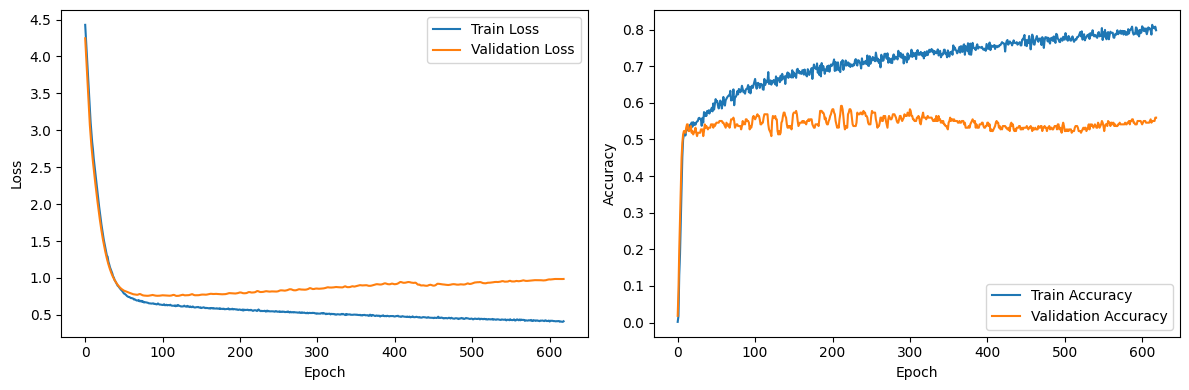


========== Run 14 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2835, Val Loss: 3.0254, Train Acc: 0.4359, Val Acc: 0.5150
Epoch: 020, Train Loss: 2.1188, Val Loss: 1.9753, Train Acc: 0.5246, Val Acc: 0.4887
Epoch: 030, Train Loss: 1.3833, Val Loss: 1.3416, Train Acc: 0.5391, Val Acc: 0.4925
Epoch: 040, Train Loss: 0.9960, Val Loss: 1.0237, Train Acc: 0.5681, Val Acc: 0.5038
Epoch: 050, Train Loss: 0.8070, Val Loss: 0.8806, Train Acc: 0.6068, Val Acc: 0.5263
Epoch: 060, Train Loss: 0.7214, Val Loss: 0.8187, Train Acc: 0.6221, Val Acc: 0.5263
Epoch: 070, Train Loss: 0.6684, Val Loss: 0.7843, Train Acc: 0.6374, Val Acc: 0.5376
Epoch: 080, Train Loss: 0.6562, Val Loss: 0.7651, Train Acc: 0.6358, Val Acc: 0.5677
Epoch: 090, Train Loss: 0.6385, Val Loss: 0.7575, Train Acc: 0.6463, Val Acc: 0.5752
Epoch: 100, Train Loss: 0.6239, Val Loss: 0.7529, Train Acc: 0.6608, Val Acc: 0.5902
Epoch: 110, Train Los

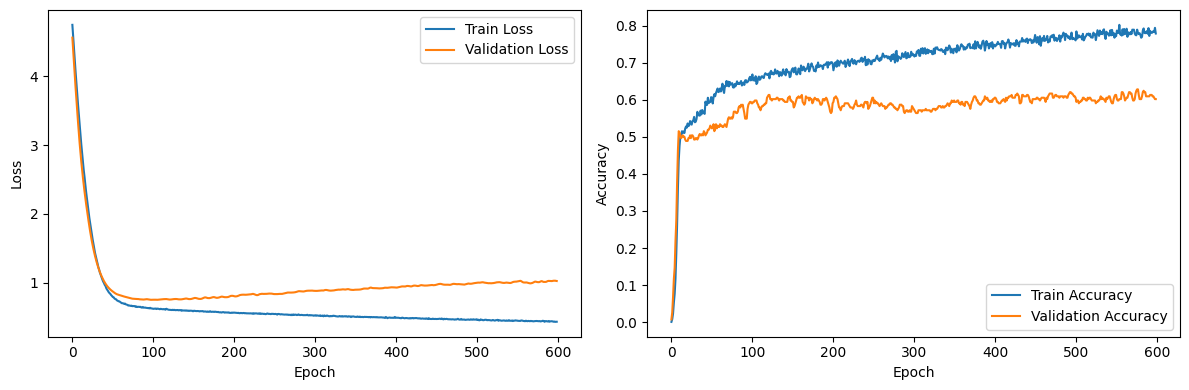


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4467, Val Loss: 3.3029, Train Acc: 0.5000, Val Acc: 0.4980
Epoch: 020, Train Loss: 2.1891, Val Loss: 2.0880, Train Acc: 0.5084, Val Acc: 0.5059
Epoch: 030, Train Loss: 1.4151, Val Loss: 1.4041, Train Acc: 0.5629, Val Acc: 0.4902
Epoch: 040, Train Loss: 1.0388, Val Loss: 1.0521, Train Acc: 0.5696, Val Acc: 0.4902
Epoch: 050, Train Loss: 0.8597, Val Loss: 0.8911, Train Acc: 0.6124, Val Acc: 0.5216
Epoch: 060, Train Loss: 0.7564, Val Loss: 0.8144, Train Acc: 0.6351, Val Acc: 0.5176
Epoch: 070, Train Loss: 0.6901, Val Loss: 0.7638, Train Acc: 0.6535, Val Acc: 0.5451
Epoch: 080, Train Loss: 0.6562, Val Loss: 0.7418, Train Acc: 0.6602, Val Acc: 0.5255
Epoch: 090, Train Loss: 0.6319, Val Loss: 0.7371, Train Acc: 0.6779, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.6205, Val Loss: 0.7320, Train Acc: 0.6753, Val Acc: 0.5294
Epoch: 110, Train Loss: 0.6105, Val Loss: 0.7261, Tr

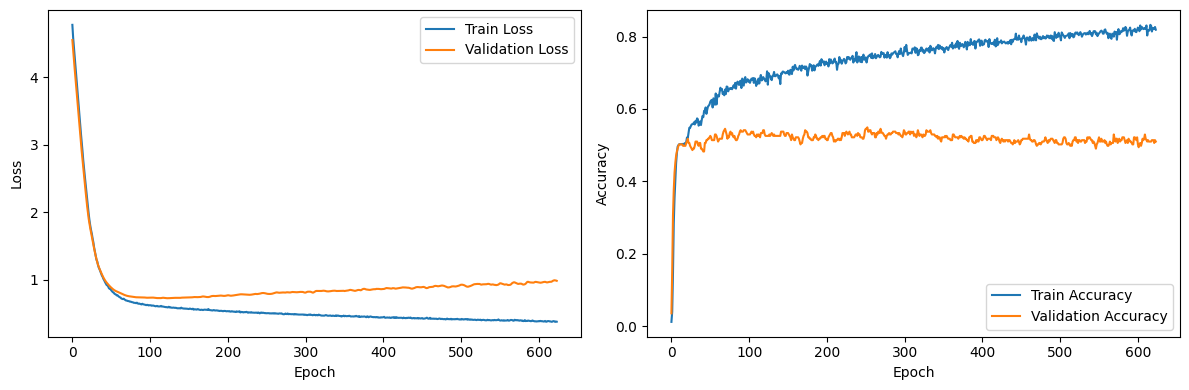


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3078, Val Loss: 3.2055, Train Acc: 0.5363, Val Acc: 0.4788
Epoch: 020, Train Loss: 2.1211, Val Loss: 2.1219, Train Acc: 0.5799, Val Acc: 0.4661
Epoch: 030, Train Loss: 1.3727, Val Loss: 1.4192, Train Acc: 0.5889, Val Acc: 0.4958
Epoch: 040, Train Loss: 0.9925, Val Loss: 1.0559, Train Acc: 0.5971, Val Acc: 0.4703
Epoch: 050, Train Loss: 0.8162, Val Loss: 0.8816, Train Acc: 0.6071, Val Acc: 0.5042
Epoch: 060, Train Loss: 0.7356, Val Loss: 0.8055, Train Acc: 0.6162, Val Acc: 0.5127
Epoch: 070, Train Loss: 0.6956, Val Loss: 0.7581, Train Acc: 0.6225, Val Acc: 0.5466
Epoch: 080, Train Loss: 0.6657, Val Loss: 0.7315, Train Acc: 0.6416, Val Acc: 0.5254
Epoch: 090, Train Loss: 0.6507, Val Loss: 0.7300, Train Acc: 0.6443, Val Acc: 0.5466
Epoch: 100, Train Loss: 0.6411, Val Loss: 0.7298, Train Acc: 0.6461, Val Acc: 0.5636
Epoch: 110, Train Loss: 0.6392, Val Loss: 0.7165, Tr

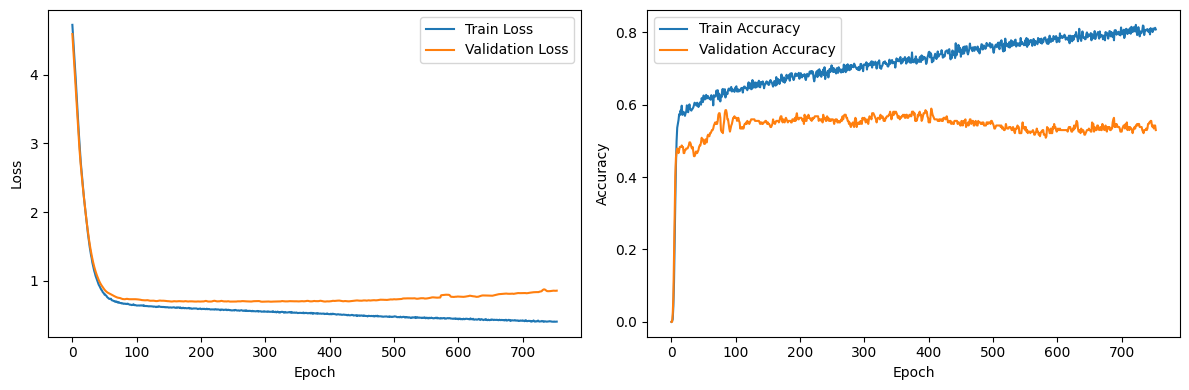


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4971, Val Loss: 3.3128, Train Acc: 0.3888, Val Acc: 0.4037
Epoch: 020, Train Loss: 2.2300, Val Loss: 2.0989, Train Acc: 0.5167, Val Acc: 0.4220
Epoch: 030, Train Loss: 1.4826, Val Loss: 1.4134, Train Acc: 0.5354, Val Acc: 0.4495
Epoch: 040, Train Loss: 1.0855, Val Loss: 1.0527, Train Acc: 0.5679, Val Acc: 0.5092
Epoch: 050, Train Loss: 0.8847, Val Loss: 0.8889, Train Acc: 0.5876, Val Acc: 0.5229
Epoch: 060, Train Loss: 0.7676, Val Loss: 0.8179, Train Acc: 0.6161, Val Acc: 0.5413
Epoch: 070, Train Loss: 0.7084, Val Loss: 0.7744, Train Acc: 0.6250, Val Acc: 0.5459
Epoch: 080, Train Loss: 0.6708, Val Loss: 0.7550, Train Acc: 0.6506, Val Acc: 0.5642
Epoch: 090, Train Loss: 0.6638, Val Loss: 0.7490, Train Acc: 0.6339, Val Acc: 0.5550
Epoch: 100, Train Loss: 0.6408, Val Loss: 0.7470, Train Acc: 0.6575, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.6359, Val Loss: 0.7409, Tr

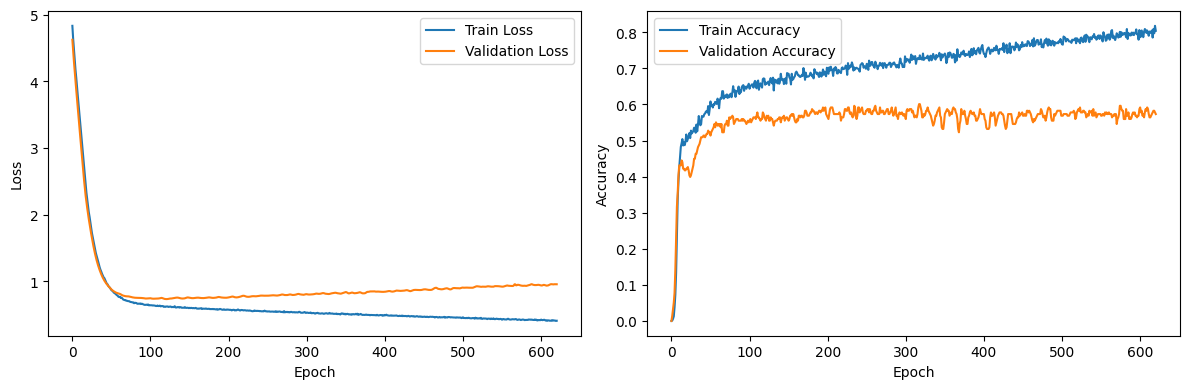


========== Run 15 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2400, Val Loss: 2.9863, Train Acc: 0.3924, Val Acc: 0.4474
Epoch: 020, Train Loss: 2.2236, Val Loss: 2.0346, Train Acc: 0.5101, Val Acc: 0.5150
Epoch: 030, Train Loss: 1.5064, Val Loss: 1.4133, Train Acc: 0.5504, Val Acc: 0.5414
Epoch: 040, Train Loss: 1.0793, Val Loss: 1.0707, Train Acc: 0.5761, Val Acc: 0.5376
Epoch: 050, Train Loss: 0.8640, Val Loss: 0.8892, Train Acc: 0.5842, Val Acc: 0.5526
Epoch: 060, Train Loss: 0.7494, Val Loss: 0.8024, Train Acc: 0.6092, Val Acc: 0.5789
Epoch: 070, Train Loss: 0.6984, Val Loss: 0.7684, Train Acc: 0.6350, Val Acc: 0.5639
Epoch: 080, Train Loss: 0.6659, Val Loss: 0.7562, Train Acc: 0.6422, Val Acc: 0.5714
Epoch: 090, Train Loss: 0.6569, Val Loss: 0.7480, Train Acc: 0.6237, Val Acc: 0.5865
Epoch: 100, Train Loss: 0.6404, Val Loss: 0.7517, Train Acc: 0.6503, Val Acc: 0.5940
Epoch: 110, Train Los

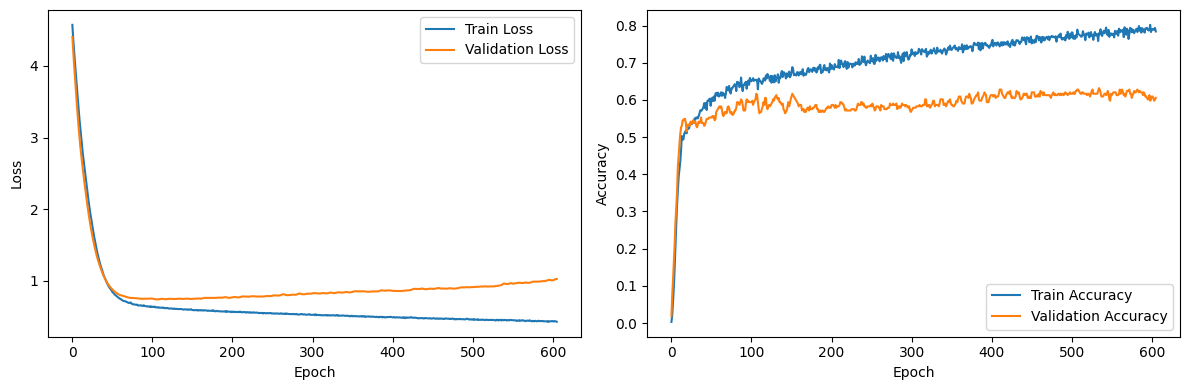


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8434, Val Loss: 2.7772, Train Acc: 0.5159, Val Acc: 0.4824
Epoch: 020, Train Loss: 1.8530, Val Loss: 1.8390, Train Acc: 0.5386, Val Acc: 0.4627
Epoch: 030, Train Loss: 1.2634, Val Loss: 1.2792, Train Acc: 0.5612, Val Acc: 0.4941
Epoch: 040, Train Loss: 0.9740, Val Loss: 0.9995, Train Acc: 0.5914, Val Acc: 0.5137
Epoch: 050, Train Loss: 0.8150, Val Loss: 0.8722, Train Acc: 0.6367, Val Acc: 0.5176
Epoch: 060, Train Loss: 0.7258, Val Loss: 0.8056, Train Acc: 0.6468, Val Acc: 0.5294
Epoch: 070, Train Loss: 0.6766, Val Loss: 0.7749, Train Acc: 0.6535, Val Acc: 0.5255
Epoch: 080, Train Loss: 0.6565, Val Loss: 0.7445, Train Acc: 0.6611, Val Acc: 0.5529
Epoch: 090, Train Loss: 0.6281, Val Loss: 0.7439, Train Acc: 0.6602, Val Acc: 0.5176
Epoch: 100, Train Loss: 0.6161, Val Loss: 0.7402, Train Acc: 0.6594, Val Acc: 0.5216
Epoch: 110, Train Loss: 0.6087, Val Loss: 0.7360, Tr

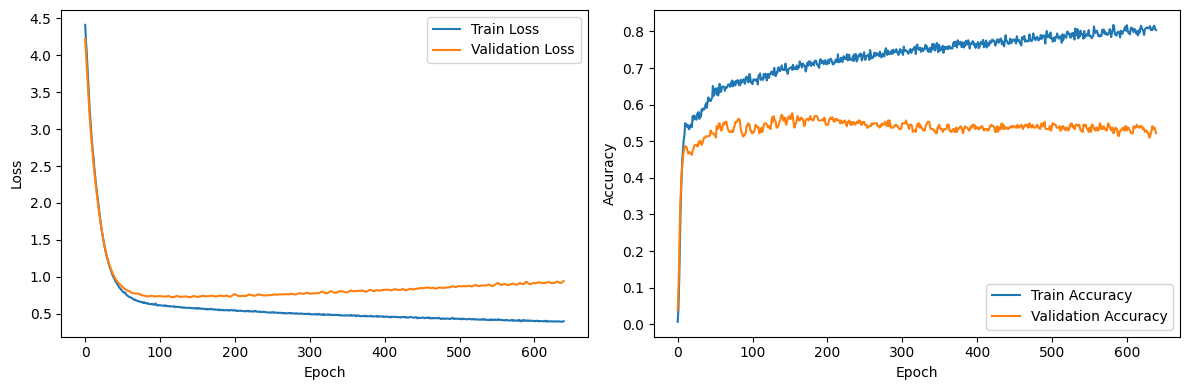


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3237, Val Loss: 3.2145, Train Acc: 0.5372, Val Acc: 0.5508
Epoch: 020, Train Loss: 2.1175, Val Loss: 2.1018, Train Acc: 0.5554, Val Acc: 0.5381
Epoch: 030, Train Loss: 1.4083, Val Loss: 1.4473, Train Acc: 0.5735, Val Acc: 0.5339
Epoch: 040, Train Loss: 1.0400, Val Loss: 1.0804, Train Acc: 0.5989, Val Acc: 0.5508
Epoch: 050, Train Loss: 0.8563, Val Loss: 0.9054, Train Acc: 0.6261, Val Acc: 0.5720
Epoch: 060, Train Loss: 0.7617, Val Loss: 0.8104, Train Acc: 0.6289, Val Acc: 0.5424
Epoch: 070, Train Loss: 0.7130, Val Loss: 0.7724, Train Acc: 0.6225, Val Acc: 0.5847
Epoch: 080, Train Loss: 0.6776, Val Loss: 0.7463, Train Acc: 0.6479, Val Acc: 0.5636
Epoch: 090, Train Loss: 0.6809, Val Loss: 0.7230, Train Acc: 0.6316, Val Acc: 0.5720
Epoch: 100, Train Loss: 0.6417, Val Loss: 0.7091, Train Acc: 0.6615, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6393, Val Loss: 0.6999, Tr

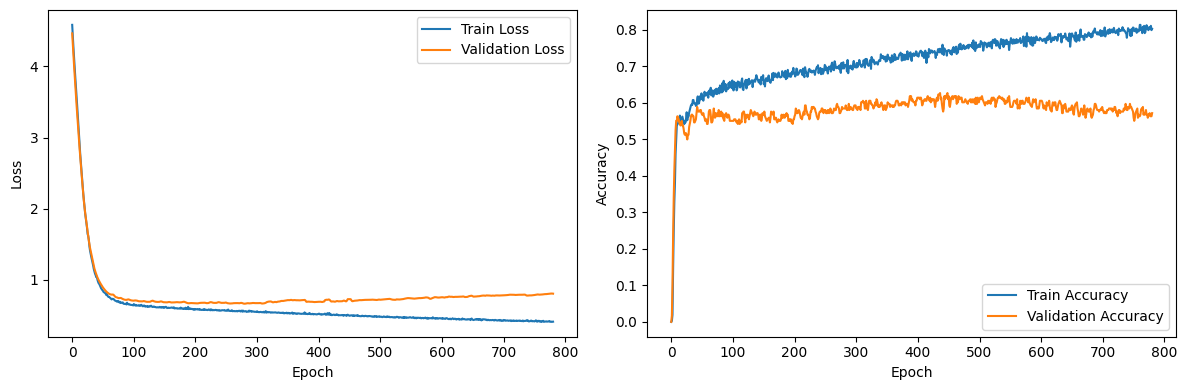


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2421, Val Loss: 3.0878, Train Acc: 0.4793, Val Acc: 0.4862
Epoch: 020, Train Loss: 2.0052, Val Loss: 1.9080, Train Acc: 0.5335, Val Acc: 0.5000
Epoch: 030, Train Loss: 1.3579, Val Loss: 1.3194, Train Acc: 0.5502, Val Acc: 0.4725
Epoch: 040, Train Loss: 1.0570, Val Loss: 1.0396, Train Acc: 0.5689, Val Acc: 0.4908
Epoch: 050, Train Loss: 0.8920, Val Loss: 0.8921, Train Acc: 0.5846, Val Acc: 0.4908
Epoch: 060, Train Loss: 0.7805, Val Loss: 0.8136, Train Acc: 0.6004, Val Acc: 0.5092
Epoch: 070, Train Loss: 0.7258, Val Loss: 0.7700, Train Acc: 0.6014, Val Acc: 0.5183
Epoch: 080, Train Loss: 0.6755, Val Loss: 0.7504, Train Acc: 0.6191, Val Acc: 0.5046
Epoch: 090, Train Loss: 0.6590, Val Loss: 0.7424, Train Acc: 0.6506, Val Acc: 0.5275
Epoch: 100, Train Loss: 0.6456, Val Loss: 0.7386, Train Acc: 0.6299, Val Acc: 0.5367
Epoch: 110, Train Loss: 0.6339, Val Loss: 0.7492, Tr

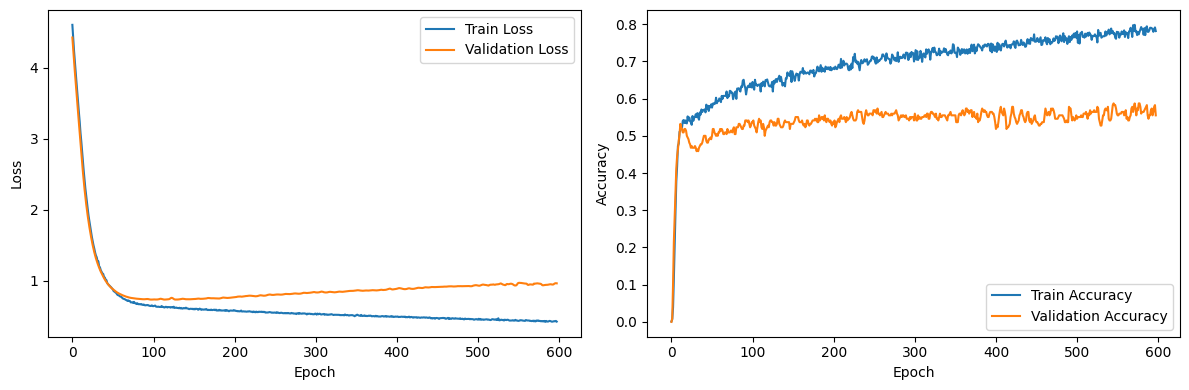


========== Run 16 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2803, Val Loss: 3.0044, Train Acc: 0.5214, Val Acc: 0.5451
Epoch: 020, Train Loss: 2.0788, Val Loss: 1.8783, Train Acc: 0.5770, Val Acc: 0.5714
Epoch: 030, Train Loss: 1.3262, Val Loss: 1.2386, Train Acc: 0.6003, Val Acc: 0.5789
Epoch: 040, Train Loss: 0.9621, Val Loss: 0.9386, Train Acc: 0.6068, Val Acc: 0.5827
Epoch: 050, Train Loss: 0.7962, Val Loss: 0.8105, Train Acc: 0.6116, Val Acc: 0.5827
Epoch: 060, Train Loss: 0.7221, Val Loss: 0.7452, Train Acc: 0.6334, Val Acc: 0.5940
Epoch: 070, Train Loss: 0.6825, Val Loss: 0.7186, Train Acc: 0.6406, Val Acc: 0.5902
Epoch: 080, Train Loss: 0.6620, Val Loss: 0.7088, Train Acc: 0.6454, Val Acc: 0.5977
Epoch: 090, Train Loss: 0.6462, Val Loss: 0.7020, Train Acc: 0.6567, Val Acc: 0.5865
Epoch: 100, Train Loss: 0.6338, Val Loss: 0.7032, Train Acc: 0.6503, Val Acc: 0.5865
Epoch: 110, Train Los

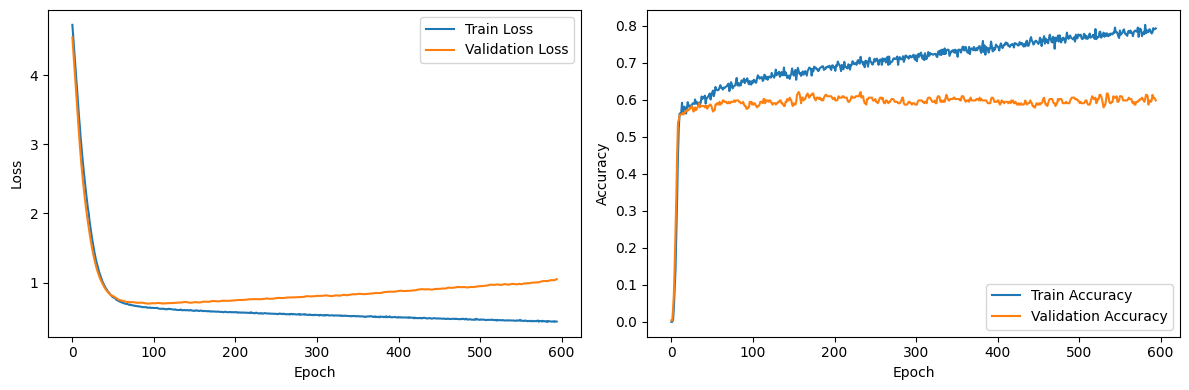


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3190, Val Loss: 3.1743, Train Acc: 0.3876, Val Acc: 0.4706
Epoch: 020, Train Loss: 2.0297, Val Loss: 1.9694, Train Acc: 0.5302, Val Acc: 0.5647
Epoch: 030, Train Loss: 1.3413, Val Loss: 1.3046, Train Acc: 0.5596, Val Acc: 0.5647
Epoch: 040, Train Loss: 0.9957, Val Loss: 0.9977, Train Acc: 0.5730, Val Acc: 0.5569
Epoch: 050, Train Loss: 0.8339, Val Loss: 0.8457, Train Acc: 0.5931, Val Acc: 0.5373
Epoch: 060, Train Loss: 0.7332, Val Loss: 0.7750, Train Acc: 0.6317, Val Acc: 0.5451
Epoch: 070, Train Loss: 0.6803, Val Loss: 0.7457, Train Acc: 0.6460, Val Acc: 0.5451
Epoch: 080, Train Loss: 0.6507, Val Loss: 0.7376, Train Acc: 0.6611, Val Acc: 0.5333
Epoch: 090, Train Loss: 0.6246, Val Loss: 0.7245, Train Acc: 0.6779, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.6159, Val Loss: 0.7235, Train Acc: 0.6779, Val Acc: 0.5451
Epoch: 110, Train Loss: 0.5981, Val Loss: 0.7193, Tr

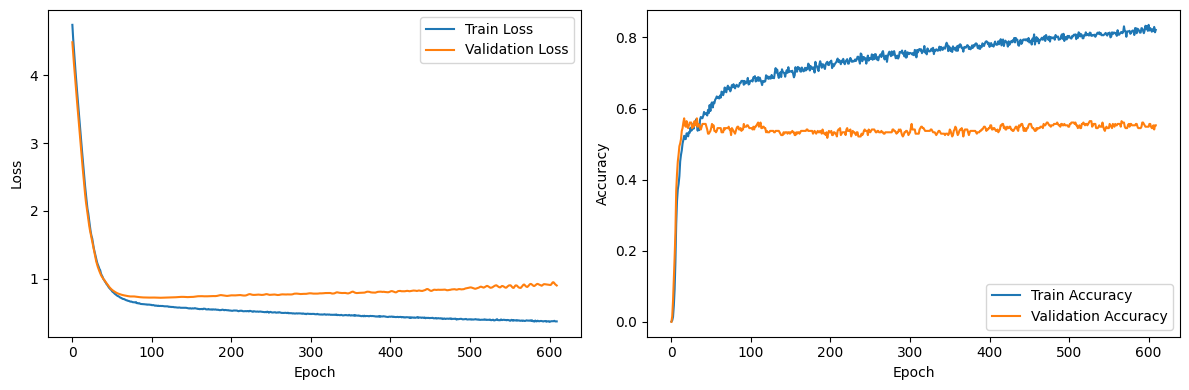


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3104, Val Loss: 3.1982, Train Acc: 0.4891, Val Acc: 0.4788
Epoch: 020, Train Loss: 2.1521, Val Loss: 2.1791, Train Acc: 0.5363, Val Acc: 0.4661
Epoch: 030, Train Loss: 1.4346, Val Loss: 1.4827, Train Acc: 0.5517, Val Acc: 0.4746
Epoch: 040, Train Loss: 1.0498, Val Loss: 1.1170, Train Acc: 0.5871, Val Acc: 0.5042
Epoch: 050, Train Loss: 0.8625, Val Loss: 0.9313, Train Acc: 0.5953, Val Acc: 0.4788
Epoch: 060, Train Loss: 0.7707, Val Loss: 0.8290, Train Acc: 0.6134, Val Acc: 0.5381
Epoch: 070, Train Loss: 0.7149, Val Loss: 0.7766, Train Acc: 0.6243, Val Acc: 0.5381
Epoch: 080, Train Loss: 0.6851, Val Loss: 0.7483, Train Acc: 0.6379, Val Acc: 0.5381
Epoch: 090, Train Loss: 0.6640, Val Loss: 0.7465, Train Acc: 0.6515, Val Acc: 0.5551
Epoch: 100, Train Loss: 0.6485, Val Loss: 0.7327, Train Acc: 0.6606, Val Acc: 0.5551
Epoch: 110, Train Loss: 0.6438, Val Loss: 0.7249, Tr

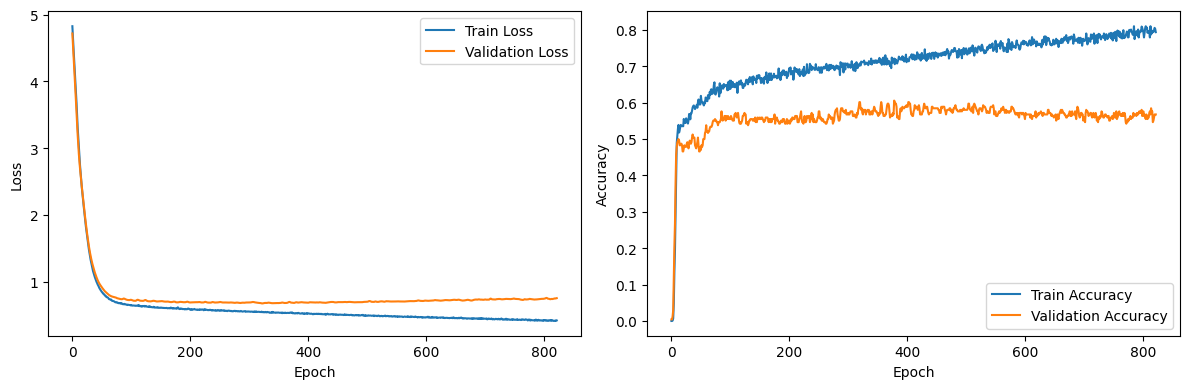


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0203, Val Loss: 2.8344, Train Acc: 0.4902, Val Acc: 0.4908
Epoch: 020, Train Loss: 1.9295, Val Loss: 1.8220, Train Acc: 0.5512, Val Acc: 0.4862
Epoch: 030, Train Loss: 1.2658, Val Loss: 1.2364, Train Acc: 0.5748, Val Acc: 0.5229
Epoch: 040, Train Loss: 0.9651, Val Loss: 0.9764, Train Acc: 0.5679, Val Acc: 0.5229
Epoch: 050, Train Loss: 0.8212, Val Loss: 0.8406, Train Acc: 0.5817, Val Acc: 0.5321
Epoch: 060, Train Loss: 0.7442, Val Loss: 0.7855, Train Acc: 0.5935, Val Acc: 0.5413
Epoch: 070, Train Loss: 0.6961, Val Loss: 0.7473, Train Acc: 0.6043, Val Acc: 0.5413
Epoch: 080, Train Loss: 0.6680, Val Loss: 0.7279, Train Acc: 0.6220, Val Acc: 0.5688
Epoch: 090, Train Loss: 0.6558, Val Loss: 0.7247, Train Acc: 0.6250, Val Acc: 0.5826
Epoch: 100, Train Loss: 0.6372, Val Loss: 0.7191, Train Acc: 0.6506, Val Acc: 0.5826
Epoch: 110, Train Loss: 0.6325, Val Loss: 0.7333, Tr

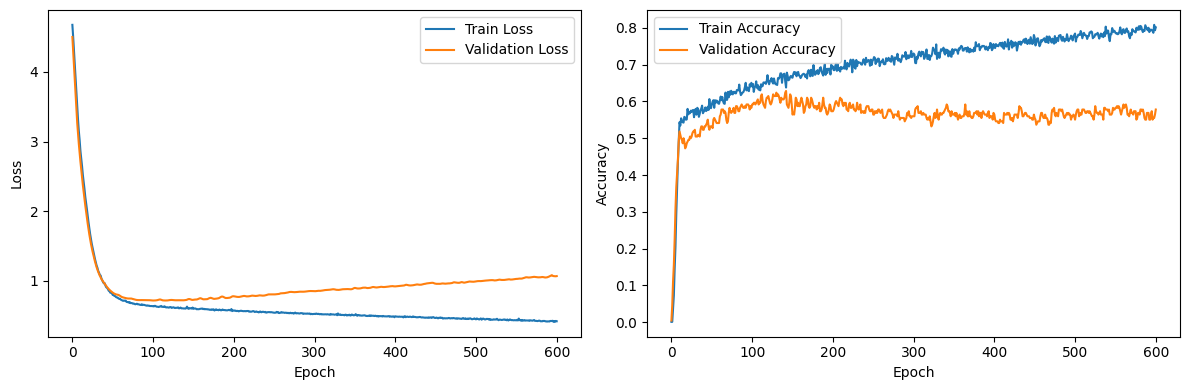


========== Run 17 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0084, Val Loss: 2.7661, Train Acc: 0.5004, Val Acc: 0.5414
Epoch: 020, Train Loss: 1.9429, Val Loss: 1.7740, Train Acc: 0.5197, Val Acc: 0.5414
Epoch: 030, Train Loss: 1.3223, Val Loss: 1.2434, Train Acc: 0.5423, Val Acc: 0.5789
Epoch: 040, Train Loss: 0.9967, Val Loss: 0.9819, Train Acc: 0.5737, Val Acc: 0.5714
Epoch: 050, Train Loss: 0.8135, Val Loss: 0.8511, Train Acc: 0.6011, Val Acc: 0.5602
Epoch: 060, Train Loss: 0.7305, Val Loss: 0.7814, Train Acc: 0.6189, Val Acc: 0.5526
Epoch: 070, Train Loss: 0.6814, Val Loss: 0.7562, Train Acc: 0.6140, Val Acc: 0.5677
Epoch: 080, Train Loss: 0.6597, Val Loss: 0.7415, Train Acc: 0.6358, Val Acc: 0.5752
Epoch: 090, Train Loss: 0.6385, Val Loss: 0.7256, Train Acc: 0.6511, Val Acc: 0.5865
Epoch: 100, Train Loss: 0.6227, Val Loss: 0.7235, Train Acc: 0.6567, Val Acc: 0.5827
Epoch: 110, Train Los

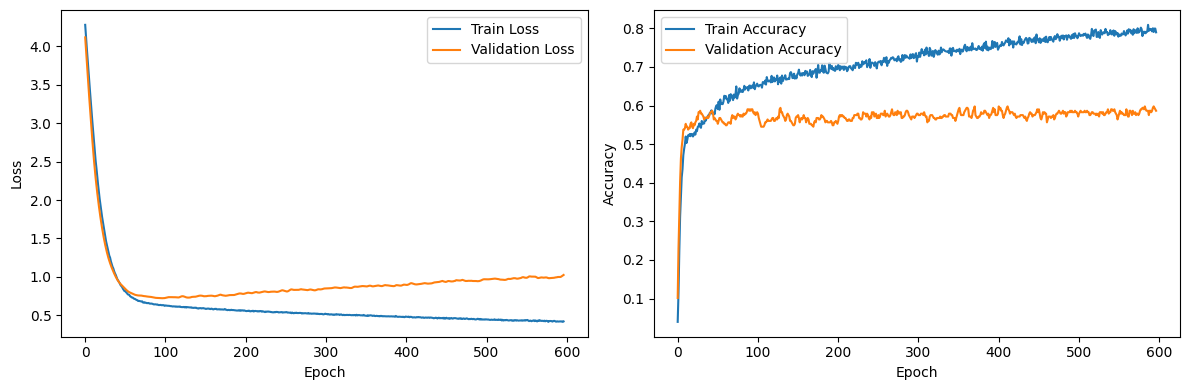


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6559, Val Loss: 3.5208, Train Acc: 0.3154, Val Acc: 0.3843
Epoch: 020, Train Loss: 2.2816, Val Loss: 2.2441, Train Acc: 0.5545, Val Acc: 0.5412
Epoch: 030, Train Loss: 1.4613, Val Loss: 1.4561, Train Acc: 0.5755, Val Acc: 0.5216
Epoch: 040, Train Loss: 1.0514, Val Loss: 1.0605, Train Acc: 0.5982, Val Acc: 0.5529
Epoch: 050, Train Loss: 0.8278, Val Loss: 0.8727, Train Acc: 0.6267, Val Acc: 0.5451
Epoch: 060, Train Loss: 0.7287, Val Loss: 0.7840, Train Acc: 0.6208, Val Acc: 0.5490
Epoch: 070, Train Loss: 0.6784, Val Loss: 0.7482, Train Acc: 0.6460, Val Acc: 0.5529
Epoch: 080, Train Loss: 0.6486, Val Loss: 0.7339, Train Acc: 0.6510, Val Acc: 0.5529
Epoch: 090, Train Loss: 0.6377, Val Loss: 0.7276, Train Acc: 0.6560, Val Acc: 0.5529
Epoch: 100, Train Loss: 0.6215, Val Loss: 0.7274, Train Acc: 0.6594, Val Acc: 0.5451
Epoch: 110, Train Loss: 0.6173, Val Loss: 0.7147, Tr

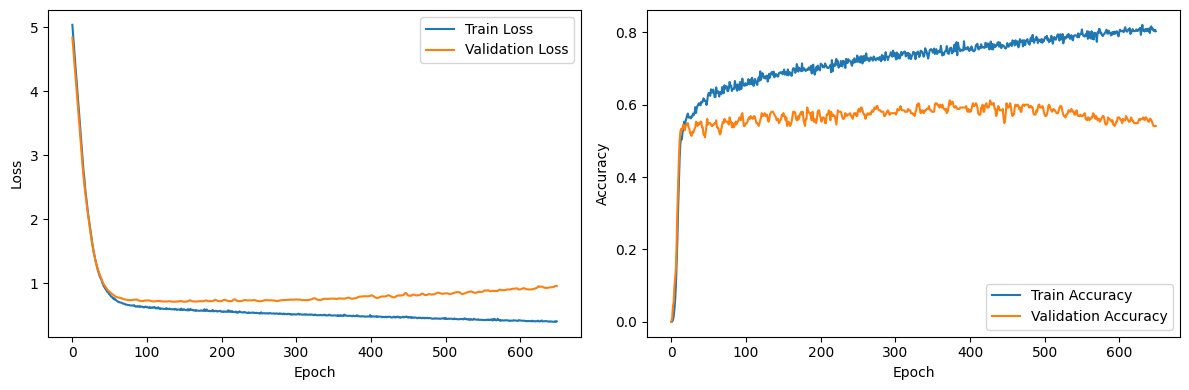


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1461, Val Loss: 3.0139, Train Acc: 0.4946, Val Acc: 0.5127
Epoch: 020, Train Loss: 2.1563, Val Loss: 2.1355, Train Acc: 0.5526, Val Acc: 0.5339
Epoch: 030, Train Loss: 1.4196, Val Loss: 1.4506, Train Acc: 0.5762, Val Acc: 0.5085
Epoch: 040, Train Loss: 1.0279, Val Loss: 1.0892, Train Acc: 0.5907, Val Acc: 0.5424
Epoch: 050, Train Loss: 0.8480, Val Loss: 0.9056, Train Acc: 0.5926, Val Acc: 0.5424
Epoch: 060, Train Loss: 0.7459, Val Loss: 0.8060, Train Acc: 0.6053, Val Acc: 0.5466
Epoch: 070, Train Loss: 0.7014, Val Loss: 0.7559, Train Acc: 0.6116, Val Acc: 0.5339
Epoch: 080, Train Loss: 0.6757, Val Loss: 0.7388, Train Acc: 0.6261, Val Acc: 0.5339
Epoch: 090, Train Loss: 0.6598, Val Loss: 0.7327, Train Acc: 0.6298, Val Acc: 0.5593
Epoch: 100, Train Loss: 0.6412, Val Loss: 0.7138, Train Acc: 0.6434, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6348, Val Loss: 0.7056, Tr

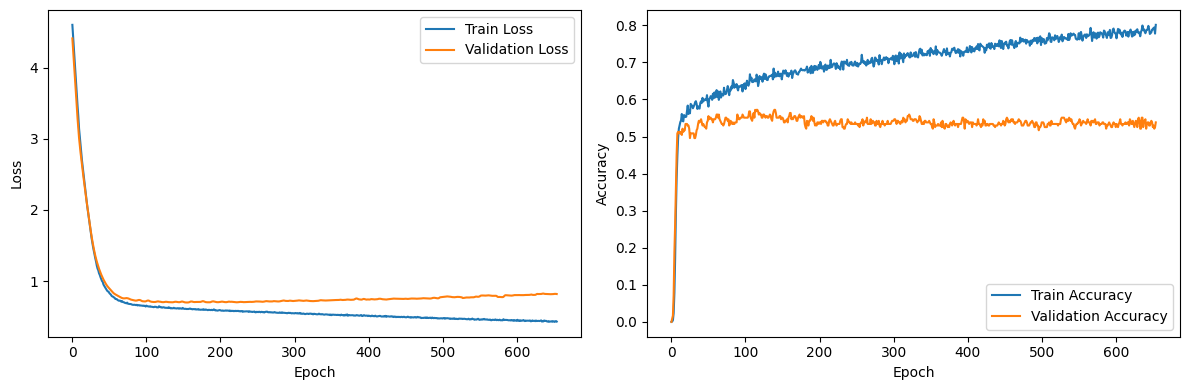


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0567, Val Loss: 2.8912, Train Acc: 0.4272, Val Acc: 0.4312
Epoch: 020, Train Loss: 1.8467, Val Loss: 1.7329, Train Acc: 0.5167, Val Acc: 0.5183
Epoch: 030, Train Loss: 1.2475, Val Loss: 1.1715, Train Acc: 0.5394, Val Acc: 0.5092
Epoch: 040, Train Loss: 0.9763, Val Loss: 0.9285, Train Acc: 0.5512, Val Acc: 0.5596
Epoch: 050, Train Loss: 0.8145, Val Loss: 0.8247, Train Acc: 0.5965, Val Acc: 0.5505
Epoch: 060, Train Loss: 0.7389, Val Loss: 0.7707, Train Acc: 0.6004, Val Acc: 0.5367
Epoch: 070, Train Loss: 0.7036, Val Loss: 0.7409, Train Acc: 0.6270, Val Acc: 0.5413
Epoch: 080, Train Loss: 0.6573, Val Loss: 0.7443, Train Acc: 0.6476, Val Acc: 0.5321
Epoch: 090, Train Loss: 0.6485, Val Loss: 0.7321, Train Acc: 0.6339, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.6397, Val Loss: 0.7249, Train Acc: 0.6339, Val Acc: 0.5596
Epoch: 110, Train Loss: 0.6255, Val Loss: 0.7474, Tr

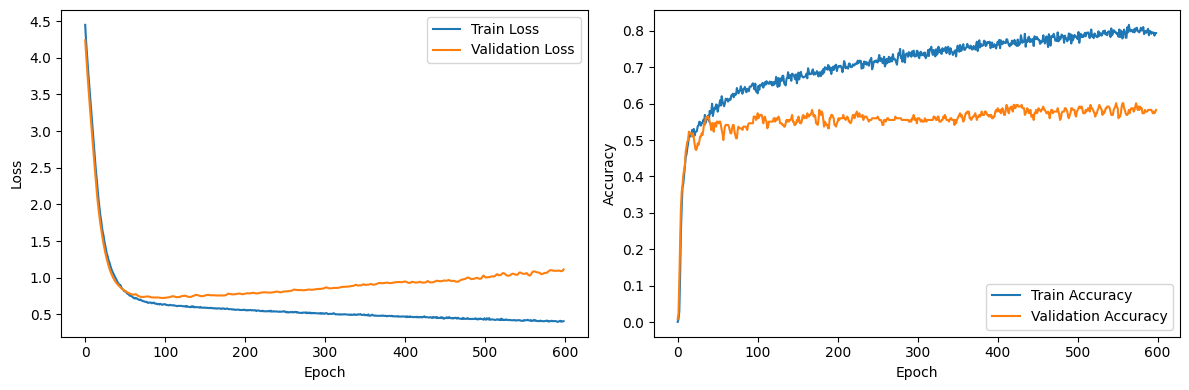


========== Run 18 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5509, Val Loss: 3.3300, Train Acc: 0.4730, Val Acc: 0.4662
Epoch: 020, Train Loss: 2.3474, Val Loss: 2.1170, Train Acc: 0.5326, Val Acc: 0.4887
Epoch: 030, Train Loss: 1.5358, Val Loss: 1.4032, Train Acc: 0.5375, Val Acc: 0.5113
Epoch: 040, Train Loss: 1.0806, Val Loss: 1.0395, Train Acc: 0.5745, Val Acc: 0.5150
Epoch: 050, Train Loss: 0.8449, Val Loss: 0.8694, Train Acc: 0.5947, Val Acc: 0.5263
Epoch: 060, Train Loss: 0.7440, Val Loss: 0.7856, Train Acc: 0.6189, Val Acc: 0.5602
Epoch: 070, Train Loss: 0.6883, Val Loss: 0.7545, Train Acc: 0.6197, Val Acc: 0.5677
Epoch: 080, Train Loss: 0.6575, Val Loss: 0.7304, Train Acc: 0.6398, Val Acc: 0.5940
Epoch: 090, Train Loss: 0.6519, Val Loss: 0.7221, Train Acc: 0.6390, Val Acc: 0.5977
Epoch: 100, Train Loss: 0.6386, Val Loss: 0.7181, Train Acc: 0.6543, Val Acc: 0.5902
Epoch: 110, Train Los

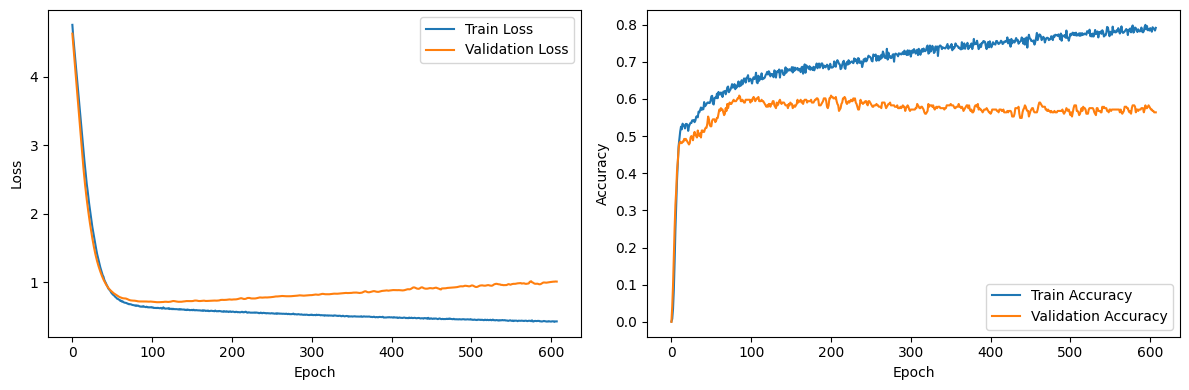


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1533, Val Loss: 3.0586, Train Acc: 0.4497, Val Acc: 0.4706
Epoch: 020, Train Loss: 1.9961, Val Loss: 1.9457, Train Acc: 0.5461, Val Acc: 0.5412
Epoch: 030, Train Loss: 1.3103, Val Loss: 1.2794, Train Acc: 0.5646, Val Acc: 0.5451
Epoch: 040, Train Loss: 0.9632, Val Loss: 0.9783, Train Acc: 0.6116, Val Acc: 0.5490
Epoch: 050, Train Loss: 0.8004, Val Loss: 0.8372, Train Acc: 0.6158, Val Acc: 0.5569
Epoch: 060, Train Loss: 0.7104, Val Loss: 0.7625, Train Acc: 0.6208, Val Acc: 0.5412
Epoch: 070, Train Loss: 0.6719, Val Loss: 0.7330, Train Acc: 0.6376, Val Acc: 0.5529
Epoch: 080, Train Loss: 0.6508, Val Loss: 0.7158, Train Acc: 0.6451, Val Acc: 0.5569
Epoch: 090, Train Loss: 0.6304, Val Loss: 0.7165, Train Acc: 0.6636, Val Acc: 0.5686
Epoch: 100, Train Loss: 0.6104, Val Loss: 0.7063, Train Acc: 0.6678, Val Acc: 0.5765
Epoch: 110, Train Loss: 0.6056, Val Loss: 0.6998, Tr

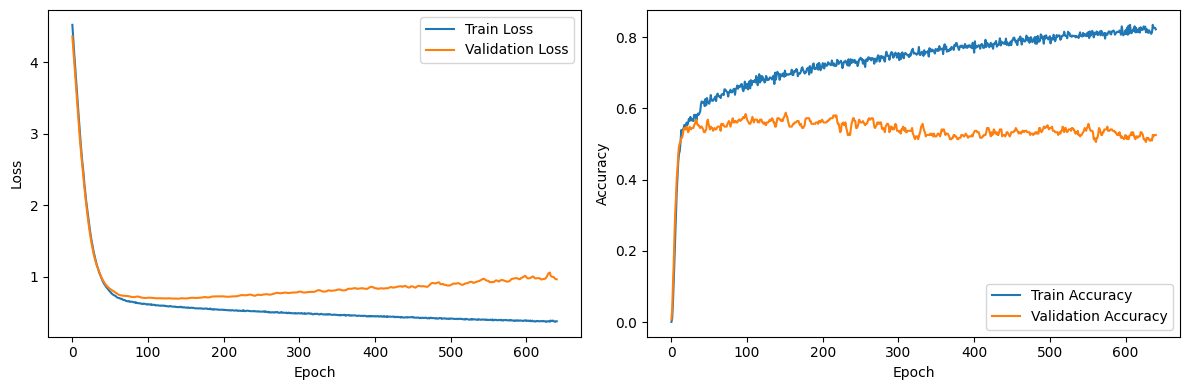


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8025, Val Loss: 2.6891, Train Acc: 0.4419, Val Acc: 0.4915
Epoch: 020, Train Loss: 1.7472, Val Loss: 1.7502, Train Acc: 0.5354, Val Acc: 0.5381
Epoch: 030, Train Loss: 1.1934, Val Loss: 1.2332, Train Acc: 0.5526, Val Acc: 0.4958
Epoch: 040, Train Loss: 0.9186, Val Loss: 0.9867, Train Acc: 0.5817, Val Acc: 0.5381
Epoch: 050, Train Loss: 0.7878, Val Loss: 0.8460, Train Acc: 0.6044, Val Acc: 0.5381
Epoch: 060, Train Loss: 0.7160, Val Loss: 0.7754, Train Acc: 0.6162, Val Acc: 0.5085
Epoch: 070, Train Loss: 0.6817, Val Loss: 0.7494, Train Acc: 0.6334, Val Acc: 0.5085
Epoch: 080, Train Loss: 0.6613, Val Loss: 0.7318, Train Acc: 0.6343, Val Acc: 0.5212
Epoch: 090, Train Loss: 0.6469, Val Loss: 0.7295, Train Acc: 0.6461, Val Acc: 0.5297
Epoch: 100, Train Loss: 0.6377, Val Loss: 0.7189, Train Acc: 0.6497, Val Acc: 0.5169
Epoch: 110, Train Loss: 0.6328, Val Loss: 0.7142, Tr

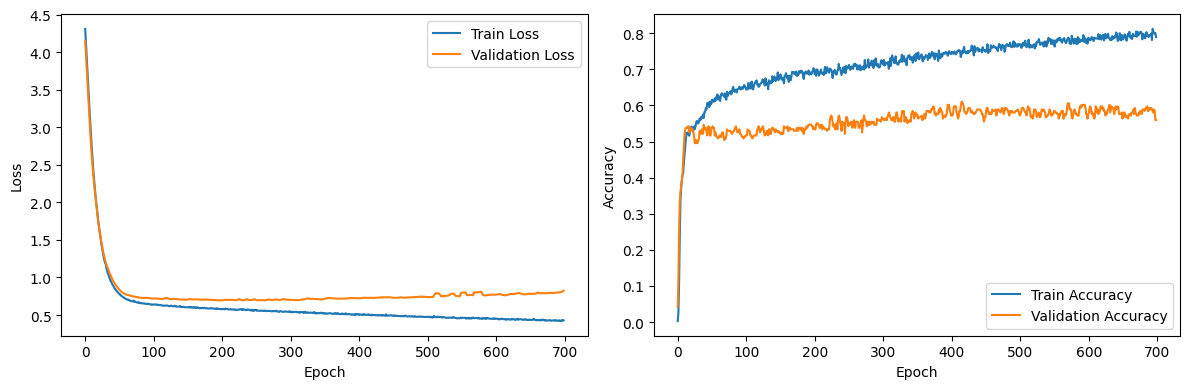


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4785, Val Loss: 3.3657, Train Acc: 0.4006, Val Acc: 0.4679
Epoch: 020, Train Loss: 2.3113, Val Loss: 2.1886, Train Acc: 0.5256, Val Acc: 0.5642
Epoch: 030, Train Loss: 1.5635, Val Loss: 1.4550, Train Acc: 0.5404, Val Acc: 0.5550
Epoch: 040, Train Loss: 1.1222, Val Loss: 1.0715, Train Acc: 0.5669, Val Acc: 0.5596
Epoch: 050, Train Loss: 0.8936, Val Loss: 0.8826, Train Acc: 0.5728, Val Acc: 0.5275
Epoch: 060, Train Loss: 0.7726, Val Loss: 0.7947, Train Acc: 0.6004, Val Acc: 0.5688
Epoch: 070, Train Loss: 0.7126, Val Loss: 0.7447, Train Acc: 0.6004, Val Acc: 0.5596
Epoch: 080, Train Loss: 0.6722, Val Loss: 0.7372, Train Acc: 0.6280, Val Acc: 0.5275
Epoch: 090, Train Loss: 0.6476, Val Loss: 0.7293, Train Acc: 0.6594, Val Acc: 0.5138
Epoch: 100, Train Loss: 0.6346, Val Loss: 0.7263, Train Acc: 0.6427, Val Acc: 0.5092
Epoch: 110, Train Loss: 0.6234, Val Loss: 0.7262, Tr

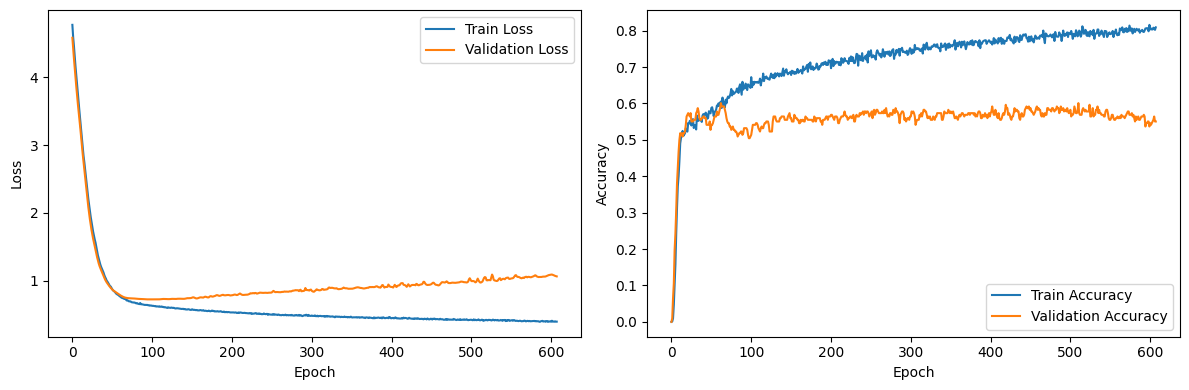


========== Run 19 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1510, Val Loss: 2.9528, Train Acc: 0.4166, Val Acc: 0.4286
Epoch: 020, Train Loss: 1.9810, Val Loss: 1.8109, Train Acc: 0.5246, Val Acc: 0.5075
Epoch: 030, Train Loss: 1.2594, Val Loss: 1.2155, Train Acc: 0.5407, Val Acc: 0.5150
Epoch: 040, Train Loss: 0.9204, Val Loss: 0.9431, Train Acc: 0.5745, Val Acc: 0.5414
Epoch: 050, Train Loss: 0.7645, Val Loss: 0.8309, Train Acc: 0.6124, Val Acc: 0.5451
Epoch: 060, Train Loss: 0.7009, Val Loss: 0.7730, Train Acc: 0.6132, Val Acc: 0.5752
Epoch: 070, Train Loss: 0.6646, Val Loss: 0.7495, Train Acc: 0.6309, Val Acc: 0.5865
Epoch: 080, Train Loss: 0.6494, Val Loss: 0.7507, Train Acc: 0.6269, Val Acc: 0.5714
Epoch: 090, Train Loss: 0.6350, Val Loss: 0.7512, Train Acc: 0.6390, Val Acc: 0.5639
Epoch: 100, Train Loss: 0.6271, Val Loss: 0.7433, Train Acc: 0.6422, Val Acc: 0.5677
Epoch: 110, Train Los

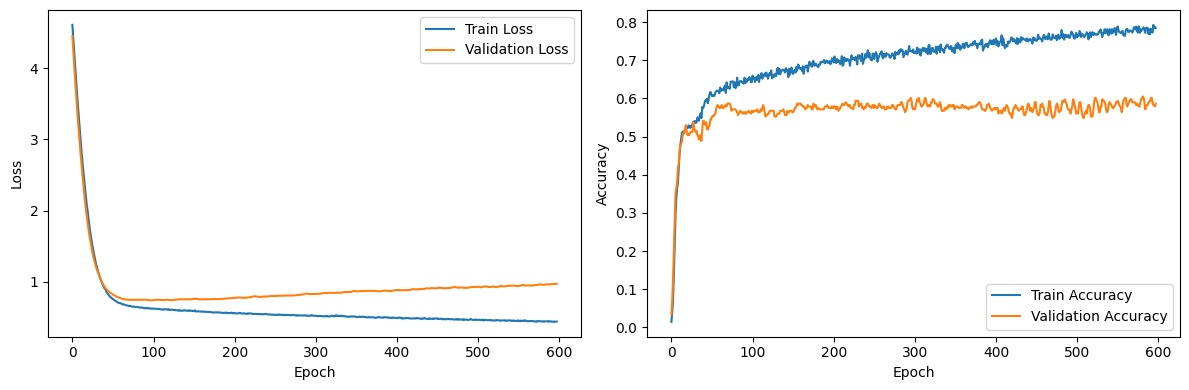


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3798, Val Loss: 3.2939, Train Acc: 0.4413, Val Acc: 0.4235
Epoch: 020, Train Loss: 2.1167, Val Loss: 2.0363, Train Acc: 0.5570, Val Acc: 0.4627
Epoch: 030, Train Loss: 1.3233, Val Loss: 1.3158, Train Acc: 0.5923, Val Acc: 0.4824
Epoch: 040, Train Loss: 0.9925, Val Loss: 1.0187, Train Acc: 0.6099, Val Acc: 0.4980
Epoch: 050, Train Loss: 0.8266, Val Loss: 0.8616, Train Acc: 0.6342, Val Acc: 0.5137
Epoch: 060, Train Loss: 0.7395, Val Loss: 0.7928, Train Acc: 0.6267, Val Acc: 0.5176
Epoch: 070, Train Loss: 0.7008, Val Loss: 0.7675, Train Acc: 0.6342, Val Acc: 0.5294
Epoch: 080, Train Loss: 0.6526, Val Loss: 0.7383, Train Acc: 0.6611, Val Acc: 0.5373
Epoch: 090, Train Loss: 0.6545, Val Loss: 0.7261, Train Acc: 0.6586, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.6248, Val Loss: 0.7258, Train Acc: 0.6669, Val Acc: 0.5412
Epoch: 110, Train Loss: 0.6157, Val Loss: 0.7227, Tr

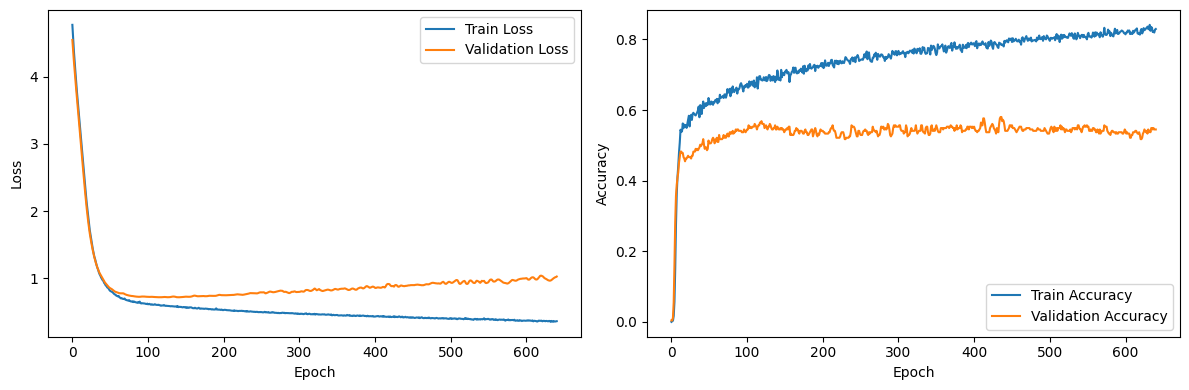


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9875, Val Loss: 2.8869, Train Acc: 0.5163, Val Acc: 0.5042
Epoch: 020, Train Loss: 1.9140, Val Loss: 1.9061, Train Acc: 0.5635, Val Acc: 0.5508
Epoch: 030, Train Loss: 1.2361, Val Loss: 1.2779, Train Acc: 0.5744, Val Acc: 0.5339
Epoch: 040, Train Loss: 0.9282, Val Loss: 0.9879, Train Acc: 0.5898, Val Acc: 0.5085
Epoch: 050, Train Loss: 0.7861, Val Loss: 0.8477, Train Acc: 0.6143, Val Acc: 0.5000
Epoch: 060, Train Loss: 0.7319, Val Loss: 0.7875, Train Acc: 0.6198, Val Acc: 0.5254
Epoch: 070, Train Loss: 0.6812, Val Loss: 0.7478, Train Acc: 0.6361, Val Acc: 0.5466
Epoch: 080, Train Loss: 0.6631, Val Loss: 0.7282, Train Acc: 0.6379, Val Acc: 0.5636
Epoch: 090, Train Loss: 0.6495, Val Loss: 0.7176, Train Acc: 0.6497, Val Acc: 0.5466
Epoch: 100, Train Loss: 0.6404, Val Loss: 0.7230, Train Acc: 0.6470, Val Acc: 0.5466
Epoch: 110, Train Loss: 0.6310, Val Loss: 0.7104, Tr

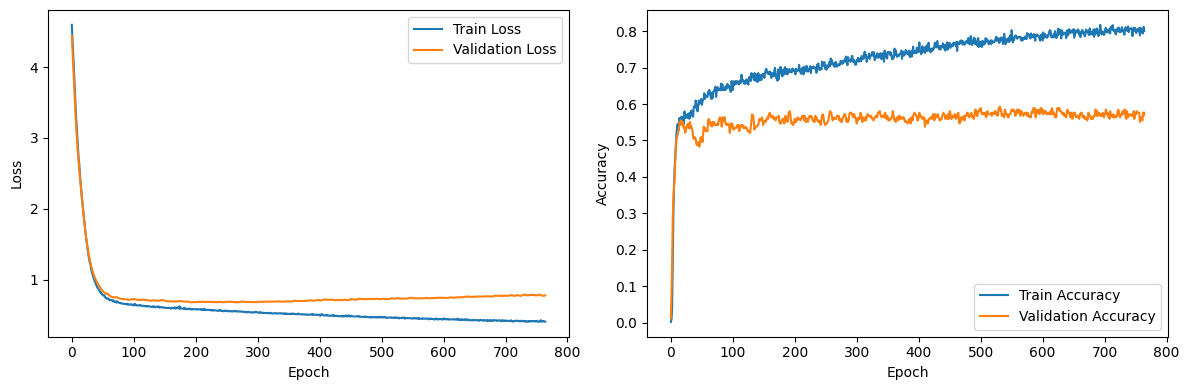


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0718, Val Loss: 2.8922, Train Acc: 0.5256, Val Acc: 0.4771
Epoch: 020, Train Loss: 2.1231, Val Loss: 1.9789, Train Acc: 0.5118, Val Acc: 0.5046
Epoch: 030, Train Loss: 1.4532, Val Loss: 1.3850, Train Acc: 0.5659, Val Acc: 0.4817
Epoch: 040, Train Loss: 1.0791, Val Loss: 1.0484, Train Acc: 0.5827, Val Acc: 0.5092
Epoch: 050, Train Loss: 0.8777, Val Loss: 0.9023, Train Acc: 0.6043, Val Acc: 0.5505
Epoch: 060, Train Loss: 0.7759, Val Loss: 0.8226, Train Acc: 0.6043, Val Acc: 0.5275
Epoch: 070, Train Loss: 0.7220, Val Loss: 0.7769, Train Acc: 0.6122, Val Acc: 0.5505
Epoch: 080, Train Loss: 0.6849, Val Loss: 0.7641, Train Acc: 0.6240, Val Acc: 0.5596
Epoch: 090, Train Loss: 0.6550, Val Loss: 0.7603, Train Acc: 0.6329, Val Acc: 0.5550
Epoch: 100, Train Loss: 0.6470, Val Loss: 0.7448, Train Acc: 0.6417, Val Acc: 0.5459
Epoch: 110, Train Loss: 0.6345, Val Loss: 0.7411, Tr

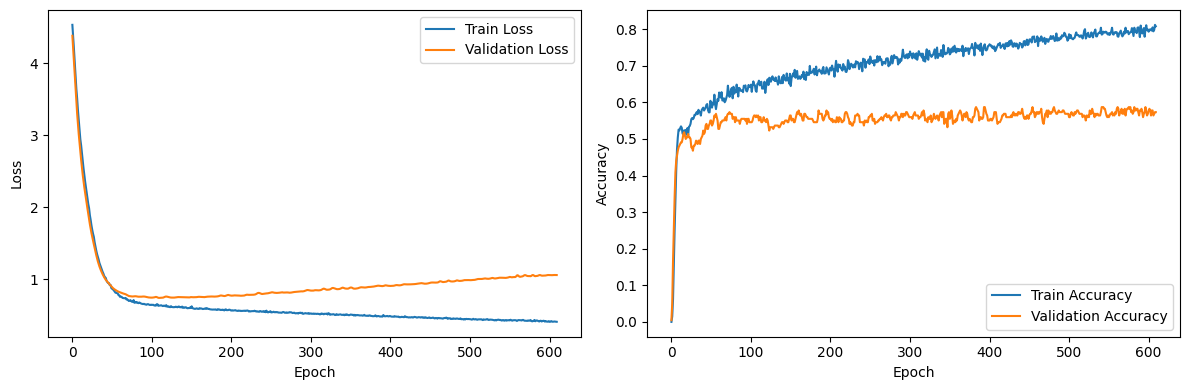


========== Run 20 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3498, Val Loss: 3.1186, Train Acc: 0.3602, Val Acc: 0.3910
Epoch: 020, Train Loss: 2.1779, Val Loss: 2.0072, Train Acc: 0.5036, Val Acc: 0.5000
Epoch: 030, Train Loss: 1.4412, Val Loss: 1.3595, Train Acc: 0.5359, Val Acc: 0.5038
Epoch: 040, Train Loss: 1.0491, Val Loss: 1.0331, Train Acc: 0.5544, Val Acc: 0.5226
Epoch: 050, Train Loss: 0.8599, Val Loss: 0.8848, Train Acc: 0.5745, Val Acc: 0.5451
Epoch: 060, Train Loss: 0.7573, Val Loss: 0.8047, Train Acc: 0.6205, Val Acc: 0.5602
Epoch: 070, Train Loss: 0.7004, Val Loss: 0.7667, Train Acc: 0.6334, Val Acc: 0.5714
Epoch: 080, Train Loss: 0.6721, Val Loss: 0.7551, Train Acc: 0.6374, Val Acc: 0.5489
Epoch: 090, Train Loss: 0.6513, Val Loss: 0.7389, Train Acc: 0.6422, Val Acc: 0.5677
Epoch: 100, Train Loss: 0.6384, Val Loss: 0.7348, Train Acc: 0.6454, Val Acc: 0.5639
Epoch: 110, Train Los

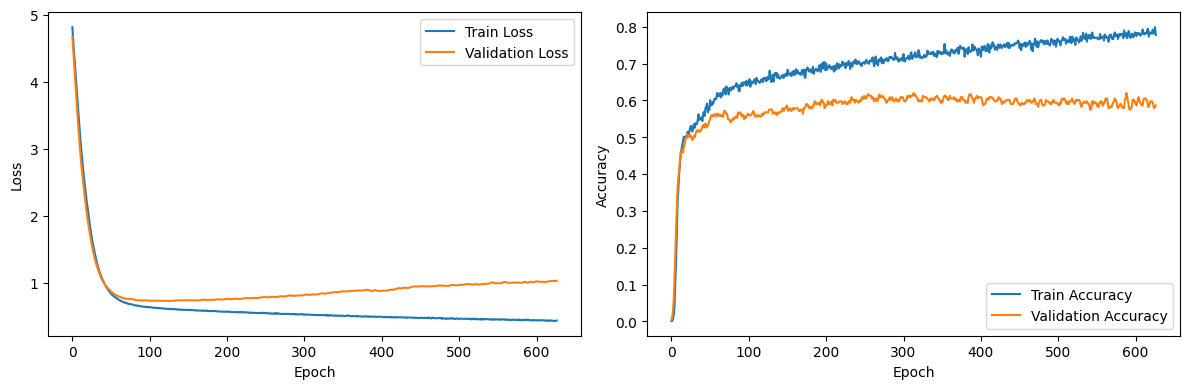


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1351, Val Loss: 3.0311, Train Acc: 0.4388, Val Acc: 0.4980
Epoch: 020, Train Loss: 2.1359, Val Loss: 2.0778, Train Acc: 0.5470, Val Acc: 0.5255
Epoch: 030, Train Loss: 1.4360, Val Loss: 1.4170, Train Acc: 0.5805, Val Acc: 0.5333
Epoch: 040, Train Loss: 1.0586, Val Loss: 1.0801, Train Acc: 0.5898, Val Acc: 0.5255
Epoch: 050, Train Loss: 0.8633, Val Loss: 0.9046, Train Acc: 0.6284, Val Acc: 0.5137
Epoch: 060, Train Loss: 0.7579, Val Loss: 0.8091, Train Acc: 0.6309, Val Acc: 0.5020
Epoch: 070, Train Loss: 0.6945, Val Loss: 0.7706, Train Acc: 0.6552, Val Acc: 0.5137
Epoch: 080, Train Loss: 0.6587, Val Loss: 0.7428, Train Acc: 0.6560, Val Acc: 0.5608
Epoch: 090, Train Loss: 0.6605, Val Loss: 0.7273, Train Acc: 0.6502, Val Acc: 0.5333
Epoch: 100, Train Loss: 0.6286, Val Loss: 0.7173, Train Acc: 0.6779, Val Acc: 0.5451
Epoch: 110, Train Loss: 0.6117, Val Loss: 0.7209, Tr

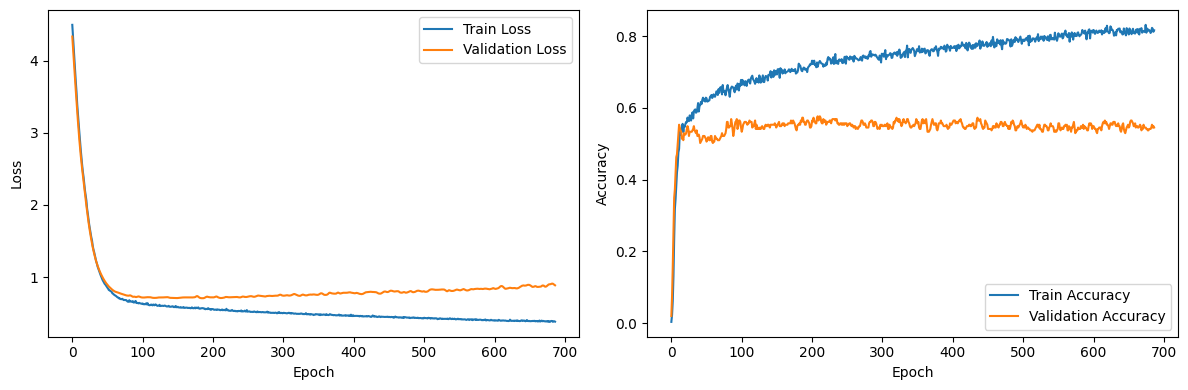


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4104, Val Loss: 3.2459, Train Acc: 0.3339, Val Acc: 0.3941
Epoch: 020, Train Loss: 2.2969, Val Loss: 2.2499, Train Acc: 0.5154, Val Acc: 0.5763
Epoch: 030, Train Loss: 1.5179, Val Loss: 1.5321, Train Acc: 0.5590, Val Acc: 0.5763
Epoch: 040, Train Loss: 1.0904, Val Loss: 1.1215, Train Acc: 0.5789, Val Acc: 0.5551
Epoch: 050, Train Loss: 0.8722, Val Loss: 0.9276, Train Acc: 0.6007, Val Acc: 0.5678
Epoch: 060, Train Loss: 0.7705, Val Loss: 0.8249, Train Acc: 0.6062, Val Acc: 0.5297
Epoch: 070, Train Loss: 0.7456, Val Loss: 0.7692, Train Acc: 0.6325, Val Acc: 0.5339
Epoch: 080, Train Loss: 0.6831, Val Loss: 0.7517, Train Acc: 0.6416, Val Acc: 0.5381
Epoch: 090, Train Loss: 0.6606, Val Loss: 0.7345, Train Acc: 0.6407, Val Acc: 0.5466
Epoch: 100, Train Loss: 0.6475, Val Loss: 0.7368, Train Acc: 0.6552, Val Acc: 0.5424
Epoch: 110, Train Loss: 0.6401, Val Loss: 0.7186, Tr

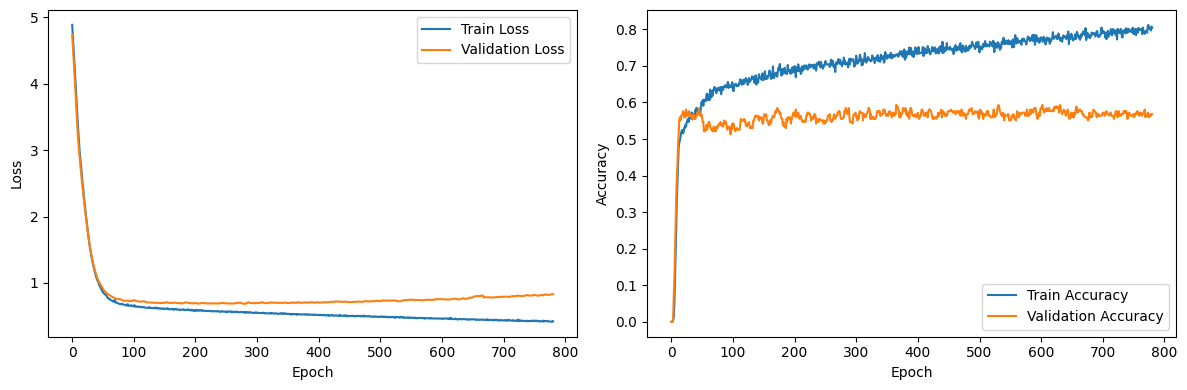


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3427, Val Loss: 3.1404, Train Acc: 0.4242, Val Acc: 0.4679
Epoch: 020, Train Loss: 1.9545, Val Loss: 1.8132, Train Acc: 0.5384, Val Acc: 0.5183
Epoch: 030, Train Loss: 1.2691, Val Loss: 1.1923, Train Acc: 0.5650, Val Acc: 0.5321
Epoch: 040, Train Loss: 0.9671, Val Loss: 0.9227, Train Acc: 0.5758, Val Acc: 0.5550
Epoch: 050, Train Loss: 0.8231, Val Loss: 0.8181, Train Acc: 0.5945, Val Acc: 0.5734
Epoch: 060, Train Loss: 0.7403, Val Loss: 0.7643, Train Acc: 0.6112, Val Acc: 0.5688
Epoch: 070, Train Loss: 0.6957, Val Loss: 0.7356, Train Acc: 0.6230, Val Acc: 0.5642
Epoch: 080, Train Loss: 0.6751, Val Loss: 0.7191, Train Acc: 0.6181, Val Acc: 0.5642
Epoch: 090, Train Loss: 0.6543, Val Loss: 0.7123, Train Acc: 0.6280, Val Acc: 0.5780
Epoch: 100, Train Loss: 0.6401, Val Loss: 0.7168, Train Acc: 0.6388, Val Acc: 0.5642
Epoch: 110, Train Loss: 0.6256, Val Loss: 0.7083, Tr

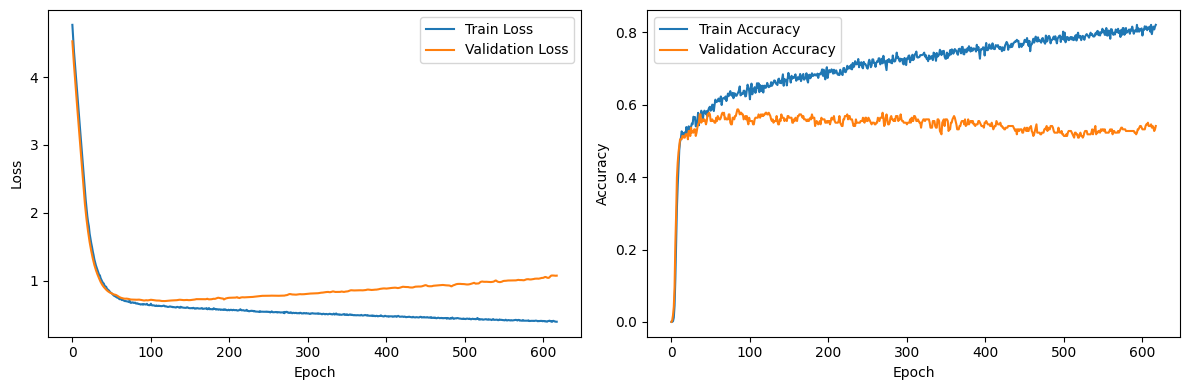


========== Run 21 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9906, Val Loss: 2.6971, Train Acc: 0.4730, Val Acc: 0.4925
Epoch: 020, Train Loss: 1.9747, Val Loss: 1.8159, Train Acc: 0.5367, Val Acc: 0.4737
Epoch: 030, Train Loss: 1.3595, Val Loss: 1.2746, Train Acc: 0.5504, Val Acc: 0.5113
Epoch: 040, Train Loss: 1.0218, Val Loss: 1.0070, Train Acc: 0.5842, Val Acc: 0.5301
Epoch: 050, Train Loss: 0.8514, Val Loss: 0.8672, Train Acc: 0.6027, Val Acc: 0.5714
Epoch: 060, Train Loss: 0.7602, Val Loss: 0.7870, Train Acc: 0.6180, Val Acc: 0.5902
Epoch: 070, Train Loss: 0.7044, Val Loss: 0.7494, Train Acc: 0.6366, Val Acc: 0.6015
Epoch: 080, Train Loss: 0.6750, Val Loss: 0.7330, Train Acc: 0.6406, Val Acc: 0.6053
Epoch: 090, Train Loss: 0.6573, Val Loss: 0.7223, Train Acc: 0.6398, Val Acc: 0.6090
Epoch: 100, Train Loss: 0.6368, Val Loss: 0.7209, Train Acc: 0.6511, Val Acc: 0.6090
Epoch: 110, Train Los

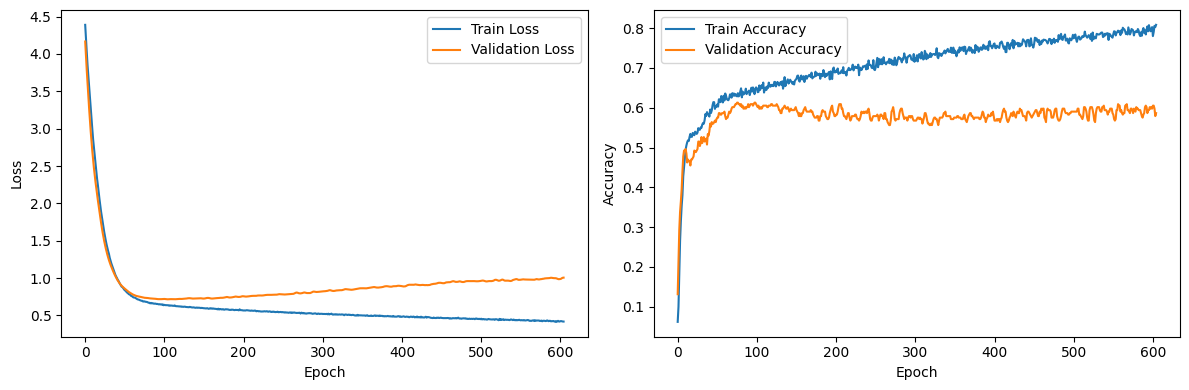


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0196, Val Loss: 2.9507, Train Acc: 0.4908, Val Acc: 0.4902
Epoch: 020, Train Loss: 2.0053, Val Loss: 1.9759, Train Acc: 0.5529, Val Acc: 0.5020
Epoch: 030, Train Loss: 1.3538, Val Loss: 1.3442, Train Acc: 0.5696, Val Acc: 0.5059
Epoch: 040, Train Loss: 1.0176, Val Loss: 1.0348, Train Acc: 0.6015, Val Acc: 0.5294
Epoch: 050, Train Loss: 0.8595, Val Loss: 0.8833, Train Acc: 0.6057, Val Acc: 0.5333
Epoch: 060, Train Loss: 0.7606, Val Loss: 0.8048, Train Acc: 0.6275, Val Acc: 0.5412
Epoch: 070, Train Loss: 0.7120, Val Loss: 0.7721, Train Acc: 0.6275, Val Acc: 0.5373
Epoch: 080, Train Loss: 0.7040, Val Loss: 0.7420, Train Acc: 0.6409, Val Acc: 0.5412
Epoch: 090, Train Loss: 0.6445, Val Loss: 0.7239, Train Acc: 0.6653, Val Acc: 0.5608
Epoch: 100, Train Loss: 0.6313, Val Loss: 0.7148, Train Acc: 0.6619, Val Acc: 0.5608
Epoch: 110, Train Loss: 0.6186, Val Loss: 0.7138, Tr

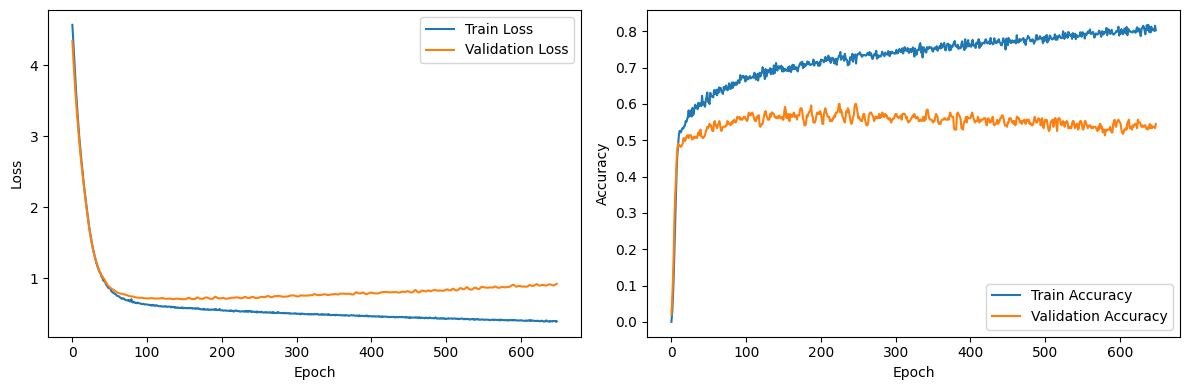


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3746, Val Loss: 3.2356, Train Acc: 0.3004, Val Acc: 0.3347
Epoch: 020, Train Loss: 2.2078, Val Loss: 2.1693, Train Acc: 0.5499, Val Acc: 0.5678
Epoch: 030, Train Loss: 1.4143, Val Loss: 1.4380, Train Acc: 0.5626, Val Acc: 0.5042
Epoch: 040, Train Loss: 1.0000, Val Loss: 1.0673, Train Acc: 0.5753, Val Acc: 0.5169
Epoch: 050, Train Loss: 0.8177, Val Loss: 0.8872, Train Acc: 0.5998, Val Acc: 0.5169
Epoch: 060, Train Loss: 0.7320, Val Loss: 0.7974, Train Acc: 0.6216, Val Acc: 0.5297
Epoch: 070, Train Loss: 0.6873, Val Loss: 0.7517, Train Acc: 0.6234, Val Acc: 0.5424
Epoch: 080, Train Loss: 0.6690, Val Loss: 0.7410, Train Acc: 0.6216, Val Acc: 0.5381
Epoch: 090, Train Loss: 0.6543, Val Loss: 0.7402, Train Acc: 0.6298, Val Acc: 0.5424
Epoch: 100, Train Loss: 0.6399, Val Loss: 0.7163, Train Acc: 0.6379, Val Acc: 0.5254
Epoch: 110, Train Loss: 0.6289, Val Loss: 0.7124, Tr

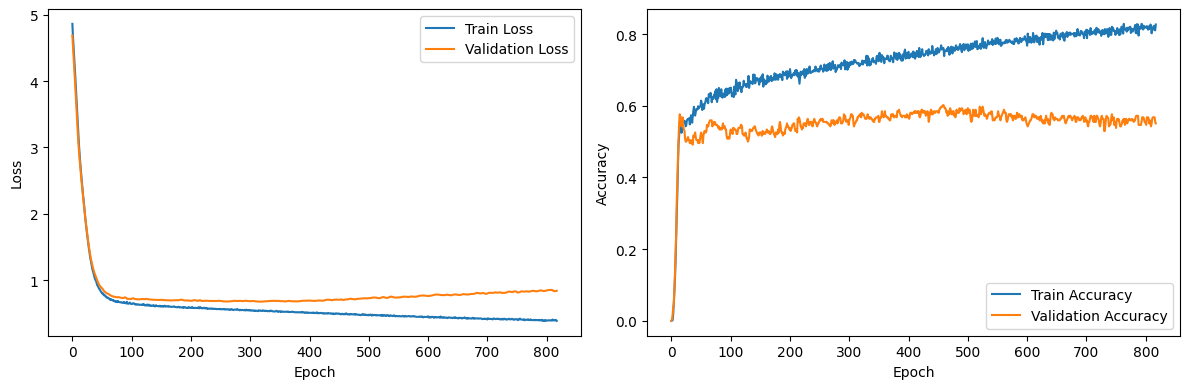


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1613, Val Loss: 2.9488, Train Acc: 0.4833, Val Acc: 0.5550
Epoch: 020, Train Loss: 1.9491, Val Loss: 1.8023, Train Acc: 0.5138, Val Acc: 0.5734
Epoch: 030, Train Loss: 1.3057, Val Loss: 1.2123, Train Acc: 0.5463, Val Acc: 0.5138
Epoch: 040, Train Loss: 0.9799, Val Loss: 0.9579, Train Acc: 0.5728, Val Acc: 0.4954
Epoch: 050, Train Loss: 0.8149, Val Loss: 0.8340, Train Acc: 0.5876, Val Acc: 0.5046
Epoch: 060, Train Loss: 0.7320, Val Loss: 0.7692, Train Acc: 0.5965, Val Acc: 0.5092
Epoch: 070, Train Loss: 0.6935, Val Loss: 0.7357, Train Acc: 0.6112, Val Acc: 0.5505
Epoch: 080, Train Loss: 0.6549, Val Loss: 0.7369, Train Acc: 0.6358, Val Acc: 0.5596
Epoch: 090, Train Loss: 0.6464, Val Loss: 0.7298, Train Acc: 0.6348, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.6444, Val Loss: 0.7285, Train Acc: 0.6270, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.6181, Val Loss: 0.7333, Tr

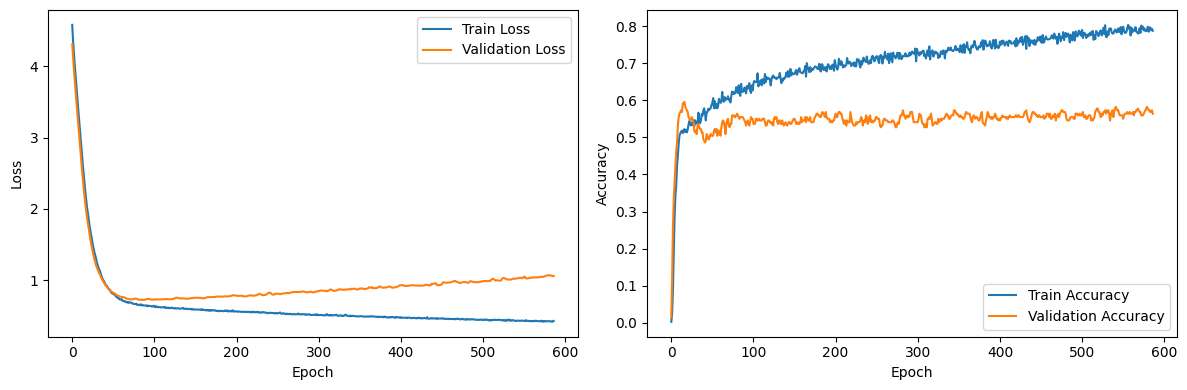


========== Run 22 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4024, Val Loss: 3.1997, Train Acc: 0.5222, Val Acc: 0.4549
Epoch: 020, Train Loss: 2.2263, Val Loss: 2.0755, Train Acc: 0.5270, Val Acc: 0.4699
Epoch: 030, Train Loss: 1.4664, Val Loss: 1.4154, Train Acc: 0.5753, Val Acc: 0.4925
Epoch: 040, Train Loss: 1.0604, Val Loss: 1.0915, Train Acc: 0.5882, Val Acc: 0.5338
Epoch: 050, Train Loss: 0.8536, Val Loss: 0.9161, Train Acc: 0.6213, Val Acc: 0.5639
Epoch: 060, Train Loss: 0.7493, Val Loss: 0.8266, Train Acc: 0.6374, Val Acc: 0.5639
Epoch: 070, Train Loss: 0.6947, Val Loss: 0.7831, Train Acc: 0.6317, Val Acc: 0.5677
Epoch: 080, Train Loss: 0.6689, Val Loss: 0.7709, Train Acc: 0.6454, Val Acc: 0.5714
Epoch: 090, Train Loss: 0.6445, Val Loss: 0.7607, Train Acc: 0.6487, Val Acc: 0.5789
Epoch: 100, Train Loss: 0.6351, Val Loss: 0.7574, Train Acc: 0.6519, Val Acc: 0.5902
Epoch: 110, Train Los

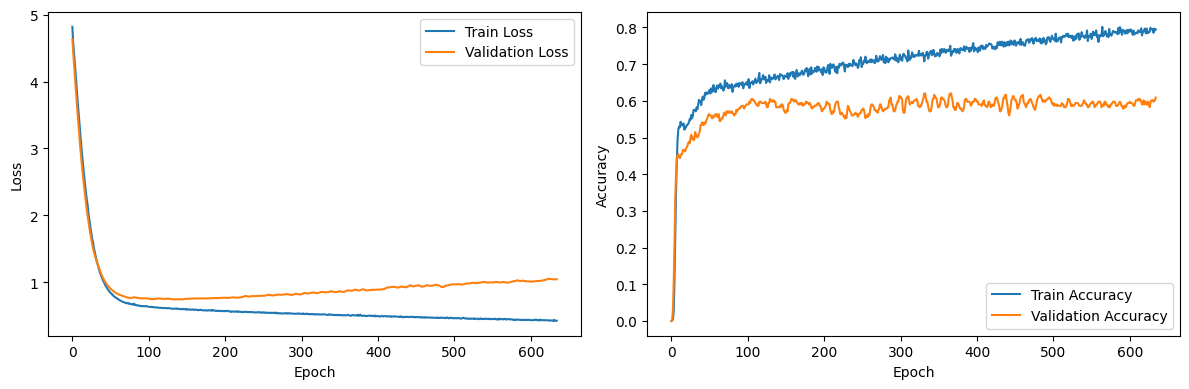


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3676, Val Loss: 3.2579, Train Acc: 0.5151, Val Acc: 0.4941
Epoch: 020, Train Loss: 2.2320, Val Loss: 2.1780, Train Acc: 0.5730, Val Acc: 0.5137
Epoch: 030, Train Loss: 1.5120, Val Loss: 1.4979, Train Acc: 0.5713, Val Acc: 0.5255
Epoch: 040, Train Loss: 1.0931, Val Loss: 1.1037, Train Acc: 0.6141, Val Acc: 0.5333
Epoch: 050, Train Loss: 0.8743, Val Loss: 0.9250, Train Acc: 0.6191, Val Acc: 0.5137
Epoch: 060, Train Loss: 0.7570, Val Loss: 0.8128, Train Acc: 0.6317, Val Acc: 0.5294
Epoch: 070, Train Loss: 0.6949, Val Loss: 0.7699, Train Acc: 0.6493, Val Acc: 0.5294
Epoch: 080, Train Loss: 0.6571, Val Loss: 0.7513, Train Acc: 0.6460, Val Acc: 0.5137
Epoch: 090, Train Loss: 0.6333, Val Loss: 0.7296, Train Acc: 0.6552, Val Acc: 0.5373
Epoch: 100, Train Loss: 0.6245, Val Loss: 0.7225, Train Acc: 0.6518, Val Acc: 0.5647
Epoch: 110, Train Loss: 0.6089, Val Loss: 0.7168, Tr

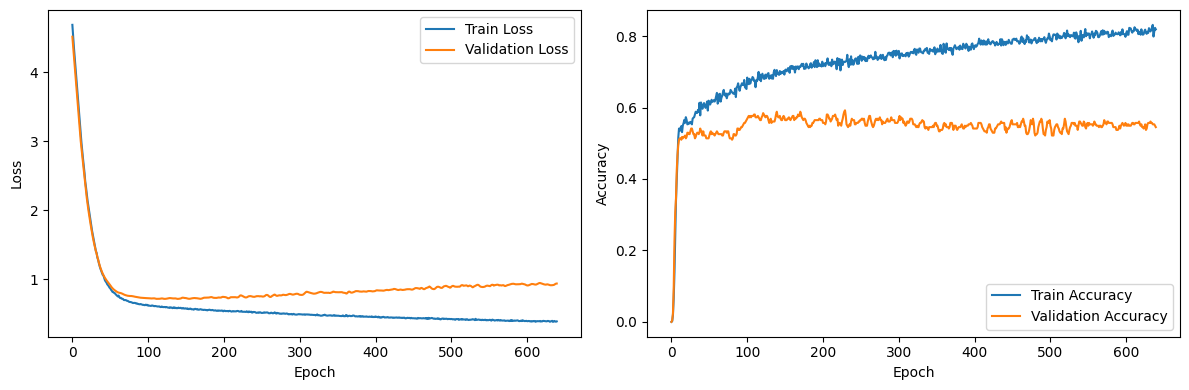


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4047, Val Loss: 3.2850, Train Acc: 0.2060, Val Acc: 0.2458
Epoch: 020, Train Loss: 2.3232, Val Loss: 2.2667, Train Acc: 0.5399, Val Acc: 0.5297
Epoch: 030, Train Loss: 1.5109, Val Loss: 1.5428, Train Acc: 0.5454, Val Acc: 0.5212
Epoch: 040, Train Loss: 1.0614, Val Loss: 1.0986, Train Acc: 0.5644, Val Acc: 0.5297
Epoch: 050, Train Loss: 0.8543, Val Loss: 0.8995, Train Acc: 0.5826, Val Acc: 0.5466
Epoch: 060, Train Loss: 0.7619, Val Loss: 0.8081, Train Acc: 0.6143, Val Acc: 0.5805
Epoch: 070, Train Loss: 0.7071, Val Loss: 0.7722, Train Acc: 0.6261, Val Acc: 0.5636
Epoch: 080, Train Loss: 0.6846, Val Loss: 0.7468, Train Acc: 0.6361, Val Acc: 0.5636
Epoch: 090, Train Loss: 0.6617, Val Loss: 0.7367, Train Acc: 0.6243, Val Acc: 0.5636
Epoch: 100, Train Loss: 0.6500, Val Loss: 0.7177, Train Acc: 0.6434, Val Acc: 0.5381
Epoch: 110, Train Loss: 0.6378, Val Loss: 0.7192, Tr

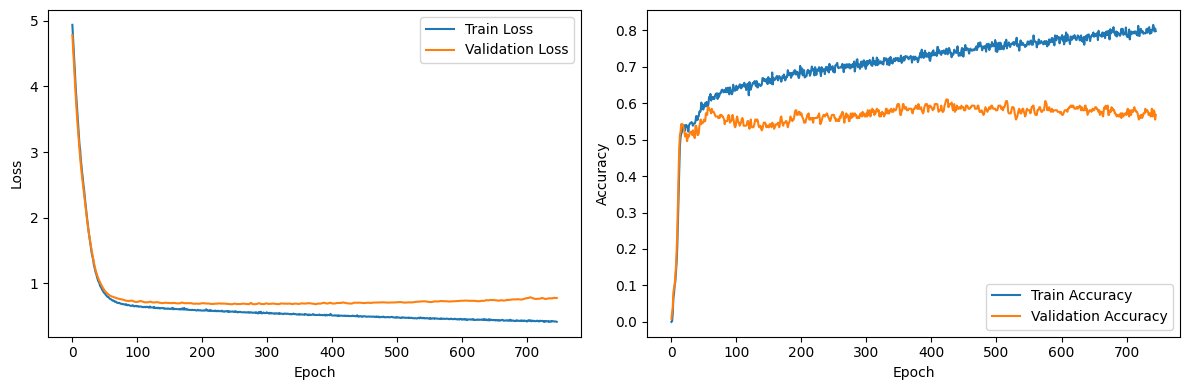


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5140, Val Loss: 3.2660, Train Acc: 0.3022, Val Acc: 0.4174
Epoch: 020, Train Loss: 2.2736, Val Loss: 2.1022, Train Acc: 0.4951, Val Acc: 0.5367
Epoch: 030, Train Loss: 1.4807, Val Loss: 1.3636, Train Acc: 0.5030, Val Acc: 0.5183
Epoch: 040, Train Loss: 1.0466, Val Loss: 0.9987, Train Acc: 0.5482, Val Acc: 0.5459
Epoch: 050, Train Loss: 0.8465, Val Loss: 0.8537, Train Acc: 0.5728, Val Acc: 0.5367
Epoch: 060, Train Loss: 0.7459, Val Loss: 0.7878, Train Acc: 0.5935, Val Acc: 0.5046
Epoch: 070, Train Loss: 0.6953, Val Loss: 0.7734, Train Acc: 0.6004, Val Acc: 0.5183
Epoch: 080, Train Loss: 0.6677, Val Loss: 0.7515, Train Acc: 0.6201, Val Acc: 0.5000
Epoch: 090, Train Loss: 0.6539, Val Loss: 0.7481, Train Acc: 0.6250, Val Acc: 0.5413
Epoch: 100, Train Loss: 0.6454, Val Loss: 0.7542, Train Acc: 0.6467, Val Acc: 0.5688
Epoch: 110, Train Loss: 0.6293, Val Loss: 0.7531, Tr

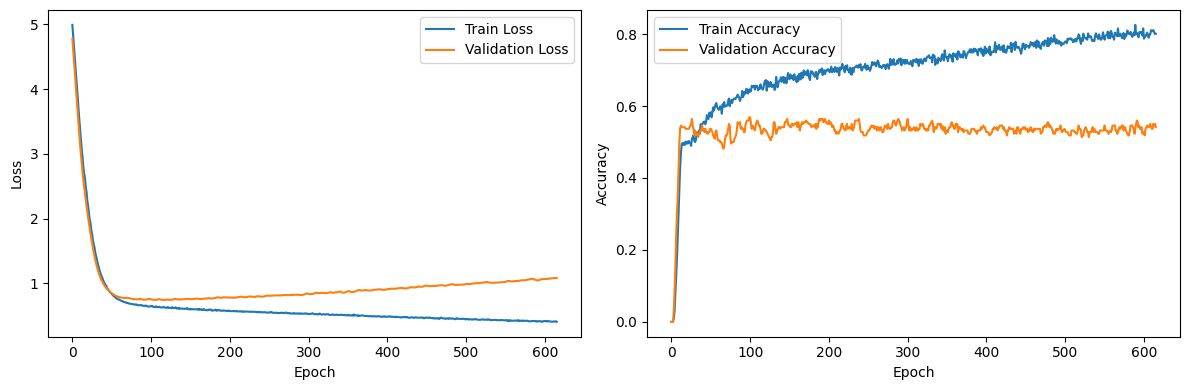


========== Run 23 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5148, Val Loss: 3.3130, Train Acc: 0.5222, Val Acc: 0.4737
Epoch: 020, Train Loss: 2.2680, Val Loss: 2.1002, Train Acc: 0.5737, Val Acc: 0.4699
Epoch: 030, Train Loss: 1.4811, Val Loss: 1.3778, Train Acc: 0.5987, Val Acc: 0.5301
Epoch: 040, Train Loss: 1.0616, Val Loss: 1.0359, Train Acc: 0.6076, Val Acc: 0.5639
Epoch: 050, Train Loss: 0.8661, Val Loss: 0.8763, Train Acc: 0.6035, Val Acc: 0.5789
Epoch: 060, Train Loss: 0.7642, Val Loss: 0.8142, Train Acc: 0.6148, Val Acc: 0.5564
Epoch: 070, Train Loss: 0.7098, Val Loss: 0.7714, Train Acc: 0.6293, Val Acc: 0.5752
Epoch: 080, Train Loss: 0.6755, Val Loss: 0.7416, Train Acc: 0.6422, Val Acc: 0.5827
Epoch: 090, Train Loss: 0.6604, Val Loss: 0.7407, Train Acc: 0.6438, Val Acc: 0.5827
Epoch: 100, Train Loss: 0.6472, Val Loss: 0.7390, Train Acc: 0.6350, Val Acc: 0.5677
Epoch: 110, Train Los

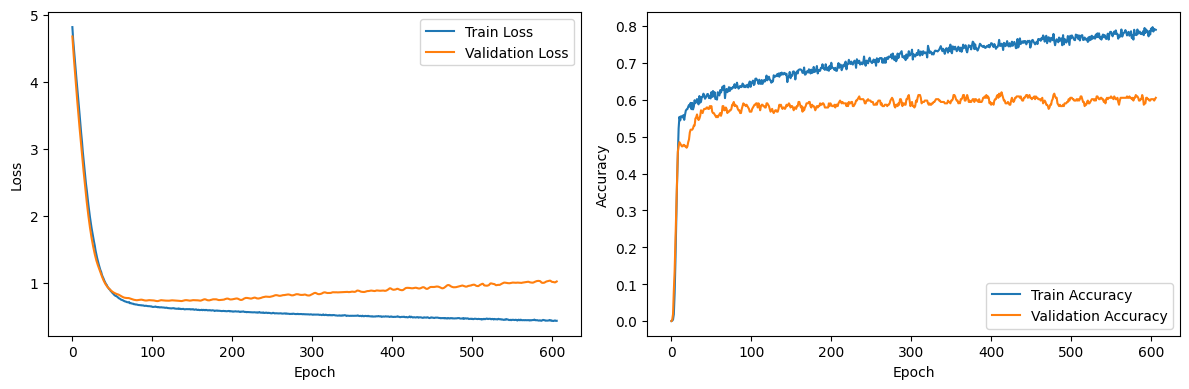


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0703, Val Loss: 2.9565, Train Acc: 0.5545, Val Acc: 0.5412
Epoch: 020, Train Loss: 1.9421, Val Loss: 1.8890, Train Acc: 0.5663, Val Acc: 0.5412
Epoch: 030, Train Loss: 1.2949, Val Loss: 1.2927, Train Acc: 0.6015, Val Acc: 0.5255
Epoch: 040, Train Loss: 0.9782, Val Loss: 0.9922, Train Acc: 0.6032, Val Acc: 0.5725
Epoch: 050, Train Loss: 0.8121, Val Loss: 0.8475, Train Acc: 0.6023, Val Acc: 0.5647
Epoch: 060, Train Loss: 0.7285, Val Loss: 0.7864, Train Acc: 0.6258, Val Acc: 0.5569
Epoch: 070, Train Loss: 0.6765, Val Loss: 0.7580, Train Acc: 0.6586, Val Acc: 0.5333
Epoch: 080, Train Loss: 0.6836, Val Loss: 0.7304, Train Acc: 0.6250, Val Acc: 0.5647
Epoch: 090, Train Loss: 0.6299, Val Loss: 0.7299, Train Acc: 0.6661, Val Acc: 0.5451
Epoch: 100, Train Loss: 0.6289, Val Loss: 0.7369, Train Acc: 0.6711, Val Acc: 0.5373
Epoch: 110, Train Loss: 0.6097, Val Loss: 0.7366, Tr

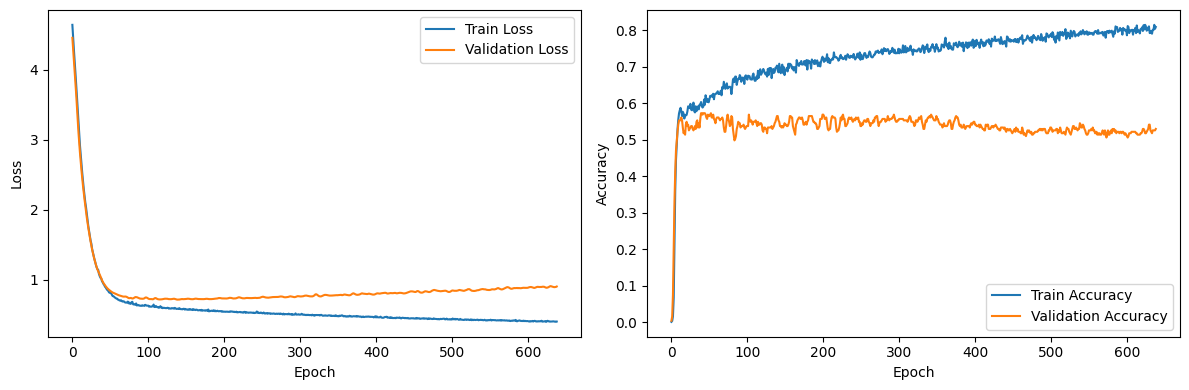


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2656, Val Loss: 3.1127, Train Acc: 0.5073, Val Acc: 0.5212
Epoch: 020, Train Loss: 2.1051, Val Loss: 2.0579, Train Acc: 0.5118, Val Acc: 0.5085
Epoch: 030, Train Loss: 1.3914, Val Loss: 1.4077, Train Acc: 0.5236, Val Acc: 0.4958
Epoch: 040, Train Loss: 1.0184, Val Loss: 1.0591, Train Acc: 0.5581, Val Acc: 0.4831
Epoch: 050, Train Loss: 0.8287, Val Loss: 0.8752, Train Acc: 0.5907, Val Acc: 0.5508
Epoch: 060, Train Loss: 0.7546, Val Loss: 0.7968, Train Acc: 0.6125, Val Acc: 0.5636
Epoch: 070, Train Loss: 0.7033, Val Loss: 0.7620, Train Acc: 0.6071, Val Acc: 0.5678
Epoch: 080, Train Loss: 0.6877, Val Loss: 0.7372, Train Acc: 0.6098, Val Acc: 0.5297
Epoch: 090, Train Loss: 0.6762, Val Loss: 0.7209, Train Acc: 0.6298, Val Acc: 0.5551
Epoch: 100, Train Loss: 0.6558, Val Loss: 0.7162, Train Acc: 0.6270, Val Acc: 0.5551
Epoch: 110, Train Loss: 0.6408, Val Loss: 0.7120, Tr

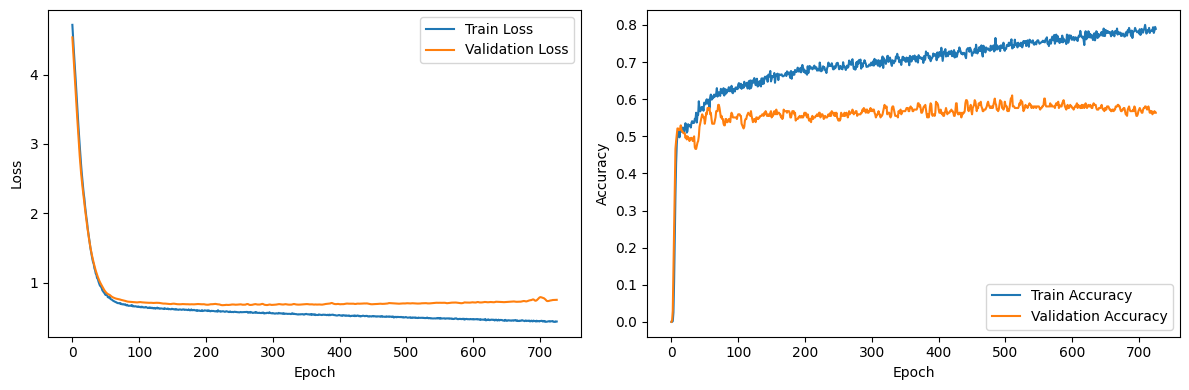


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3087, Val Loss: 3.1006, Train Acc: 0.4764, Val Acc: 0.4725
Epoch: 020, Train Loss: 2.1448, Val Loss: 2.0053, Train Acc: 0.5531, Val Acc: 0.4862
Epoch: 030, Train Loss: 1.3932, Val Loss: 1.3548, Train Acc: 0.5600, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.0158, Val Loss: 1.0151, Train Acc: 0.5965, Val Acc: 0.5138
Epoch: 050, Train Loss: 0.8428, Val Loss: 0.8742, Train Acc: 0.5915, Val Acc: 0.5275
Epoch: 060, Train Loss: 0.7428, Val Loss: 0.8144, Train Acc: 0.6142, Val Acc: 0.5459
Epoch: 070, Train Loss: 0.6977, Val Loss: 0.7826, Train Acc: 0.6181, Val Acc: 0.5505
Epoch: 080, Train Loss: 0.6737, Val Loss: 0.7785, Train Acc: 0.6299, Val Acc: 0.5780
Epoch: 090, Train Loss: 0.6506, Val Loss: 0.7775, Train Acc: 0.6260, Val Acc: 0.5734
Epoch: 100, Train Loss: 0.6406, Val Loss: 0.7599, Train Acc: 0.6368, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.6328, Val Loss: 0.7616, Tr

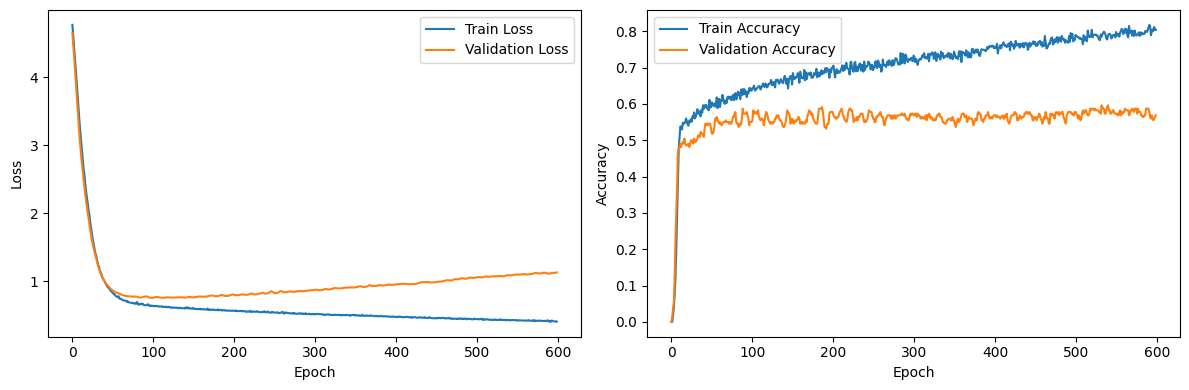


========== Run 24 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2031, Val Loss: 2.9633, Train Acc: 0.4424, Val Acc: 0.4887
Epoch: 020, Train Loss: 2.0026, Val Loss: 1.8286, Train Acc: 0.5665, Val Acc: 0.5263
Epoch: 030, Train Loss: 1.2826, Val Loss: 1.2054, Train Acc: 0.5898, Val Acc: 0.5752
Epoch: 040, Train Loss: 0.9322, Val Loss: 0.9240, Train Acc: 0.6003, Val Acc: 0.5940
Epoch: 050, Train Loss: 0.7738, Val Loss: 0.8009, Train Acc: 0.6172, Val Acc: 0.5977
Epoch: 060, Train Loss: 0.7024, Val Loss: 0.7468, Train Acc: 0.6197, Val Acc: 0.6015
Epoch: 070, Train Loss: 0.6677, Val Loss: 0.7266, Train Acc: 0.6261, Val Acc: 0.6165
Epoch: 080, Train Loss: 0.6457, Val Loss: 0.7235, Train Acc: 0.6487, Val Acc: 0.6015
Epoch: 090, Train Loss: 0.6390, Val Loss: 0.7117, Train Acc: 0.6382, Val Acc: 0.6203
Epoch: 100, Train Loss: 0.6278, Val Loss: 0.7143, Train Acc: 0.6503, Val Acc: 0.6203
Epoch: 110, Train Los

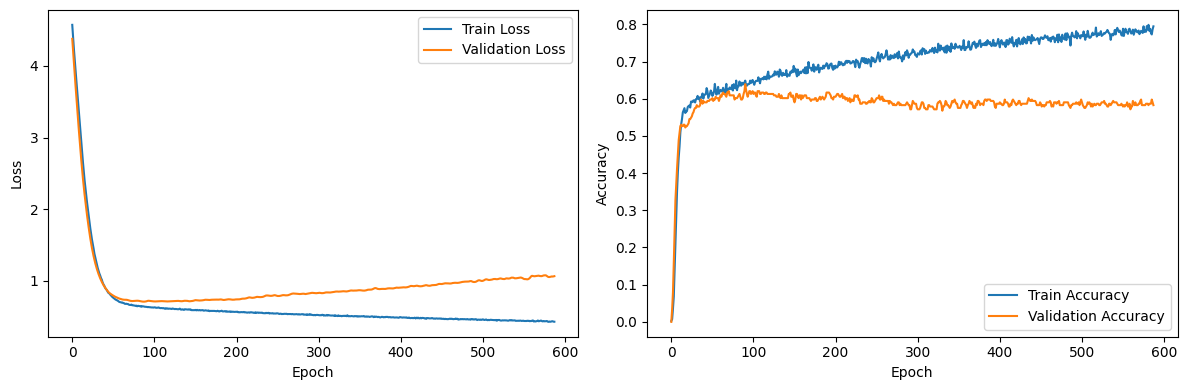


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1946, Val Loss: 3.1367, Train Acc: 0.4740, Val Acc: 0.4941
Epoch: 020, Train Loss: 2.0719, Val Loss: 2.0454, Train Acc: 0.5336, Val Acc: 0.5020
Epoch: 030, Train Loss: 1.3566, Val Loss: 1.3687, Train Acc: 0.5621, Val Acc: 0.5059
Epoch: 040, Train Loss: 0.9916, Val Loss: 1.0161, Train Acc: 0.5831, Val Acc: 0.5373
Epoch: 050, Train Loss: 0.8200, Val Loss: 0.8595, Train Acc: 0.5940, Val Acc: 0.5333
Epoch: 060, Train Loss: 0.7366, Val Loss: 0.7866, Train Acc: 0.6116, Val Acc: 0.5255
Epoch: 070, Train Loss: 0.6789, Val Loss: 0.7565, Train Acc: 0.6208, Val Acc: 0.5333
Epoch: 080, Train Loss: 0.6522, Val Loss: 0.7311, Train Acc: 0.6527, Val Acc: 0.5373
Epoch: 090, Train Loss: 0.6388, Val Loss: 0.7250, Train Acc: 0.6477, Val Acc: 0.5333
Epoch: 100, Train Loss: 0.6342, Val Loss: 0.7362, Train Acc: 0.6451, Val Acc: 0.5137
Epoch: 110, Train Loss: 0.6272, Val Loss: 0.7097, Tr

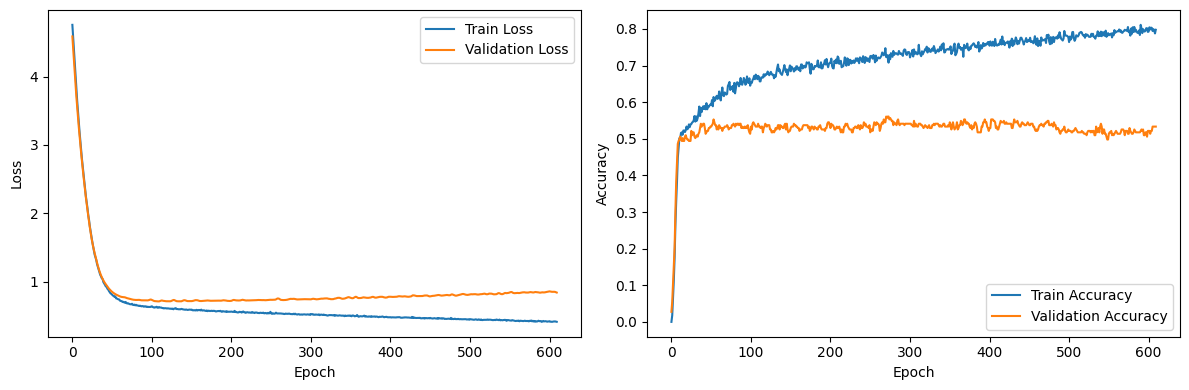


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2775, Val Loss: 3.1129, Train Acc: 0.3258, Val Acc: 0.4280
Epoch: 020, Train Loss: 2.1702, Val Loss: 2.1182, Train Acc: 0.5163, Val Acc: 0.5085
Epoch: 030, Train Loss: 1.3687, Val Loss: 1.3658, Train Acc: 0.5263, Val Acc: 0.5212
Epoch: 040, Train Loss: 0.9936, Val Loss: 0.9951, Train Acc: 0.5490, Val Acc: 0.5424
Epoch: 050, Train Loss: 0.8058, Val Loss: 0.8420, Train Acc: 0.5708, Val Acc: 0.5466
Epoch: 060, Train Loss: 0.7347, Val Loss: 0.7731, Train Acc: 0.6034, Val Acc: 0.5212
Epoch: 070, Train Loss: 0.6866, Val Loss: 0.7458, Train Acc: 0.6352, Val Acc: 0.5508
Epoch: 080, Train Loss: 0.6621, Val Loss: 0.7341, Train Acc: 0.6379, Val Acc: 0.5720
Epoch: 090, Train Loss: 0.6487, Val Loss: 0.7194, Train Acc: 0.6452, Val Acc: 0.5720
Epoch: 100, Train Loss: 0.6382, Val Loss: 0.7164, Train Acc: 0.6597, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6362, Val Loss: 0.7212, Tr

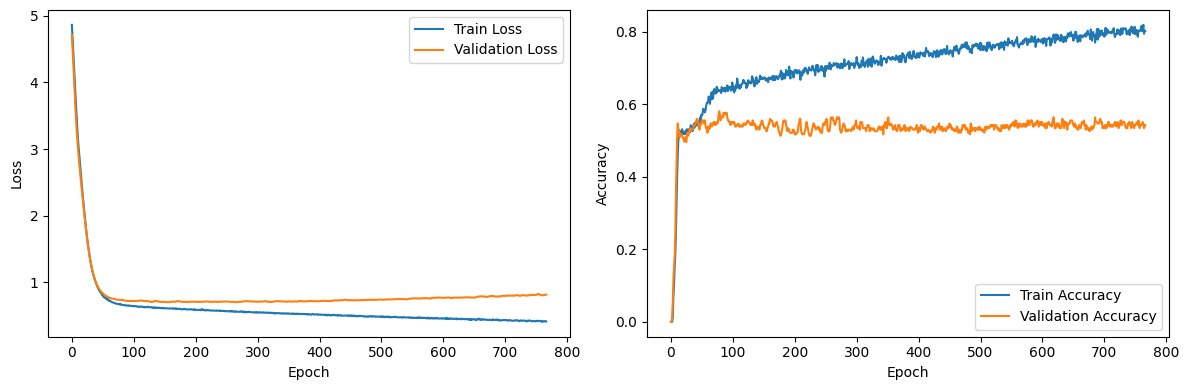


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4075, Val Loss: 3.1873, Train Acc: 0.4203, Val Acc: 0.4908
Epoch: 020, Train Loss: 2.1540, Val Loss: 1.9862, Train Acc: 0.4970, Val Acc: 0.5229
Epoch: 030, Train Loss: 1.4234, Val Loss: 1.3102, Train Acc: 0.5138, Val Acc: 0.5550
Epoch: 040, Train Loss: 1.0524, Val Loss: 0.9944, Train Acc: 0.5728, Val Acc: 0.5963
Epoch: 050, Train Loss: 0.8725, Val Loss: 0.8565, Train Acc: 0.5955, Val Acc: 0.5826
Epoch: 060, Train Loss: 0.7767, Val Loss: 0.7840, Train Acc: 0.5827, Val Acc: 0.5826
Epoch: 070, Train Loss: 0.7142, Val Loss: 0.7511, Train Acc: 0.6112, Val Acc: 0.5688
Epoch: 080, Train Loss: 0.6751, Val Loss: 0.7389, Train Acc: 0.6358, Val Acc: 0.5734
Epoch: 090, Train Loss: 0.6614, Val Loss: 0.7332, Train Acc: 0.6447, Val Acc: 0.5688
Epoch: 100, Train Loss: 0.6483, Val Loss: 0.7244, Train Acc: 0.6644, Val Acc: 0.5688
Epoch: 110, Train Loss: 0.6344, Val Loss: 0.7247, Tr

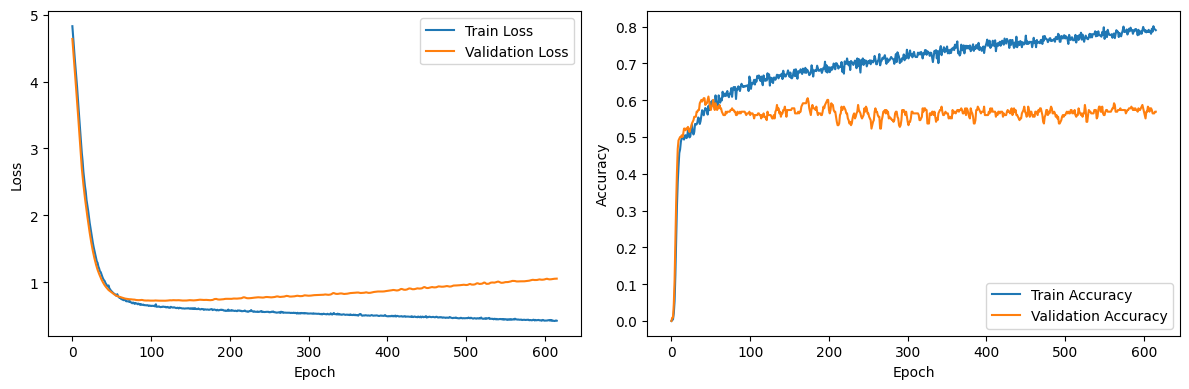


========== Run 25 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5586, Val Loss: 3.3787, Train Acc: 0.3707, Val Acc: 0.3684
Epoch: 020, Train Loss: 2.3695, Val Loss: 2.1774, Train Acc: 0.5254, Val Acc: 0.5038
Epoch: 030, Train Loss: 1.5684, Val Loss: 1.4664, Train Acc: 0.5536, Val Acc: 0.5263
Epoch: 040, Train Loss: 1.0986, Val Loss: 1.0927, Train Acc: 0.5939, Val Acc: 0.5301
Epoch: 050, Train Loss: 0.8728, Val Loss: 0.9212, Train Acc: 0.6116, Val Acc: 0.5376
Epoch: 060, Train Loss: 0.7486, Val Loss: 0.8225, Train Acc: 0.6326, Val Acc: 0.5789
Epoch: 070, Train Loss: 0.6956, Val Loss: 0.7855, Train Acc: 0.6382, Val Acc: 0.5752
Epoch: 080, Train Loss: 0.6678, Val Loss: 0.7600, Train Acc: 0.6519, Val Acc: 0.5752
Epoch: 090, Train Loss: 0.6637, Val Loss: 0.7600, Train Acc: 0.6366, Val Acc: 0.5752
Epoch: 100, Train Loss: 0.6411, Val Loss: 0.7533, Train Acc: 0.6559, Val Acc: 0.5752
Epoch: 110, Train Los

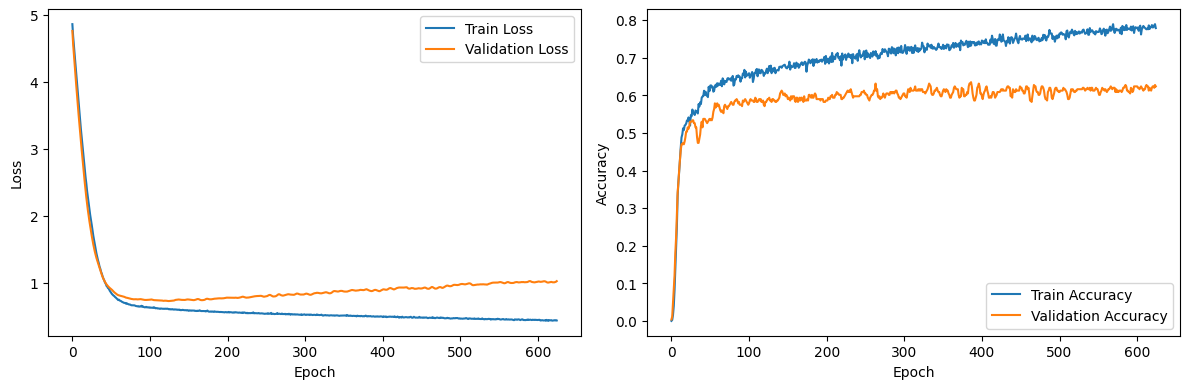


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3238, Val Loss: 3.2204, Train Acc: 0.4673, Val Acc: 0.4314
Epoch: 020, Train Loss: 2.1267, Val Loss: 2.1069, Train Acc: 0.5478, Val Acc: 0.4745
Epoch: 030, Train Loss: 1.4296, Val Loss: 1.4500, Train Acc: 0.5487, Val Acc: 0.4980
Epoch: 040, Train Loss: 1.0767, Val Loss: 1.0896, Train Acc: 0.5587, Val Acc: 0.5098
Epoch: 050, Train Loss: 0.8858, Val Loss: 0.9094, Train Acc: 0.5864, Val Acc: 0.5255
Epoch: 060, Train Loss: 0.7910, Val Loss: 0.8153, Train Acc: 0.6049, Val Acc: 0.5451
Epoch: 070, Train Loss: 0.7161, Val Loss: 0.7730, Train Acc: 0.6242, Val Acc: 0.5608
Epoch: 080, Train Loss: 0.6861, Val Loss: 0.7555, Train Acc: 0.6317, Val Acc: 0.5451
Epoch: 090, Train Loss: 0.6545, Val Loss: 0.7277, Train Acc: 0.6342, Val Acc: 0.5882
Epoch: 100, Train Loss: 0.6402, Val Loss: 0.7236, Train Acc: 0.6535, Val Acc: 0.5843
Epoch: 110, Train Loss: 0.6314, Val Loss: 0.7258, Tr

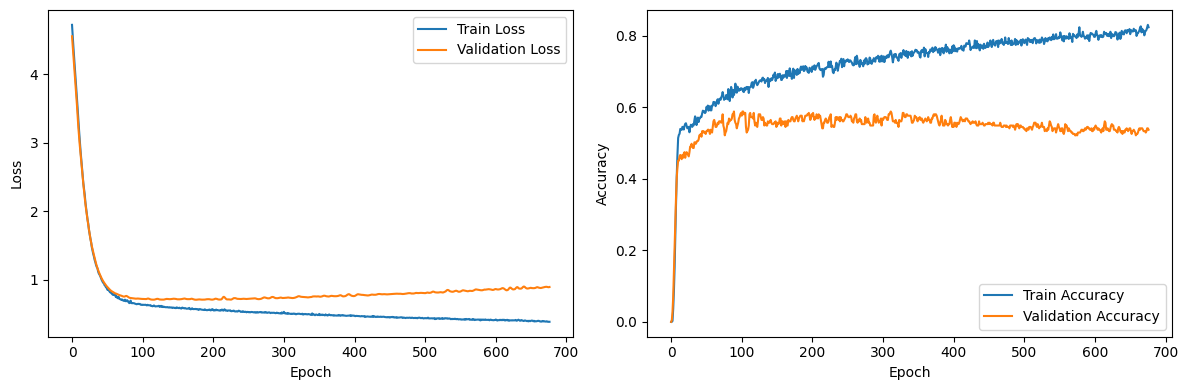


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4407, Val Loss: 3.3323, Train Acc: 0.4574, Val Acc: 0.4449
Epoch: 020, Train Loss: 2.3560, Val Loss: 2.3363, Train Acc: 0.5191, Val Acc: 0.4873
Epoch: 030, Train Loss: 1.5711, Val Loss: 1.5861, Train Acc: 0.5408, Val Acc: 0.5042
Epoch: 040, Train Loss: 1.1071, Val Loss: 1.1438, Train Acc: 0.5708, Val Acc: 0.4873
Epoch: 050, Train Loss: 0.8796, Val Loss: 0.9412, Train Acc: 0.5917, Val Acc: 0.4788
Epoch: 060, Train Loss: 0.7803, Val Loss: 0.8289, Train Acc: 0.5980, Val Acc: 0.4576
Epoch: 070, Train Loss: 0.7087, Val Loss: 0.7770, Train Acc: 0.6134, Val Acc: 0.5297
Epoch: 080, Train Loss: 0.6828, Val Loss: 0.7549, Train Acc: 0.6143, Val Acc: 0.5424
Epoch: 090, Train Loss: 0.6603, Val Loss: 0.7518, Train Acc: 0.6325, Val Acc: 0.5466
Epoch: 100, Train Loss: 0.6540, Val Loss: 0.7379, Train Acc: 0.6497, Val Acc: 0.5339
Epoch: 110, Train Loss: 0.6412, Val Loss: 0.7331, Tr

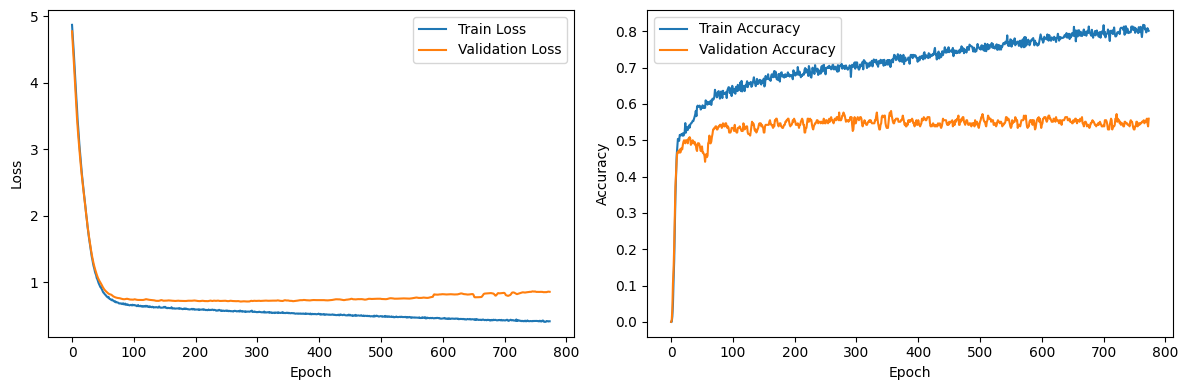


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2806, Val Loss: 3.0795, Train Acc: 0.4577, Val Acc: 0.4908
Epoch: 020, Train Loss: 2.1318, Val Loss: 2.0034, Train Acc: 0.5226, Val Acc: 0.5000
Epoch: 030, Train Loss: 1.4216, Val Loss: 1.3485, Train Acc: 0.5551, Val Acc: 0.5229
Epoch: 040, Train Loss: 1.0277, Val Loss: 0.9875, Train Acc: 0.5719, Val Acc: 0.5321
Epoch: 050, Train Loss: 0.8396, Val Loss: 0.8334, Train Acc: 0.6014, Val Acc: 0.5321
Epoch: 060, Train Loss: 0.7636, Val Loss: 0.7665, Train Acc: 0.6112, Val Acc: 0.5505
Epoch: 070, Train Loss: 0.7078, Val Loss: 0.7449, Train Acc: 0.6073, Val Acc: 0.5275
Epoch: 080, Train Loss: 0.6677, Val Loss: 0.7267, Train Acc: 0.6250, Val Acc: 0.5505
Epoch: 090, Train Loss: 0.6550, Val Loss: 0.7177, Train Acc: 0.6476, Val Acc: 0.5367
Epoch: 100, Train Loss: 0.6303, Val Loss: 0.7202, Train Acc: 0.6703, Val Acc: 0.5367
Epoch: 110, Train Loss: 0.6246, Val Loss: 0.7251, Tr

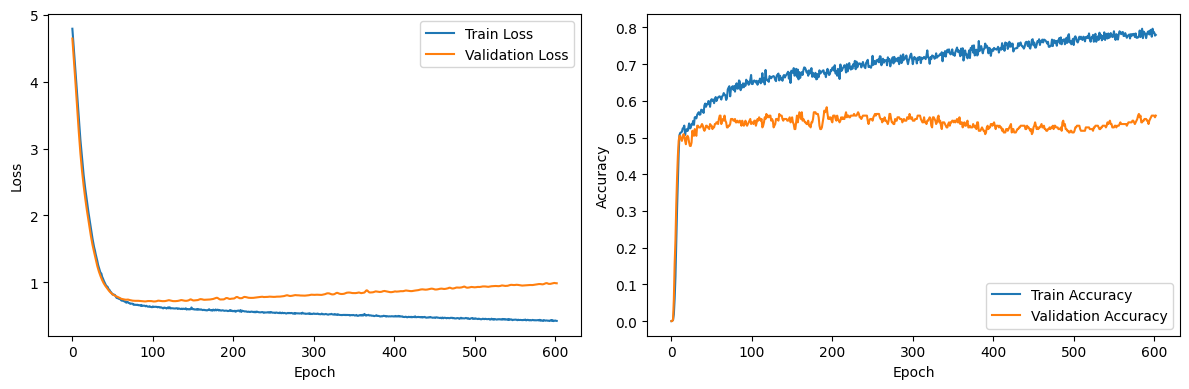


========== Run 26 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1028, Val Loss: 2.8094, Train Acc: 0.4932, Val Acc: 0.5526
Epoch: 020, Train Loss: 2.0878, Val Loss: 1.9084, Train Acc: 0.5810, Val Acc: 0.5752
Epoch: 030, Train Loss: 1.4075, Val Loss: 1.3128, Train Acc: 0.5923, Val Acc: 0.5489
Epoch: 040, Train Loss: 1.0262, Val Loss: 0.9911, Train Acc: 0.5923, Val Acc: 0.5752
Epoch: 050, Train Loss: 0.8165, Val Loss: 0.8245, Train Acc: 0.6148, Val Acc: 0.6053
Epoch: 060, Train Loss: 0.7356, Val Loss: 0.7602, Train Acc: 0.6060, Val Acc: 0.5977
Epoch: 070, Train Loss: 0.6823, Val Loss: 0.7331, Train Acc: 0.6309, Val Acc: 0.5902
Epoch: 080, Train Loss: 0.6559, Val Loss: 0.7184, Train Acc: 0.6511, Val Acc: 0.5940
Epoch: 090, Train Loss: 0.6418, Val Loss: 0.7185, Train Acc: 0.6390, Val Acc: 0.5752
Epoch: 100, Train Loss: 0.6357, Val Loss: 0.7230, Train Acc: 0.6479, Val Acc: 0.5789
Epoch: 110, Train Los

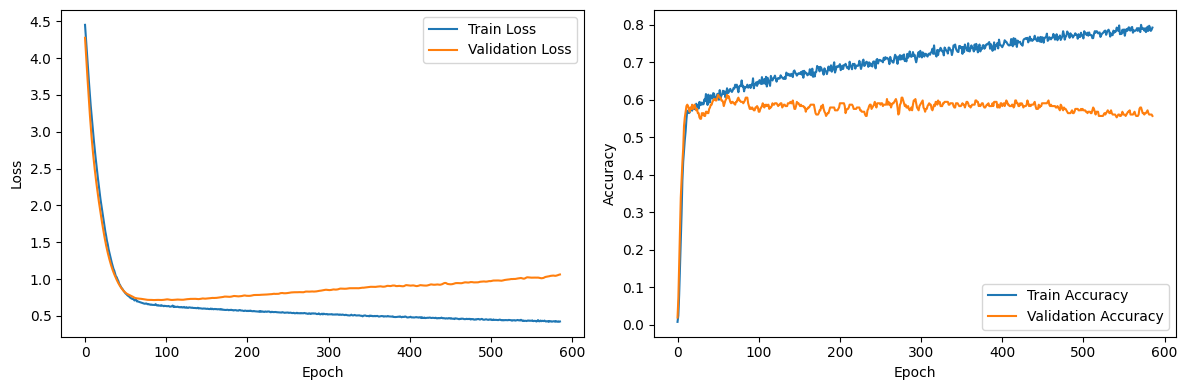


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2789, Val Loss: 3.1648, Train Acc: 0.4589, Val Acc: 0.4941
Epoch: 020, Train Loss: 2.0418, Val Loss: 1.9616, Train Acc: 0.5017, Val Acc: 0.5216
Epoch: 030, Train Loss: 1.3349, Val Loss: 1.3031, Train Acc: 0.5201, Val Acc: 0.5216
Epoch: 040, Train Loss: 0.9640, Val Loss: 0.9893, Train Acc: 0.5948, Val Acc: 0.5451
Epoch: 050, Train Loss: 0.8223, Val Loss: 0.8593, Train Acc: 0.5831, Val Acc: 0.5098
Epoch: 060, Train Loss: 0.7162, Val Loss: 0.8108, Train Acc: 0.6267, Val Acc: 0.5216
Epoch: 070, Train Loss: 0.6786, Val Loss: 0.7502, Train Acc: 0.6292, Val Acc: 0.5333
Epoch: 080, Train Loss: 0.6537, Val Loss: 0.7242, Train Acc: 0.6586, Val Acc: 0.5569
Epoch: 090, Train Loss: 0.6341, Val Loss: 0.7180, Train Acc: 0.6493, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.6176, Val Loss: 0.7206, Train Acc: 0.6678, Val Acc: 0.5176
Epoch: 110, Train Loss: 0.6160, Val Loss: 0.7120, Tr

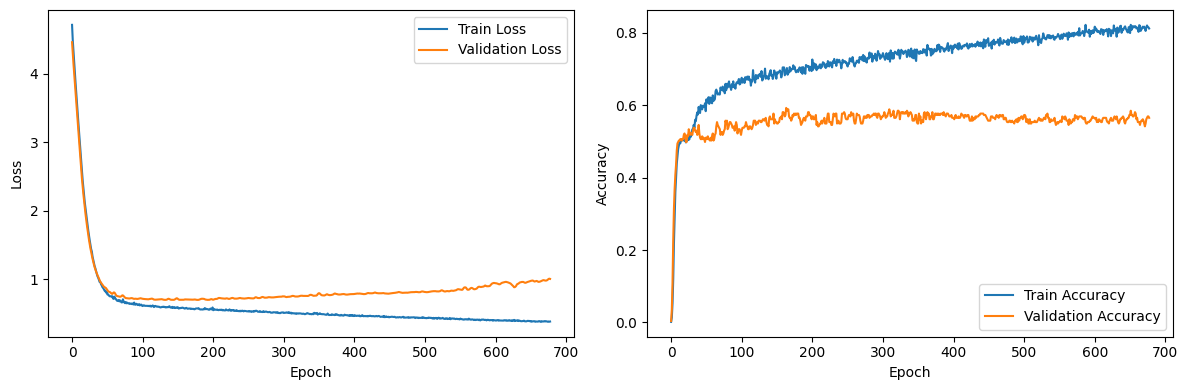


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1153, Val Loss: 2.9970, Train Acc: 0.4610, Val Acc: 0.4703
Epoch: 020, Train Loss: 2.0820, Val Loss: 2.0784, Train Acc: 0.5309, Val Acc: 0.4661
Epoch: 030, Train Loss: 1.3935, Val Loss: 1.4097, Train Acc: 0.5390, Val Acc: 0.5085
Epoch: 040, Train Loss: 1.0259, Val Loss: 1.0632, Train Acc: 0.5726, Val Acc: 0.5254
Epoch: 050, Train Loss: 0.8521, Val Loss: 0.8855, Train Acc: 0.5771, Val Acc: 0.5381
Epoch: 060, Train Loss: 0.7492, Val Loss: 0.8010, Train Acc: 0.5980, Val Acc: 0.5551
Epoch: 070, Train Loss: 0.7172, Val Loss: 0.7578, Train Acc: 0.5989, Val Acc: 0.5381
Epoch: 080, Train Loss: 0.6670, Val Loss: 0.7321, Train Acc: 0.6325, Val Acc: 0.5424
Epoch: 090, Train Loss: 0.6516, Val Loss: 0.7192, Train Acc: 0.6452, Val Acc: 0.5381
Epoch: 100, Train Loss: 0.6526, Val Loss: 0.7184, Train Acc: 0.6388, Val Acc: 0.5678
Epoch: 110, Train Loss: 0.6342, Val Loss: 0.7157, Tr

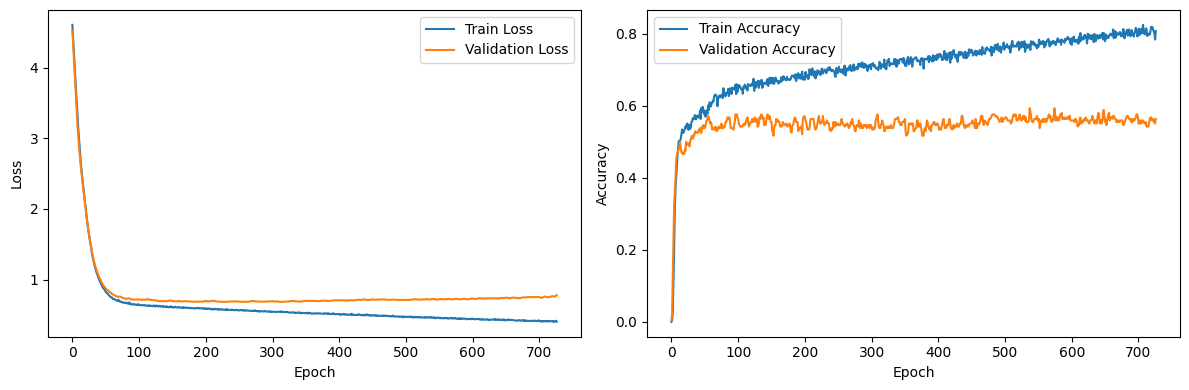


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1887, Val Loss: 2.9304, Train Acc: 0.4547, Val Acc: 0.4862
Epoch: 020, Train Loss: 2.1395, Val Loss: 1.9568, Train Acc: 0.5079, Val Acc: 0.5367
Epoch: 030, Train Loss: 1.3886, Val Loss: 1.2912, Train Acc: 0.5610, Val Acc: 0.5229
Epoch: 040, Train Loss: 1.0106, Val Loss: 0.9621, Train Acc: 0.5719, Val Acc: 0.5367
Epoch: 050, Train Loss: 0.8227, Val Loss: 0.8213, Train Acc: 0.6043, Val Acc: 0.5413
Epoch: 060, Train Loss: 0.7311, Val Loss: 0.7549, Train Acc: 0.6093, Val Acc: 0.5596
Epoch: 070, Train Loss: 0.6857, Val Loss: 0.7353, Train Acc: 0.6211, Val Acc: 0.5550
Epoch: 080, Train Loss: 0.6751, Val Loss: 0.7144, Train Acc: 0.6280, Val Acc: 0.5275
Epoch: 090, Train Loss: 0.6450, Val Loss: 0.7234, Train Acc: 0.6378, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.6392, Val Loss: 0.7084, Train Acc: 0.6407, Val Acc: 0.5413
Epoch: 110, Train Loss: 0.6290, Val Loss: 0.7079, Tr

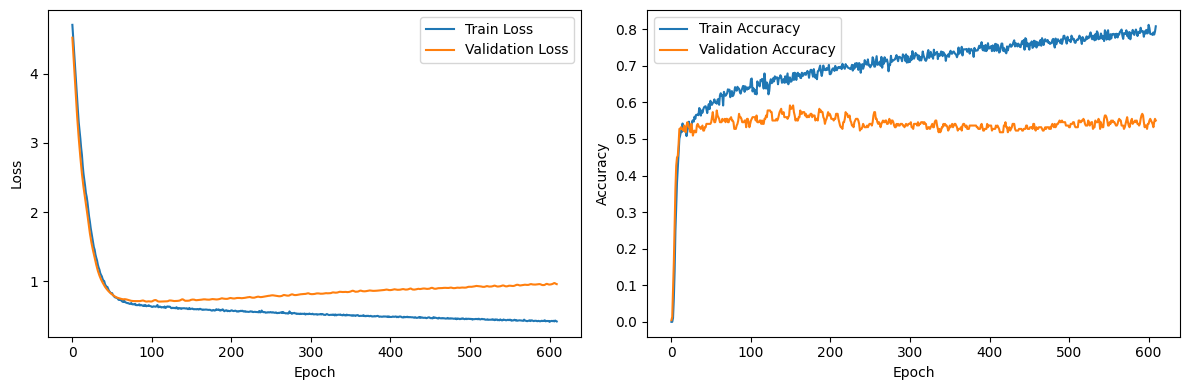


========== Run 27 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2780, Val Loss: 3.0856, Train Acc: 0.4174, Val Acc: 0.4398
Epoch: 020, Train Loss: 2.0380, Val Loss: 1.9219, Train Acc: 0.5326, Val Acc: 0.5150
Epoch: 030, Train Loss: 1.3195, Val Loss: 1.3026, Train Acc: 0.5447, Val Acc: 0.5376
Epoch: 040, Train Loss: 0.9567, Val Loss: 0.9998, Train Acc: 0.5592, Val Acc: 0.5263
Epoch: 050, Train Loss: 0.7889, Val Loss: 0.8501, Train Acc: 0.5971, Val Acc: 0.5940
Epoch: 060, Train Loss: 0.7134, Val Loss: 0.7735, Train Acc: 0.6132, Val Acc: 0.5789
Epoch: 070, Train Loss: 0.6769, Val Loss: 0.7522, Train Acc: 0.6277, Val Acc: 0.5752
Epoch: 080, Train Loss: 0.6540, Val Loss: 0.7460, Train Acc: 0.6390, Val Acc: 0.5714
Epoch: 090, Train Loss: 0.6385, Val Loss: 0.7307, Train Acc: 0.6293, Val Acc: 0.5865
Epoch: 100, Train Loss: 0.6293, Val Loss: 0.7263, Train Acc: 0.6487, Val Acc: 0.5865
Epoch: 110, Train Los

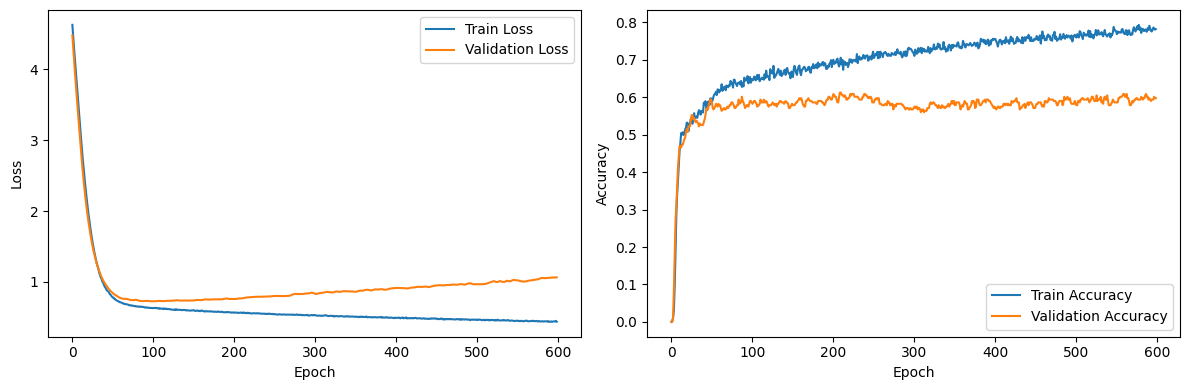


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4649, Val Loss: 3.3356, Train Acc: 0.4530, Val Acc: 0.4627
Epoch: 020, Train Loss: 2.1418, Val Loss: 2.1180, Train Acc: 0.5344, Val Acc: 0.4941
Epoch: 030, Train Loss: 1.3857, Val Loss: 1.4212, Train Acc: 0.5730, Val Acc: 0.5020
Epoch: 040, Train Loss: 1.0404, Val Loss: 1.0915, Train Acc: 0.5898, Val Acc: 0.4941
Epoch: 050, Train Loss: 0.8442, Val Loss: 0.9071, Train Acc: 0.6032, Val Acc: 0.5020
Epoch: 060, Train Loss: 0.7437, Val Loss: 0.8148, Train Acc: 0.6149, Val Acc: 0.5176
Epoch: 070, Train Loss: 0.6957, Val Loss: 0.7896, Train Acc: 0.6359, Val Acc: 0.5255
Epoch: 080, Train Loss: 0.6656, Val Loss: 0.7647, Train Acc: 0.6468, Val Acc: 0.4980
Epoch: 090, Train Loss: 0.6527, Val Loss: 0.7397, Train Acc: 0.6393, Val Acc: 0.5020
Epoch: 100, Train Loss: 0.6472, Val Loss: 0.7440, Train Acc: 0.6544, Val Acc: 0.5059
Epoch: 110, Train Loss: 0.6136, Val Loss: 0.7304, Tr

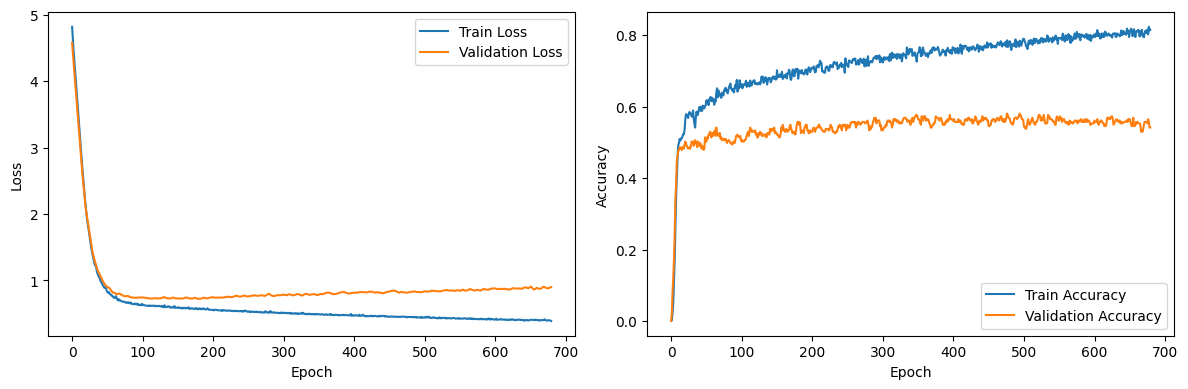


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9679, Val Loss: 2.8944, Train Acc: 0.4682, Val Acc: 0.4619
Epoch: 020, Train Loss: 2.0373, Val Loss: 2.0295, Train Acc: 0.5290, Val Acc: 0.5169
Epoch: 030, Train Loss: 1.3710, Val Loss: 1.3984, Train Acc: 0.5662, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.0162, Val Loss: 1.0618, Train Acc: 0.6025, Val Acc: 0.5169
Epoch: 050, Train Loss: 0.8405, Val Loss: 0.8945, Train Acc: 0.6116, Val Acc: 0.5551
Epoch: 060, Train Loss: 0.7379, Val Loss: 0.7987, Train Acc: 0.6234, Val Acc: 0.5381
Epoch: 070, Train Loss: 0.6966, Val Loss: 0.7489, Train Acc: 0.6143, Val Acc: 0.4958
Epoch: 080, Train Loss: 0.6642, Val Loss: 0.7364, Train Acc: 0.6361, Val Acc: 0.5636
Epoch: 090, Train Loss: 0.6466, Val Loss: 0.7228, Train Acc: 0.6479, Val Acc: 0.5508
Epoch: 100, Train Loss: 0.6373, Val Loss: 0.7185, Train Acc: 0.6479, Val Acc: 0.5466
Epoch: 110, Train Loss: 0.6310, Val Loss: 0.7147, Tr

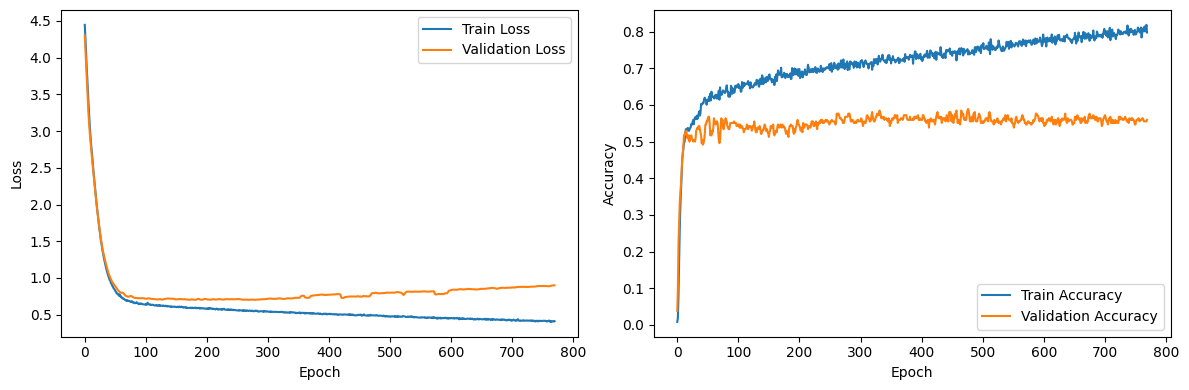


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0620, Val Loss: 2.8221, Train Acc: 0.4429, Val Acc: 0.4174
Epoch: 020, Train Loss: 2.0133, Val Loss: 1.8506, Train Acc: 0.5364, Val Acc: 0.5092
Epoch: 030, Train Loss: 1.3571, Val Loss: 1.2806, Train Acc: 0.5581, Val Acc: 0.5321
Epoch: 040, Train Loss: 1.0251, Val Loss: 1.0115, Train Acc: 0.5768, Val Acc: 0.5092
Epoch: 050, Train Loss: 0.8513, Val Loss: 0.8508, Train Acc: 0.5974, Val Acc: 0.5275
Epoch: 060, Train Loss: 0.7437, Val Loss: 0.7781, Train Acc: 0.6211, Val Acc: 0.5275
Epoch: 070, Train Loss: 0.6903, Val Loss: 0.7508, Train Acc: 0.6211, Val Acc: 0.5459
Epoch: 080, Train Loss: 0.6620, Val Loss: 0.7429, Train Acc: 0.6486, Val Acc: 0.5550
Epoch: 090, Train Loss: 0.6488, Val Loss: 0.7413, Train Acc: 0.6250, Val Acc: 0.5596
Epoch: 100, Train Loss: 0.6313, Val Loss: 0.7434, Train Acc: 0.6526, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.6260, Val Loss: 0.7442, Tr

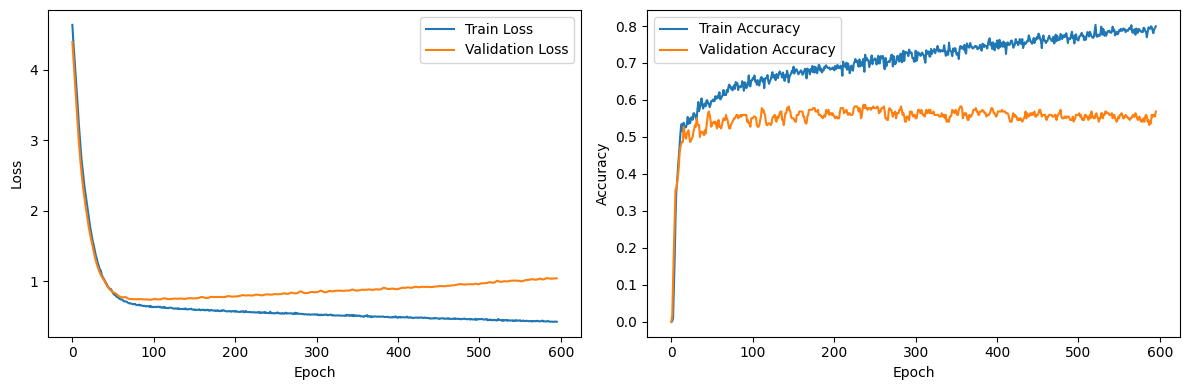


========== Run 28 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2199, Val Loss: 2.9113, Train Acc: 0.5068, Val Acc: 0.5827
Epoch: 020, Train Loss: 2.1235, Val Loss: 1.9147, Train Acc: 0.5616, Val Acc: 0.5602
Epoch: 030, Train Loss: 1.4160, Val Loss: 1.2935, Train Acc: 0.5761, Val Acc: 0.5714
Epoch: 040, Train Loss: 1.0287, Val Loss: 0.9826, Train Acc: 0.5866, Val Acc: 0.5940
Epoch: 050, Train Loss: 0.8291, Val Loss: 0.8320, Train Acc: 0.6092, Val Acc: 0.6053
Epoch: 060, Train Loss: 0.7371, Val Loss: 0.7545, Train Acc: 0.6100, Val Acc: 0.5940
Epoch: 070, Train Loss: 0.6903, Val Loss: 0.7369, Train Acc: 0.6334, Val Acc: 0.6278
Epoch: 080, Train Loss: 0.6654, Val Loss: 0.7193, Train Acc: 0.6285, Val Acc: 0.6165
Epoch: 090, Train Loss: 0.6490, Val Loss: 0.7110, Train Acc: 0.6293, Val Acc: 0.6203
Epoch: 100, Train Loss: 0.6450, Val Loss: 0.7215, Train Acc: 0.6358, Val Acc: 0.5940
Epoch: 110, Train Los

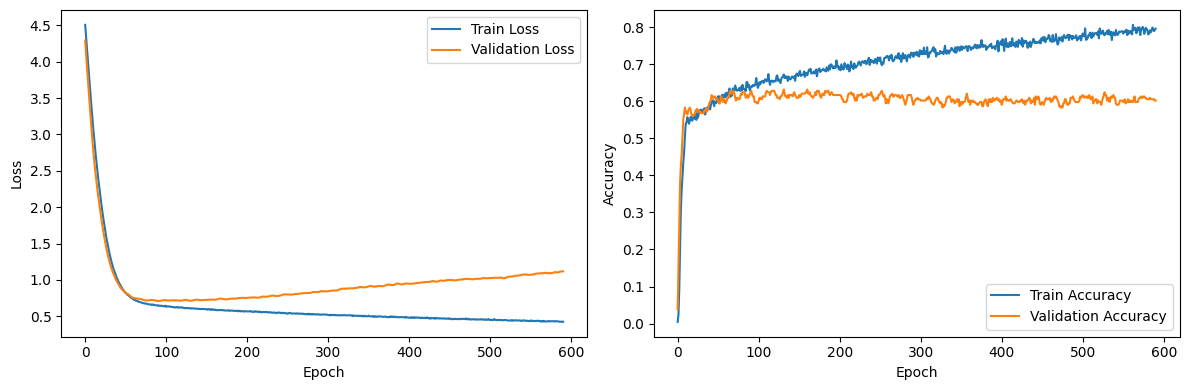


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8494, Val Loss: 2.7764, Train Acc: 0.4841, Val Acc: 0.5216
Epoch: 020, Train Loss: 1.8151, Val Loss: 1.7920, Train Acc: 0.5629, Val Acc: 0.4627
Epoch: 030, Train Loss: 1.1938, Val Loss: 1.2303, Train Acc: 0.5856, Val Acc: 0.4941
Epoch: 040, Train Loss: 0.8980, Val Loss: 0.9760, Train Acc: 0.6166, Val Acc: 0.5216
Epoch: 050, Train Loss: 0.7598, Val Loss: 0.8470, Train Acc: 0.6065, Val Acc: 0.5255
Epoch: 060, Train Loss: 0.7036, Val Loss: 0.7940, Train Acc: 0.6174, Val Acc: 0.5176
Epoch: 070, Train Loss: 0.6675, Val Loss: 0.7772, Train Acc: 0.6242, Val Acc: 0.5020
Epoch: 080, Train Loss: 0.6547, Val Loss: 0.7571, Train Acc: 0.6359, Val Acc: 0.5255
Epoch: 090, Train Loss: 0.6329, Val Loss: 0.7523, Train Acc: 0.6451, Val Acc: 0.5294
Epoch: 100, Train Loss: 0.6203, Val Loss: 0.7485, Train Acc: 0.6636, Val Acc: 0.5098
Epoch: 110, Train Loss: 0.6248, Val Loss: 0.7498, Tr

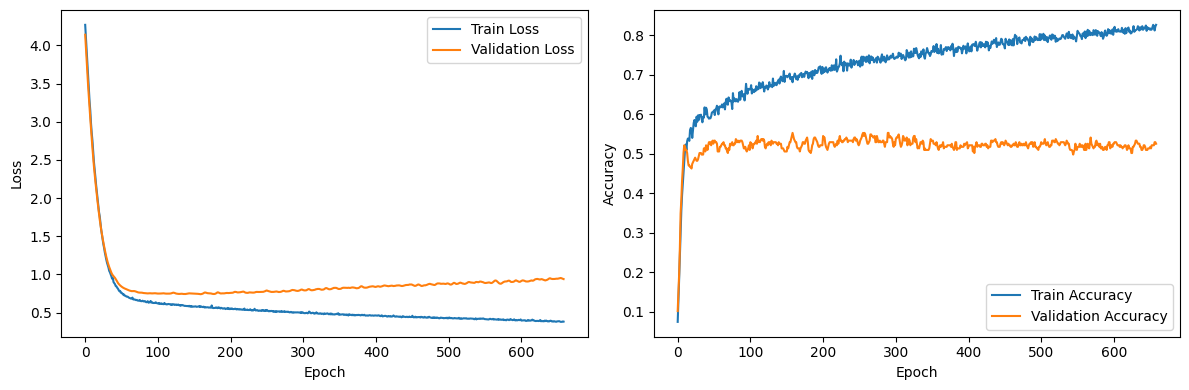


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8610, Val Loss: 2.7843, Train Acc: 0.5299, Val Acc: 0.5424
Epoch: 020, Train Loss: 1.9046, Val Loss: 1.8923, Train Acc: 0.5517, Val Acc: 0.5593
Epoch: 030, Train Loss: 1.2763, Val Loss: 1.3227, Train Acc: 0.5726, Val Acc: 0.5085
Epoch: 040, Train Loss: 0.9793, Val Loss: 1.0301, Train Acc: 0.5799, Val Acc: 0.4958
Epoch: 050, Train Loss: 0.8167, Val Loss: 0.8820, Train Acc: 0.6279, Val Acc: 0.5127
Epoch: 060, Train Loss: 0.7429, Val Loss: 0.8012, Train Acc: 0.6143, Val Acc: 0.5254
Epoch: 070, Train Loss: 0.6876, Val Loss: 0.7629, Train Acc: 0.6425, Val Acc: 0.5381
Epoch: 080, Train Loss: 0.6695, Val Loss: 0.7359, Train Acc: 0.6352, Val Acc: 0.5169
Epoch: 090, Train Loss: 0.6580, Val Loss: 0.7323, Train Acc: 0.6298, Val Acc: 0.5339
Epoch: 100, Train Loss: 0.6404, Val Loss: 0.7326, Train Acc: 0.6552, Val Acc: 0.5169
Epoch: 110, Train Loss: 0.6300, Val Loss: 0.7133, Tr

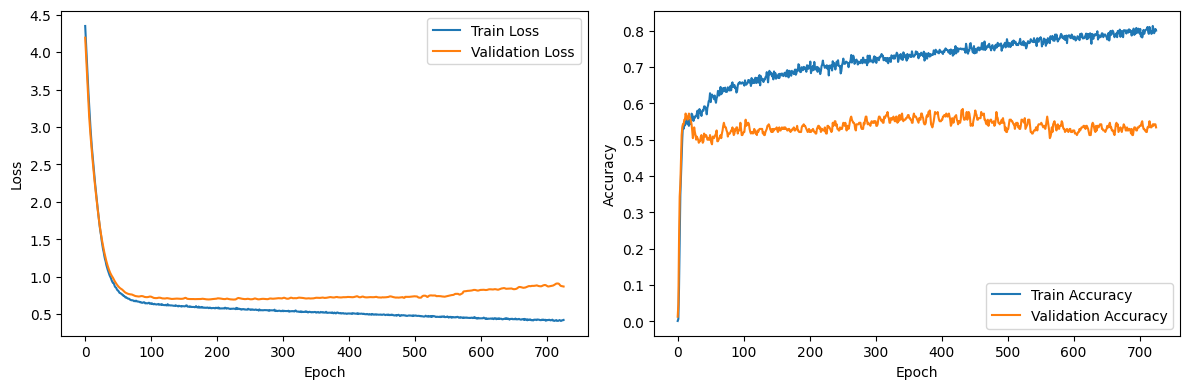


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9408, Val Loss: 2.7204, Train Acc: 0.3563, Val Acc: 0.4174
Epoch: 020, Train Loss: 1.9950, Val Loss: 1.8545, Train Acc: 0.5256, Val Acc: 0.5275
Epoch: 030, Train Loss: 1.3647, Val Loss: 1.2790, Train Acc: 0.5354, Val Acc: 0.4908
Epoch: 040, Train Loss: 1.0267, Val Loss: 1.0109, Train Acc: 0.5492, Val Acc: 0.4954
Epoch: 050, Train Loss: 0.8558, Val Loss: 0.8430, Train Acc: 0.5728, Val Acc: 0.5046
Epoch: 060, Train Loss: 0.7418, Val Loss: 0.7723, Train Acc: 0.6152, Val Acc: 0.5138
Epoch: 070, Train Loss: 0.6890, Val Loss: 0.7422, Train Acc: 0.6043, Val Acc: 0.5183
Epoch: 080, Train Loss: 0.6679, Val Loss: 0.7299, Train Acc: 0.6388, Val Acc: 0.5459
Epoch: 090, Train Loss: 0.6497, Val Loss: 0.7217, Train Acc: 0.6309, Val Acc: 0.5413
Epoch: 100, Train Loss: 0.6397, Val Loss: 0.7123, Train Acc: 0.6339, Val Acc: 0.5550
Epoch: 110, Train Loss: 0.6310, Val Loss: 0.7178, Tr

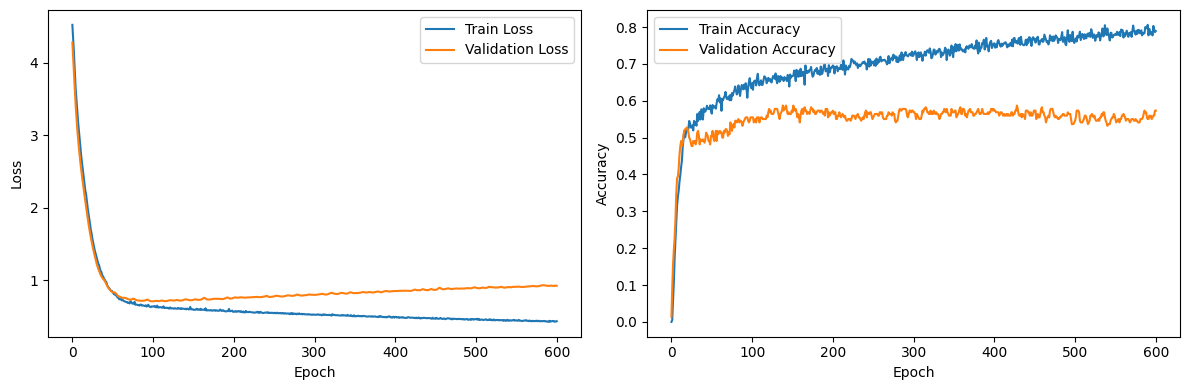


========== Run 29 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1445, Val Loss: 2.8796, Train Acc: 0.4996, Val Acc: 0.4887
Epoch: 020, Train Loss: 2.0111, Val Loss: 1.8562, Train Acc: 0.5318, Val Acc: 0.4511
Epoch: 030, Train Loss: 1.3073, Val Loss: 1.2361, Train Acc: 0.5721, Val Acc: 0.5226
Epoch: 040, Train Loss: 0.9481, Val Loss: 0.9534, Train Acc: 0.5874, Val Acc: 0.5376
Epoch: 050, Train Loss: 0.7818, Val Loss: 0.8134, Train Acc: 0.6148, Val Acc: 0.5677
Epoch: 060, Train Loss: 0.7016, Val Loss: 0.7556, Train Acc: 0.6301, Val Acc: 0.5602
Epoch: 070, Train Loss: 0.6731, Val Loss: 0.7355, Train Acc: 0.6334, Val Acc: 0.5752
Epoch: 080, Train Loss: 0.6551, Val Loss: 0.7233, Train Acc: 0.6261, Val Acc: 0.5677
Epoch: 090, Train Loss: 0.6443, Val Loss: 0.7178, Train Acc: 0.6350, Val Acc: 0.5714
Epoch: 100, Train Loss: 0.6316, Val Loss: 0.7172, Train Acc: 0.6471, Val Acc: 0.5940
Epoch: 110, Train Los

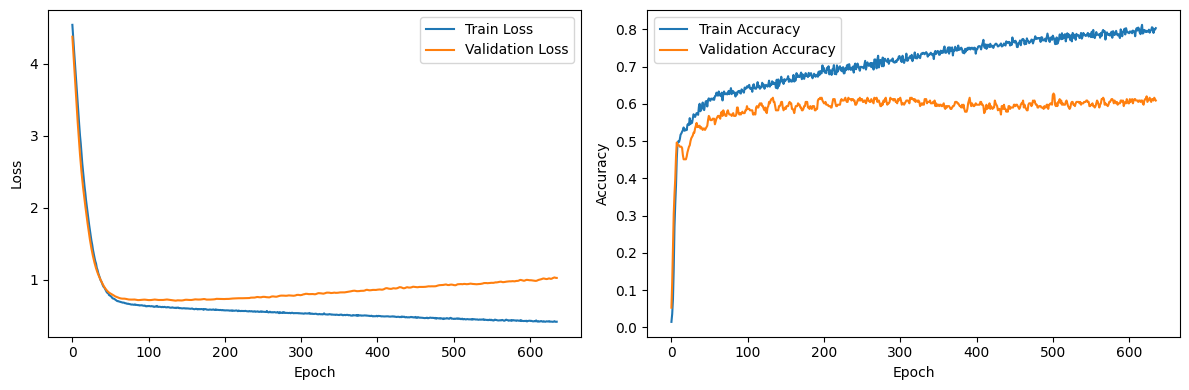


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0576, Val Loss: 2.9843, Train Acc: 0.4841, Val Acc: 0.5098
Epoch: 020, Train Loss: 2.0694, Val Loss: 2.0373, Train Acc: 0.5084, Val Acc: 0.5059
Epoch: 030, Train Loss: 1.4334, Val Loss: 1.4063, Train Acc: 0.5327, Val Acc: 0.5451
Epoch: 040, Train Loss: 1.0687, Val Loss: 1.0720, Train Acc: 0.5856, Val Acc: 0.5216
Epoch: 050, Train Loss: 0.9094, Val Loss: 0.9007, Train Acc: 0.5847, Val Acc: 0.5216
Epoch: 060, Train Loss: 0.7815, Val Loss: 0.8236, Train Acc: 0.6141, Val Acc: 0.5373
Epoch: 070, Train Loss: 0.7054, Val Loss: 0.7697, Train Acc: 0.6292, Val Acc: 0.5059
Epoch: 080, Train Loss: 0.6876, Val Loss: 0.7382, Train Acc: 0.6468, Val Acc: 0.5412
Epoch: 090, Train Loss: 0.6516, Val Loss: 0.7357, Train Acc: 0.6636, Val Acc: 0.5176
Epoch: 100, Train Loss: 0.6473, Val Loss: 0.7246, Train Acc: 0.6594, Val Acc: 0.5294
Epoch: 110, Train Loss: 0.6249, Val Loss: 0.7154, Tr

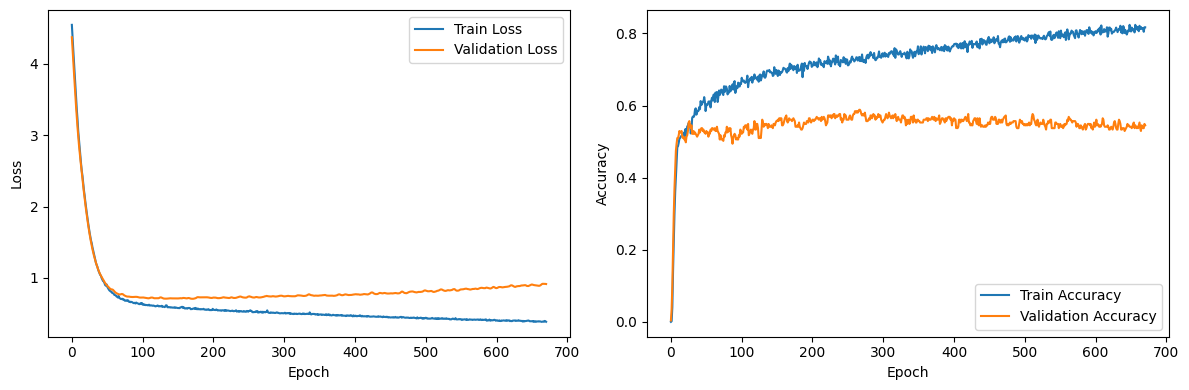


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1419, Val Loss: 3.0697, Train Acc: 0.5445, Val Acc: 0.5169
Epoch: 020, Train Loss: 1.9601, Val Loss: 1.9954, Train Acc: 0.5481, Val Acc: 0.5297
Epoch: 030, Train Loss: 1.3444, Val Loss: 1.3964, Train Acc: 0.5526, Val Acc: 0.5381
Epoch: 040, Train Loss: 1.0200, Val Loss: 1.0838, Train Acc: 0.5889, Val Acc: 0.5466
Epoch: 050, Train Loss: 0.8575, Val Loss: 0.9244, Train Acc: 0.5926, Val Acc: 0.5339
Epoch: 060, Train Loss: 0.7704, Val Loss: 0.8331, Train Acc: 0.6007, Val Acc: 0.5381
Epoch: 070, Train Loss: 0.7061, Val Loss: 0.7852, Train Acc: 0.6488, Val Acc: 0.5381
Epoch: 080, Train Loss: 0.6796, Val Loss: 0.7728, Train Acc: 0.6207, Val Acc: 0.5466
Epoch: 090, Train Loss: 0.6756, Val Loss: 0.7424, Train Acc: 0.6116, Val Acc: 0.5169
Epoch: 100, Train Loss: 0.6505, Val Loss: 0.7321, Train Acc: 0.6461, Val Acc: 0.5381
Epoch: 110, Train Loss: 0.6396, Val Loss: 0.7310, Tr

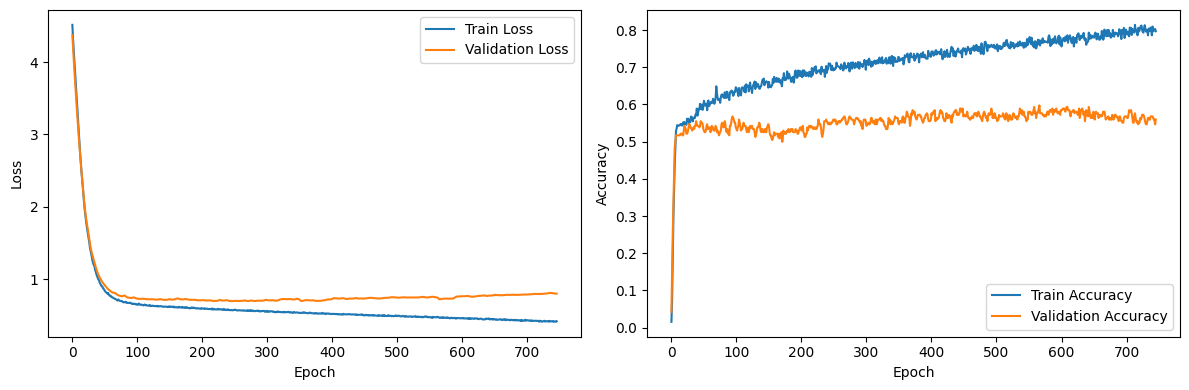


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8965, Val Loss: 2.7018, Train Acc: 0.4921, Val Acc: 0.5138
Epoch: 020, Train Loss: 1.9261, Val Loss: 1.7901, Train Acc: 0.5354, Val Acc: 0.5321
Epoch: 030, Train Loss: 1.2986, Val Loss: 1.2383, Train Acc: 0.5669, Val Acc: 0.5000
Epoch: 040, Train Loss: 0.9893, Val Loss: 0.9694, Train Acc: 0.5807, Val Acc: 0.5183
Epoch: 050, Train Loss: 0.8200, Val Loss: 0.8394, Train Acc: 0.6043, Val Acc: 0.5183
Epoch: 060, Train Loss: 0.7282, Val Loss: 0.7805, Train Acc: 0.6309, Val Acc: 0.5734
Epoch: 070, Train Loss: 0.6925, Val Loss: 0.7500, Train Acc: 0.6348, Val Acc: 0.5872
Epoch: 080, Train Loss: 0.6650, Val Loss: 0.7388, Train Acc: 0.6280, Val Acc: 0.6055
Epoch: 090, Train Loss: 0.6422, Val Loss: 0.7325, Train Acc: 0.6437, Val Acc: 0.5826
Epoch: 100, Train Loss: 0.6213, Val Loss: 0.7354, Train Acc: 0.6486, Val Acc: 0.5734
Epoch: 110, Train Loss: 0.6125, Val Loss: 0.7401, Tr

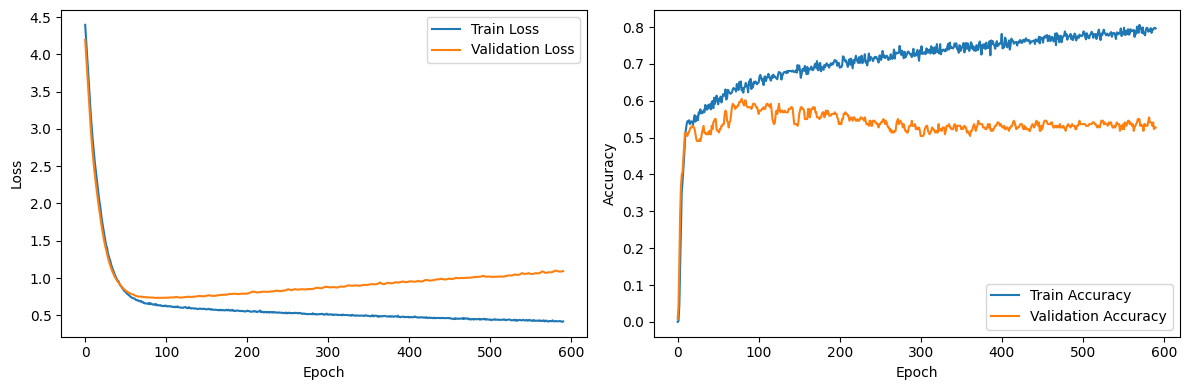


========== Final Summary ==========

Year: 2019
  Avg Test Accuracy: 0.6169 ± 0.0176
  Avg Test F1 Score: 0.6166 ± 0.0179
 Train Accuracy: 0.6506 ± 0.0088
Year: 2020
  Avg Test Accuracy: 0.5769 ± 0.0188
  Avg Test F1 Score: 0.5746 ± 0.0185
 Train Accuracy: 0.6884 ± 0.0155
Year: 2021
  Avg Test Accuracy: 0.6037 ± 0.0184
  Avg Test F1 Score: 0.6015 ± 0.0191
 Train Accuracy: 0.6978 ± 0.0161
Year: 2022
  Avg Test Accuracy: 0.5557 ± 0.0184
  Avg Test F1 Score: 0.5552 ± 0.0184
 Train Accuracy: 0.6488 ± 0.0128


In [8]:
if __name__ == "__main__":

    years = [2019, 2020, 2021, 2022]
    metric = 'revenue'

    # To store results for each year across 10 runs
    aggregate_results = {year: {'acc': [], 'f1': [], 'time': [], 'epochs': [], 'best_train_acc': []} for year in years}
    param = {
            "hidden_channels": 64,
            "out_channels": 32,
            "num_heads": 4,
            "lr": 0.0009,
            "weight_decay": 5e-4,
            "epochs": 1000,
            "patience": 500
        }

    #Add optuna code section here
    best_params_per_year = {}
    # for year in years:
    #     print(f"\nRunning Optuna optimization for year {year}...\n")
    
    #     study = optuna.create_study(direction="maximize")
    #     study.optimize(lambda trial: objective(trial, year, metric), n_trials=15)
    
    #     print(f"Best trial for year {year}: {study.best_trial.value}")
    #     print("Best hyperparameters:", study.best_params)

    #     best_params_per_year[year] = study.best_params
    
    for i in range(1, 30):
        print(f"\n========== Run {i} ==========\n")
        for year in years:
            # param = best_params_per_year[year]
            print(f"\nRunning experiment for year {year}...\n")
            results = run_experiment(year, metric, **param)
            # Store individual run metrics
            aggregate_results[year]['acc'].append(results['test_acc'])
            aggregate_results[year]['f1'].append(results['test_f1'])
            aggregate_results[year]['time'].append(results['training_time'])
            aggregate_results[year]['epochs'].append(results['epochs_run'])
            aggregate_results[year]['best_train_acc'].append(results['best_train_acc'])

    print("\n========== Final Summary ==========\n")
    for year in years:
        acc_mean = np.mean(aggregate_results[year]['acc'])
        acc_std = np.std(aggregate_results[year]['acc'])
        f1_mean = np.mean(aggregate_results[year]['f1'])
        f1_std = np.std(aggregate_results[year]['f1'])
        train_acc_mean = np.mean(aggregate_results[year]['best_train_acc'])
        train_acc_std = np.std(aggregate_results[year]['best_train_acc'])

        print(f"Year: {year}")
        print(f"  Avg Test Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
        print(f"  Avg Test F1 Score: {f1_mean:.4f} ± {f1_std:.4f}")
        print(f" Train Accuracy: {train_acc_mean:.4f} ± {train_acc_std:.4f}")